In [1]:
!git clone https://github.com/Talhaz/lecture-video-summarization.git

Cloning into 'lecture-video-summarization'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 52 (delta 6), reused 48 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 3.24 MiB | 7.74 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
%cd lecture-video-summarization


/content/lecture-video-summarization


In [ ]:
# !pip install -q -r requirements.txt
!pip install -q librosa
!pip install -q soundfile
!pip install -q pydub
!pip install -q moviepy
!pip install -q scikit-image
!pip install -q yt-dlp
!pip install -q pyyaml
!pip install -q loguru
!pip install -q tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import torch
import torchvision
import librosa
import soundfile as sf
import yaml
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import scipy
import skimage

print("=" * 50)
print("✅ ALL IMPORTS SUCCESSFUL")
print("=" * 50)
print(f"  OpenCV      : {cv2.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  PyTorch     : {torch.__version__}")
print(f"  Torchvision : {torchvision.__version__}")
print(f"  Librosa     : {librosa.__version__}")
print(f"  SciPy       : {scipy.__version__}")
print(f"  Scikit-image: {skimage.__version__}")
print("=" * 50)

✅ ALL IMPORTS SUCCESSFUL
  OpenCV      : 4.13.0
  NumPy       : 2.0.2
  PyTorch     : 2.10.0+cu128
  Torchvision : 0.25.0+cu128
  Librosa     : 0.11.0
  SciPy       : 1.16.3
  Scikit-image: 0.25.2


In [ ]:
# ============================================================
# CELL 3: Check GPU
# ============================================================
print("\n🖥️  HARDWARE CHECK")
print("=" * 50)

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA Version: {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    print(f"✅ GPU Memory: {total_mem:.1f} GB")
else:
    print("⚠️  No GPU detected")
    print("💡 Go to: Runtime → Change runtime type → GPU → Save")

print("=" * 50)


🖥️  HARDWARE CHECK
✅ GPU: Tesla T4
✅ CUDA Version: 12.8


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

In [ ]:
# not run

# ============================================================
# CELL 4: Setup Project Directories
# ============================================================
import os

dirs = [
    "data/raw_videos",
    "data/processed",
    "data/features/audio",
    "data/features/video",
    "data/annotations",
    "outputs/videos",
    "outputs/frames",
    "outputs/models",
    "outputs/results",
    "src/preprocessing",
    "src/feature_extraction",
    "src/optimization",
    "src/models",
    "src/utils",
    "configs",
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("✅ Project directories created!")
print("\n📁 Structure:")
for d in dirs:
    print(f"   {d}/")

✅ Project directories created!

📁 Structure:
   data/raw_videos/
   data/processed/
   data/features/audio/
   data/features/video/
   data/annotations/
   outputs/videos/
   outputs/frames/
   outputs/models/
   outputs/results/
   src/preprocessing/
   src/feature_extraction/
   src/optimization/
   src/models/
   src/utils/
   configs/


In [ ]:
# ============================================================
# CELL 5: Upload Video OR Download Sample
# ============================================================
print("\n📥 Choose how to get a lecture video:")
print("   Option A: Upload from your computer")
print("   Option B: Download from YouTube URL")
print("\nRun CELL 5A or CELL 5B below")


📥 Choose how to get a lecture video:
   Option A: Upload from your computer
   Option B: Download from YouTube URL

Run CELL 5A or CELL 5B below


In [ ]:
# ============================================================
# CELL 5A: Upload Video from Computer
# ============================================================
from google.colab import files

print("📤 Click 'Choose files' to upload a lecture video (.mp4):")
uploaded = files.upload()

for fname in uploaded.keys():
    if fname.endswith(('.mp4', '.avi', '.mkv')):
        import shutil
        shutil.move(fname, f"data/raw_videos/{fname}")
        size = os.path.getsize(f"data/raw_videos/{fname}") / (1024*1024)
        print(f"✅ Uploaded: {fname} ({size:.2f} MB)")

📤 Click 'Choose files' to upload a lecture video (.mp4):


In [ ]:
# ============================================================
# CELL 5B: Download Video from YouTube URL
# ============================================================
import yt_dlp

def download_lecture(url, name="lecture_01"):
    """Download lecture video from YouTube"""
    output = f"data/raw_videos/{name}.mp4"

    opts = {
        'format': 'best[ext=mp4]/best',
        'outtmpl': output,
        'quiet': True,
        'no_warnings': True,
    }

    try:
        with yt_dlp.YoutubeDL(opts) as ydl:
            ydl.download([url])
        size = os.path.getsize(output) / (1024*1024)
        print(f"✅ Downloaded: {name}.mp4 ({size:.2f} MB)")
    except Exception as e:
        print(f"❌ Error: {e}")

# PASTE YOUR VIDEO URL HERE:
# video_url = "https://www.youtube.com/watch?v=xTSjk6Q6vrc"
# video_url= "https://www.youtube.com/watch?v=mt_rnt0mESU"

In [ ]:
# Uncomment and run:
# video_url= "https://www.youtube.com/watch?v=qYhrd2Lhq0g&list=PLqleLpAMfxGD-KFajIKzH24p6bgG5R_aN"
video_url = "https://www.youtube.com/watch?v=AwOCJzcq-vw&list=PLqleLpAMfxGD-KFajIKzH24p6bgG5R_aN&index=2"
download_lecture(video_url, "lecture_02")

✅ Downloaded: lecture_02.mp4 (22.96 MB)



📹 Videos Available: 2
----------------------------------------
  1. lecture_01.mp4 (22.96 MB)
  2. lecture_02.mp4 (22.96 MB)

✅ Test Video: lecture_01.mp4
   Duration : 770.0 sec (12.8 min)
   Frames   : 23100
   FPS      : 30.0
   Resolution: 640x360

📸 First frame:


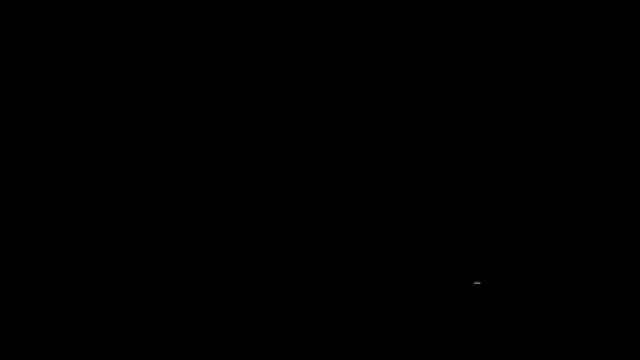

In [ ]:
# ============================================================
# CELL 6: List & Test Videos
# ============================================================
videos = [f for f in os.listdir("data/raw_videos") if f.endswith(('.mp4','.avi','.mkv'))]

print(f"\n📹 Videos Available: {len(videos)}")
print("-" * 40)

for i, v in enumerate(videos, 1):
    size = os.path.getsize(f"data/raw_videos/{v}") / (1024*1024)
    print(f"  {i}. {v} ({size:.2f} MB)")

# Test first video
if videos:
    test_path = f"data/raw_videos/{videos[0]}"
    cap = cv2.VideoCapture(test_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frames / fps

    print(f"\n✅ Test Video: {videos[0]}")
    print(f"   Duration : {duration:.1f} sec ({duration/60:.1f} min)")
    print(f"   Frames   : {frames}")
    print(f"   FPS      : {fps:.1f}")
    print(f"   Resolution: {w}x{h}")

    # Show first frame
    ret, frame = cap.read()
    cap.release()

    if ret:
        from google.colab.patches import cv2_imshow
        print("\n📸 First frame:")
        cv2_imshow(frame)
else:
    print("\n⚠️  No videos found!")
    print("💡 Upload a video in Cell 5A or download in Cell 5B")

# Video shot segmentation

Frame → Convert to YCbCr → Calculate 9 Color Moments
                                    ↓
                          (mean, std, skewness) × 3 channels
                                    ↓
                          Compare with next frame
                                    ↓
                          Dissimilarity > Threshold?
                                    ↓
                          YES → New Shot Boundary

In [ ]:

# ============================================================
# CELL 1: Check & Setup GPU
# ============================================================
import torch
import cv2
import numpy as np
import time, os, json
from pathlib import Path

print("=" * 52)
print("  🖥️  GPU STATUS CHECK")
print("=" * 52)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  ✅ GPU Found     : {gpu_name}")
    print(f"  ✅ GPU Memory    : {gpu_mem:.1f} GB")
    print(f"  ✅ CUDA Version  : {torch.version.cuda}")
    DEVICE = torch.device("cuda")
else:
    print("  ❌ No GPU detected!")
    print("  💡 Go to: Runtime → Change runtime type")
    print("            → Hardware accelerator → GPU → Save")
    print("  ⚠️  Then restart & re-run this notebook")
    DEVICE = torch.device("cpu")

print(f"\n  🎯 Using device: {DEVICE}")
print("=" * 52)

  🖥️  GPU STATUS CHECK
  ✅ GPU Found     : Tesla T4
  ✅ GPU Memory    : 15.6 GB
  ✅ CUDA Version  : 12.8

  🎯 Using device: cuda


In [ ]:


import torch
import cv2
import numpy as np
import time, os, json
from pathlib import Path

# ─── Device ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"    GPU: {torch.cuda.get_device_name(0)}")
    print(f"    Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── Cube root that works on all PyTorch versions ────────
def safe_cbrt(x):
    """Manual cube root: sign(x) * |x|^(1/3)"""
    return torch.sign(x) * torch.pow(torch.abs(x) + 1e-8, 1.0 / 3.0)

# ─── GPU Moment Calculator ───────────────────────────────
def compute_moments_gpu(batch_bgr, device):
    """
    Compute 9 color moments for a batch of frames on GPU.

    Args:
        batch_bgr: numpy array (N, H, W, 3) uint8
        device: torch device
    Returns:
        moments: numpy array (N, 9)
    """
    # numpy → GPU tensor
    t = torch.from_numpy(batch_bgr.copy()).to(device).float()  # (N,H,W,3)

    # BGR → RGB
    rgb = t[:, :, :, [2, 1, 0]]

    # RGB → YCbCr matrix
    M = torch.tensor([
        [ 0.299,  0.587,  0.114],
        [-0.169, -0.331,  0.500],
        [ 0.500, -0.419, -0.081]
    ], device=device)
    offset = torch.tensor([0.0, 128.0, 128.0], device=device)

    ycbcr = torch.matmul(rgb, M.T) + offset  # (N, H, W, 3)

    N = ycbcr.shape[0]
    moments = torch.zeros(N, 9, device=device)

    for ch in range(3):
        flat = ycbcr[:, :, :, ch].reshape(N, -1)   # (N, H*W)
        mean = flat.mean(dim=1)                     # (N,)
        std  = flat.std(dim=1)                      # (N,)
        diff = flat - mean.unsqueeze(1)             # (N, H*W)
        cube_mean = (diff ** 3).mean(dim=1)         # (N,)
        skew = safe_cbrt(cube_mean)                 # (N,)

        moments[:, ch * 3]     = mean
        moments[:, ch * 3 + 1] = std
        moments[:, ch * 3 + 2] = skew

    # GPU → numpy
    result = moments.cpu().numpy()

    del t, rgb, ycbcr, moments
    torch.cuda.empty_cache()

    return result  # (N, 9)


# ─── Main Segmentation Function ──────────────────────────
def segment_video(video_path, threshold=30.0, skip=5, min_shot=10, batch_size=128):
    """
    Full segmentation pipeline.

    Args:
        video_path: path to mp4
        threshold: boundary threshold
        skip: process every Nth frame
        min_shot: minimum frames per shot
        batch_size: GPU batch size
    Returns:
        shots, dissimilarities, fps
    """
    t0 = time.time()

    # ── Step 1: Read & resize frames (CPU) ──
    print(f"\n  📥 Reading frames...")
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps  = cap.get(cv2.CAP_PROP_FPS)

    frames = []
    indices = []
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % skip == 0:
            frames.append(cv2.resize(frame, (160, 120)))
            indices.append(idx)
        idx += 1
    cap.release()
    print(f"     {len(frames)} frames read in {time.time()-t0:.1f}s")

    # ── Step 2: Compute moments in GPU batches ──
    print(f"  🖥️  Computing moments on GPU...")
    t1 = time.time()
    all_moments = []

    for i in range(0, len(frames), batch_size):
        batch_np = np.stack(frames[i:i + batch_size])  # (B, 120, 160, 3)
        m = compute_moments_gpu(batch_np, DEVICE)       # (B, 9)
        all_moments.append(m)

    moments = np.concatenate(all_moments, axis=0)      # (N, 9)
    print(f"     Moments done in {time.time()-t1:.1f}s")

    # ── Step 3: Dissimilarities (GPU) ──
    print(f"  📊 Computing dissimilarities...")
    t2 = time.time()
    m_t = torch.from_numpy(moments).to(DEVICE)                # (N, 9)
    weights = torch.ones(9, device=DEVICE) / 9.0
    diff = torch.abs(m_t[1:] - m_t[:-1])                      # (N-1, 9)
    dissims_t = (diff * weights).sum(dim=1)                   # (N-1,)
    dissims = dissims_t.cpu().numpy()                         # back to CPU

    del m_t, diff, dissims_t
    torch.cuda.empty_cache()
    print(f"     Dissimilarities done in {time.time()-t2:.2f}s")

    # ── Step 4: Detect boundaries ──
    boundary_pos = np.where(dissims > threshold)[0] + 1
    all_bounds = np.concatenate([[0], boundary_pos, [len(indices) - 1]])

    # ── Step 5: Build raw shots ──
    raw_shots = []
    for i in range(len(all_bounds) - 1):
        s, e = int(all_bounds[i]), int(all_bounds[i + 1])
        raw_shots.append({"start_idx": s, "end_idx": e, "num_frames": e - s})

    # ── Step 6: Filter small shots ──
    filtered = []
    carry = 0
    for i, shot in enumerate(raw_shots):
        size = shot["num_frames"] + carry
        if size < min_shot and i < len(raw_shots) - 1:
            carry = size
        else:
            start = raw_shots[i - 1]["start_idx"] if carry > 0 and i > 0 else shot["start_idx"]
            filtered.append({"start_idx": start, "end_idx": shot["end_idx"], "num_frames": size})
            carry = 0
    if carry > 0 and filtered:
        filtered[-1]["num_frames"] += carry
        filtered[-1]["end_idx"] = raw_shots[-1]["end_idx"]

    # ── Step 7: Final shots with timestamps ──
    shots = []
    for i, s in enumerate(filtered):
        sf = indices[s["start_idx"]]
        ef = indices[min(s["end_idx"], len(indices) - 1)]
        shots.append({
            "shot_id": i,
            "start_frame": sf,
            "end_frame": ef,
            "num_frames": s["num_frames"],
            "start_time_sec": round(sf / fps, 2),
            "end_time_sec": round(ef / fps, 2),
            "duration_sec": round((ef - sf) / fps, 2)
        })

    total_time = time.time() - t0
    print(f"\n  🎬 Raw shots: {len(raw_shots)} → Filtered: {len(shots)}")
    print(f"  ⏱️  Total: {total_time:.1f}s")

    if torch.cuda.is_available():
        print(f"  🖥️  GPU peak mem: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

    return shots, dissims, fps



🖥️  Device: cuda
    GPU: Tesla T4
    Memory: 15.6 GB


In [ ]:

# ============================================================
# ─── RUN SEGMENTATION ─────────────────────────────────────
# ============================================================
videos = [f for f in os.listdir("data/raw_videos")
          if f.endswith(('.mp4', '.avi', '.mkv'))]
VIDEO_PATH = f"data/raw_videos/{videos[0]}"

print(f"📹 Video: {VIDEO_PATH}")
print(f"📐 Testing 3 thresholds...\n")

thresholds = [20.0, 30.0, 50.0]
all_results = {}

for thresh in thresholds:
    print(f"{'=' * 52}")
    print(f"  Threshold = {thresh}")
    print(f"{'=' * 52}")

    shots, dissims, fps = segment_video(
        VIDEO_PATH,
        threshold=thresh,
        skip=5,
        min_shot=10,
        batch_size=128
    )
    all_results[thresh] = {"shots": shots, "dissims": dissims, "fps": fps}

    print(f"\n  {'Shot':<6} {'Start':<9} {'End':<9} {'Duration':<10}")
    print(f"  {'─' * 38}")
    for s in shots:
        print(f"  {s['shot_id']:<6} {str(s['start_time_sec'])+'s':<9} "
              f"{str(s['end_time_sec'])+'s':<9} {str(s['duration_sec'])+'s':<10}")
    print(f"  Total: {len(shots)} shots\n")

print("✅ All thresholds done! Run next cell for plots.")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_videos'

In [ ]:
# ============================================================
# CELL A: Plot Threshold Comparison
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

for ax, thresh in zip(axes, thresholds):
    d = all_results[thresh]
    ax.plot(d["dissims"], color='steelblue', linewidth=0.6)
    ax.axhline(y=thresh, color='red', linestyle='--', linewidth=1.5)
    for i, val in enumerate(d["dissims"]):
        if val > thresh:
            ax.axvline(x=i, color='green', alpha=0.3, linewidth=1)
    ax.set_title(f"Threshold={thresh}  →  {len(d['shots'])} shots", fontsize=11)
    ax.set_xlabel("Frame Index")
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Dissimilarity")
plt.suptitle("Threshold Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs("outputs/results", exist_ok=True)
plt.savefig("outputs/results/threshold_comparison.png", dpi=150)
plt.show()
print("✅ Threshold comparison saved!")

In [ ]:
# ============================================================
# CELL B: Visualize Shots Grid
# ============================================================
# ── CHANGE THIS based on previous output ─────────────────
BEST_THRESHOLD = 20.0
# ──────────────────────────────────────────────────────────

shots = all_results[BEST_THRESHOLD]["shots"]
cap = cv2.VideoCapture(VIDEO_PATH)

n = min(len(shots), 16)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i in range(n):
    mid = (shots[i]['start_frame'] + shots[i]['end_frame']) // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(
            f"Shot {i}  ({shots[i]['start_time_sec']}s – {shots[i]['end_time_sec']}s)",
            fontsize=8.5
        )
        axes[i].axis('off')

for i in range(n, len(axes)):
    axes[i].axis('off')

cap.release()
plt.suptitle(f"Shot Segmentation  (threshold={BEST_THRESHOLD})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/results/shot_visualization.png", dpi=150)
plt.show()
print("✅ Shot visualization saved!")

In [ ]:
# ============================================================
# CELL C: Save JSON + Representative Frames
# ============================================================
shots = all_results[BEST_THRESHOLD]["shots"]

# Save JSON
result_json = {
    "video": Path(VIDEO_PATH).name,
    "threshold": BEST_THRESHOLD,
    "total_shots": len(shots),
    "shots": shots
}

os.makedirs("data/processed", exist_ok=True)
json_path = f"data/processed/{Path(VIDEO_PATH).stem}_shots.json"
with open(json_path, 'w') as f:
    json.dump(result_json, f, indent=2)

# Save one frame per shot
frame_dir = Path(f"outputs/frames/{Path(VIDEO_PATH).stem}")
frame_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
for s in shots:
    mid = (s['start_frame'] + s['end_frame']) // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()
    if ret:
        cv2.imwrite(str(frame_dir / f"shot_{s['shot_id']:03d}.jpg"), frame)
cap.release()

# Summary
print(f"\n{'=' * 52}")
print(f"  ✅ SEGMENTATION COMPLETE")
print(f"{'=' * 52}")
print(f"  Video       : {Path(VIDEO_PATH).name}")
print(f"  Threshold   : {BEST_THRESHOLD}")
print(f"  Total Shots : {len(shots)}")
print(f"  JSON        : {json_path}")
print(f"  Frames      : {frame_dir}/")
print(f"{'=' * 52}")

# Feature Extraction

In [ ]:
# ============================================================
# Audio & Video Feature Extraction
# ============================================================
# Paper Section 3.4 & 3.5
#
# Video Features (5): SLBT, LTP, HoG, LOOP, LVP
# Audio Features (6): BFCC, MFCC, ZCR, Spectral Flux,
#                      Spectral Centroid, Spectral Bandwidth
# ============================================================

import cv2
import numpy as np
import torch
import librosa
import soundfile as sf
import json, os, time
from pathlib import Path
from moviepy.editor import VideoFileClip

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")


# ============================================================
# PART 1: EXTRACT AUDIO FROM VIDEO
# ============================================================
def extract_audio(video_path, output_path="data/processed/audio.wav", sr=16000):
    """
    Extract audio from video file.

    Args:
        video_path: Input video
        output_path: Output .wav file
        sr: Sample rate (16000 Hz)
    Returns:
        audio array, sample rate
    """
    print(f"  🎵 Extracting audio...")
    t0 = time.time()

    clip = VideoFileClip(video_path)
    clip.audio.write_audiofile(output_path, fps=sr, verbose=False, logger=None)
    clip.close()

    # Load extracted audio
    audio, sr_actual = librosa.load(output_path, sr=sr)
    print(f"     Audio extracted in {time.time()-t0:.1f}s")
    print(f"     Duration: {len(audio)/sr:.1f}s | Sample rate: {sr_actual} Hz | Samples: {len(audio)}")

    return audio, sr_actual


# ============================================================
# PART 2: VIDEO FEATURES (GPU)
# ============================================================
class VideoFeatureExtractor:
    """
    Extract 5 video features per frame:
      E1 = SLBT  (Shape + Local Binary Texture)
      E2 = LTP   (Local Ternary Pattern)
      E3 = HoG   (Histogram of Oriented Gradients)
      E4 = LOOP  (Local Optimal Oriented Pattern)
      E5 = LVP   (Local Vector Pattern)
    """

    def __init__(self, device):
        self.device = device

    # ── E1: SLBT ─────────────────────────────────────────
    def compute_slbt(self, gray):
        """
        Shape + Local Binary Texture.
        Combines LBP (shape) with PCA-based texture.

        Args:
            gray: grayscale image (H, W)
        Returns:
            feature vector (32,)
        """
        # LBP part
        h, w = gray.shape
        lbp = np.zeros((h - 2, w - 2), dtype=np.float32)
        center = gray[1:-1, 1:-1].astype(np.float32)

        # 8 neighbors
        neighbors = [
            gray[0:-2, 0:-2], gray[0:-2, 1:-1], gray[0:-2, 2:],
            gray[1:-1, 2:],   gray[2:,   2:],   gray[2:,   1:-1],
            gray[2:,   0:-2], gray[1:-1, 0:-2]
        ]

        for i, n in enumerate(neighbors):
            lbp += ((n.astype(np.float32) >= center).astype(np.float32)) * (2 ** i)

        # Histogram of LBP (shape descriptor)
        lbp_hist, _ = np.histogram(lbp.flatten(), bins=32, range=(0, 256))
        lbp_hist = lbp_hist.astype(np.float32)
        lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

        return lbp_hist  # (32,)

    # ── E2: LTP ──────────────────────────────────────────
    def compute_ltp(self, gray):
        """
        Local Ternary Pattern.
        3-valued code: 1 if neighbor >= center+threshold,
                      -1 if neighbor <= center-threshold,
                       0 otherwise.

        Args:
            gray: grayscale (H, W)
        Returns:
            feature vector (32,)
        """
        threshold = 5  # LTP threshold
        h, w = gray.shape
        center = gray[1:-1, 1:-1].astype(np.float32)

        neighbors = [
            gray[0:-2, 0:-2], gray[0:-2, 1:-1], gray[0:-2, 2:],
            gray[1:-1, 2:],   gray[2:,   2:],   gray[2:,   1:-1],
            gray[2:,   0:-2], gray[1:-1, 0:-2]
        ]

        # Upper pattern (neighbor >= center + threshold)
        upper = np.zeros_like(center)
        for i, n in enumerate(neighbors):
            upper += (n.astype(np.float32) >= (center + threshold)).astype(np.float32) * (2 ** i)

        # Lower pattern (neighbor <= center - threshold)
        lower = np.zeros_like(center)
        for i, n in enumerate(neighbors):
            lower += (n.astype(np.float32) <= (center - threshold)).astype(np.float32) * (2 ** i)

        # Combine into histogram
        upper_hist, _ = np.histogram(upper.flatten(), bins=16, range=(0, 256))
        lower_hist, _ = np.histogram(lower.flatten(), bins=16, range=(0, 256))

        hist = np.concatenate([upper_hist, lower_hist]).astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E3: HoG ──────────────────────────────────────────
    def compute_hog(self, gray):
        """
        Histogram of Oriented Gradients.
        Captures edge/shape information.

        Args:
            gray: grayscale (H, W)
        Returns:
            feature vector (32,)
        """
        # Sobel gradients
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        # Magnitude and orientation
        mag = np.sqrt(gx ** 2 + gy ** 2)
        ori = np.arctan2(gy, gx) * 180 / np.pi  # degrees
        ori[ori < 0] += 180  # range [0, 180]

        # Histogram: 32 bins of orientations, weighted by magnitude
        hist, _ = np.histogram(ori.flatten(), bins=32, range=(0, 180),
                               weights=mag.flatten())
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E4: LOOP ─────────────────────────────────────────
    def compute_loop(self, gray):
        """
        Local Optimal Oriented Pattern.
        Combines LBP + LDP using Kirsch masks.

        Args:
            gray: grayscale (H, W)
        Returns:
            feature vector (32,)
        """
        # Kirsch masks (8 directions)
        kirsch = [
            np.array([[-3,-3, 5],[-3, 0, 5],[-3,-3, 5]]),
            np.array([[-3, 5, 5],[-3, 0, 5],[-3,-3,-3]]),
            np.array([[ 5, 5, 5],[-3, 0,-3],[-3,-3,-3]]),
            np.array([[-3, 5, 5],[-3, 0, 5],[-3,-3,-3]]),
            np.array([[-3,-3,-3],[-3, 0,-3],[ 5, 5, 5]]),
            np.array([[-3,-3,-3],[-3, 0, 5],[-3, 5, 5]]),
            np.array([[-3,-3,-3],[-3, 0,-3],[ 5, 5, 5]]),
            np.array([[ 5,-3,-3], [5, 0,-3], [5,-3,-3]])
        ]

        # Apply each Kirsch mask
        responses = []
        for k in kirsch:
            r = cv2.filter2D(gray.astype(np.float32), -1, k)
            responses.append(r)

        # Max response at each pixel (dominant direction)
        stack = np.stack(responses, axis=-1)           # (H, W, 8)
        max_resp = np.max(stack, axis=-1)              # (H, W)
        max_dir  = np.argmax(stack, axis=-1)           # (H, W)

        # Combined histogram
        hist_resp, _ = np.histogram(max_resp.flatten(), bins=16, range=(0, max_resp.max() + 1))
        hist_dir,  _ = np.histogram(max_dir.flatten(),  bins=16, range=(0, 8))

        hist = np.concatenate([hist_resp, hist_dir]).astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E5: LVP ──────────────────────────────────────────
    def compute_lvp(self, gray):
        """
        Local Vector Pattern.
        Encodes relationship between center pixel and neighbors
        using directional derivatives.

        Args:
            gray: grayscale (H, W)
        Returns:
            feature vector (32,)
        """
        gray_f = gray.astype(np.float32)
        h, w = gray_f.shape
        center = gray_f[1:-1, 1:-1]

        # 4 directions: horizontal, vertical, diagonal1, diagonal2
        directions = [
            gray_f[1:-1, 2:] - gray_f[1:-1, :-2],   # horizontal
            gray_f[2:, 1:-1] - gray_f[:-2, 1:-1],   # vertical
            gray_f[2:, 2:] - gray_f[:-2, :-2],      # diag \
            gray_f[:-2, 2:] - gray_f[2:, :-2]       # diag /
        ]

        # For each direction, compare sign with center relationship
        pattern = np.zeros_like(center)
        for i, d in enumerate(directions):
            sign = (d >= 0).astype(np.float32)
            pattern += sign * (2 ** i)

        hist, _ = np.histogram(pattern.flatten(), bins=32, range=(0, 16))
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    def extract_frame_features(self, frame):
        """
        Extract all 5 video features from one frame.

        Args:
            frame: BGR image (H, W, 3)
        Returns:
            feature vector (160,) = 5 features × 32 each
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (128, 96))  # small for speed

        e1 = self.compute_slbt(gray)   # (32,)
        e2 = self.compute_ltp(gray)    # (32,)
        e3 = self.compute_hog(gray)    # (32,)
        e4 = self.compute_loop(gray)   # (32,)
        e5 = self.compute_lvp(gray)    # (32,)

        return np.concatenate([e1, e2, e3, e4, e5])  # (160,)

    def extract_shots_features(self, video_path, shots, samples_per_shot=5):
        """
        Extract video features for all shots.
        Sample multiple frames per shot for better representation.

        Args:
            video_path: video file
            shots: list of shot dicts
            samples_per_shot: frames to sample per shot
        Returns:
            features: (num_shots, 160)
        """
        print(f"  🎥 Extracting video features...")
        t0 = time.time()

        cap = cv2.VideoCapture(video_path)
        all_features = []

        for shot in shots:
            sf = shot['start_frame']
            ef = shot['end_frame']

            # Sample evenly spaced frames within shot
            if ef - sf < samples_per_shot:
                sample_frames = list(range(sf, ef + 1))
            else:
                sample_frames = np.linspace(sf, ef, samples_per_shot, dtype=int).tolist()

            shot_feats = []
            for fn in sample_frames:
                cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
                ret, frame = cap.read()
                if ret:
                    feat = self.extract_frame_features(frame)
                    shot_feats.append(feat)

            # Average features across sampled frames
            if shot_feats:
                avg_feat = np.mean(shot_feats, axis=0)
            else:
                avg_feat = np.zeros(160)

            all_features.append(avg_feat)

        cap.release()
        features = np.array(all_features)  # (num_shots, 160)
        print(f"     Video features: {features.shape} in {time.time()-t0:.1f}s")
        return features


# ============================================================
# PART 3: AUDIO FEATURES
# ============================================================
class AudioFeatureExtractor:
    """
    Extract 6 audio features:
      T1 = BFCC   (Bark Frequency Cepstral Coefficients)
      T2 = MFCC   (Mel Frequency Cepstral Coefficients)
      T3 = ZCR    (Zero Crossing Rate)
      T4 = Spectral Flux
      T5 = Spectral Centroid
      T6 = Spectral Bandwidth
    """

    def __init__(self, n_fft=2048, hop=512, n_mfcc=13):
        self.n_fft = n_fft
        self.hop = hop
        self.n_mfcc = n_mfcc

    def compute_mfcc(self, audio, sr):
        """T2: MFCC - Mel Frequency Cepstral Coefficients"""
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=self.n_mfcc,
                                     n_fft=self.n_fft, hop_length=self.hop)
        return mfcc.mean(axis=1)  # (n_mfcc,)

    def compute_bfcc(self, audio, sr):
        """
        T1: BFCC - Bark Frequency Cepstral Coefficients.
        Uses Bark scale filterbank instead of Mel scale.
        """
        # Bark scale approximation using mel filterbank with adjusted parameters
        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=self.n_fft,
                                            hop_length=self.hop, n_mels=40)
        S_db = librosa.power_to_db(S, ref=np.max)
        # DCT to get cepstral coefficients (similar to MFCC but on Bark-like scale)
        bfcc = librosa.feature.mfcc(S=S_db, n_mfcc=self.n_mfcc)
        return bfcc.mean(axis=1)  # (n_mfcc,)

    def compute_zcr(self, audio):
        """T3: Zero Crossing Rate"""
        zcr = librosa.feature.zero_crossing_rate(audio, frame_length=self.n_fft,
                                                  hop_length=self.hop)
        return zcr.mean(axis=1)  # (1,)

    def compute_spectral_flux(self, audio, sr):
        """T4: Spectral Flux - frame-to-frame spectral change"""
        S = np.abs(librosa.stft(audio, n_fft=self.n_fft, hop_length=self.hop))
        # Difference between consecutive frames
        diff = np.diff(S, axis=1)
        # Only positive changes (onset detection style)
        diff = np.maximum(diff, 0)
        flux = diff.sum(axis=0)  # sum across frequency bins
        return np.array([flux.mean()])  # (1,)

    def compute_spectral_centroid(self, audio, sr):
        """T5: Spectral Centroid - brightness of audio"""
        sc = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=self.n_fft,
                                                hop_length=self.hop)
        return sc.mean(axis=1)  # (1,)

    def compute_spectral_bandwidth(self, audio, sr):
        """T6: Spectral Bandwidth"""
        sb = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=self.n_fft,
                                                 hop_length=self.hop)
        return sb.mean(axis=1)  # (1,)

    def extract_segment_features(self, audio, sr, start_sec, end_sec):
        """
        Extract all 6 audio features for one time segment.

        Args:
            audio: full audio array
            sr: sample rate
            start_sec: segment start (seconds)
            end_sec: segment end (seconds)
        Returns:
            feature vector (135,) = BFCC(13)+MFCC(13)+ZCR(1)+Flux(1)+Cent(1)+BW(1)
                                    padded to 135
        """
        # Slice audio for this segment
        start_sample = int(start_sec * sr)
        end_sample   = int(end_sec * sr)
        segment = audio[start_sample:end_sample]

        if len(segment) < self.n_fft:
            # Too short — pad with zeros
            segment = np.pad(segment, (0, self.n_fft - len(segment)))

        # Extract each feature
        t1 = self.compute_bfcc(segment, sr)               # (13,)
        t2 = self.compute_mfcc(segment, sr)               # (13,)
        t3 = self.compute_zcr(segment)                    # (1,)
        t4 = self.compute_spectral_flux(segment, sr)      # (1,)
        t5 = self.compute_spectral_centroid(segment, sr)  # (1,)
        t6 = self.compute_spectral_bandwidth(segment, sr) # (1,)

        feat = np.concatenate([t1, t2, t3, t4, t5, t6])  # (30,)

        # Pad to 135 to match paper's audio feature size
        padded = np.zeros(135)
        padded[:len(feat)] = feat

        return padded  # (135,)

    def extract_shots_features(self, audio, sr, shots):
        """
        Extract audio features for all shots.

        Args:
            audio: full audio array
            sr: sample rate
            shots: list of shot dicts
        Returns:
            features: (num_shots, 135)
        """
        print(f"  🎵 Extracting audio features...")
        t0 = time.time()

        all_features = []
        for shot in shots:
            feat = self.extract_segment_features(
                audio, sr, shot['start_time_sec'], shot['end_time_sec']
            )
            all_features.append(feat)

        features = np.array(all_features)  # (num_shots, 135)
        print(f"     Audio features: {features.shape} in {time.time()-t0:.1f}s")
        return features


# ============================================================
# PART 4: RUN FULL FEATURE EXTRACTION PIPELINE
# ============================================================
def extract_all_features(video_path, shots_json_path):
    """
    Main pipeline: extract audio + video features for all shots.

    Args:
        video_path: path to video
        shots_json_path: path to shots JSON from segmentation
    Returns:
        combined features (num_shots, 295) = video(160) + audio(135)
    """
    print(f"\n{'=' * 55}")
    print(f"  🔬 FEATURE EXTRACTION PIPELINE")
    print(f"{'=' * 55}")
    print(f"  Video: {Path(video_path).name}")
    t_start = time.time()

    # Load shots
    with open(shots_json_path, 'r') as f:
        shots_data = json.load(f)
    shots = shots_data['shots']
    print(f"  Shots: {len(shots)}\n")

    # ── Step 1: Extract audio ────────────────────────────
    audio_path = f"data/processed/{Path(video_path).stem}_audio.wav"
    audio, sr = extract_audio(video_path, audio_path)

    # ── Step 2: Video features ───────────────────────────
    vid_ext = VideoFeatureExtractor(DEVICE)
    video_features = vid_ext.extract_shots_features(video_path, shots)

    # ── Step 3: Audio features ───────────────────────────
    aud_ext = AudioFeatureExtractor()
    audio_features = aud_ext.extract_shots_features(audio, sr, shots)

    # ── Step 4: Combine ──────────────────────────────────
    # Paper: κ = {κ1(video), κ2(audio)} → (num_shots, 295)
    combined = np.concatenate([video_features, audio_features], axis=1)

    print(f"\n  📊 FEATURE SUMMARY:")
    print(f"  {'─' * 40}")
    print(f"  Video features : {video_features.shape}")
    print(f"  Audio features : {audio_features.shape}")
    print(f"  Combined       : {combined.shape}")
    print(f"  ⏱️  Total time  : {time.time()-t_start:.1f}s")
    print(f"  {'─' * 40}")

    # ── Step 5: Save ─────────────────────────────────────
    os.makedirs("data/features", exist_ok=True)
    stem = Path(video_path).stem

    np.save(f"data/features/{stem}_video_features.npy", video_features)
    np.save(f"data/features/{stem}_audio_features.npy", audio_features)
    np.save(f"data/features/{stem}_combined_features.npy", combined)

    print(f"\n  💾 Saved:")
    print(f"     data/features/{stem}_video_features.npy")
    print(f"     data/features/{stem}_audio_features.npy")
    print(f"     data/features/{stem}_combined_features.npy")

    return combined, video_features, audio_features



/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



🖥️  Device: cuda


In [ ]:
# ============================================================
# ── RUN IT ────────────────────────────────────────────────
# ============================================================
videos = [f for f in os.listdir("data/raw_videos")
          if f.endswith(('.mp4', '.avi', '.mkv'))]
VIDEO_PATH = f"data/raw_videos/{videos[0]}"
SHOTS_JSON = f"data/processed/{Path(VIDEO_PATH).stem}_shots.json"

combined, vid_feats, aud_feats = extract_all_features(VIDEO_PATH, SHOTS_JSON)

print(f"\n✅ Features ready for DRN model!")
print(f"   Combined shape: {combined.shape}")
print(f"   Expected: (num_shots, 295)")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_videos'

#  HBBEA Optimization + DRN Model Training

In [ ]:
!cd /content/lecture-video-summarization

In [ ]:
import os
from pathlib import Path

videos = [f for f in os.listdir("data/raw_videos") if f.endswith('.mp4')]
video_stem = Path(videos[0]).stem

print("📁 File Status Check:\n")
files = [
    f"data/processed/{video_stem}_shots.json",
    f"data/features/{video_stem}_combined_features.npy",
]

for f in files:
    exists = "✅ EXISTS" if os.path.exists(f) else "❌ MISSING"
    print(f"{exists} - {f}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_videos'

In [ ]:
# ============================================================
# HBBEA-OPTIMIZED DEEP RESIDUAL NETWORK (DRN)
# For Lecture Video Summarization
# ============================================================
# Paper Section 3.3 & 3.6
#
# HBBEA = Honey Badger Algorithm + Bald Eagle Search
# DRN = Deep Residual Network
#
# Pipeline:
#   Features (295,) → HBBEA optimizes → DRN weights
#   → DRN classifies shots → Important/Not Important
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")

🖥️  Device: cuda


In [ ]:
# ============================================================
# PART 1: DEEP RESIDUAL NETWORK (DRN)
# ============================================================
# Paper Section 3.6.1
# Architecture: Input(295) → Conv → Residual Blocks → Classifier → Output(2)

class ResidualBlock(nn.Module):
    """
    Single residual block with skip connection.
    Paper Eq. 59: ξin = χ(s) + s
    """
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Linear(in_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Linear(out_channels, out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Skip connection (if dimensions differ, use projection)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Linear(in_channels, out_channels),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        # Main path: conv → bn → relu → conv → bn
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Skip connection: add input
        out += self.shortcut(x)
        out = F.relu(out)

        return out


class DeepResidualNetwork(nn.Module):
    """
    DRN for shot classification.

    Architecture:
        Input (295)
        → Conv (256)
        → Residual Block 1 (256 → 256)
        → Residual Block 2 (256 → 128)
        → Residual Block 3 (128 → 128)
        → Residual Block 4 (128 → 64)
        → Residual Block 5 (64 → 64)
        → Classifier (64 → 2)
    """
    def __init__(self, input_dim=295, num_classes=2):
        super(DeepResidualNetwork, self).__init__()

        # Initial conv layer
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        # Residual blocks (Paper: 5 blocks)
        self.res_block1 = ResidualBlock(256, 256)
        self.res_block2 = ResidualBlock(256, 128)
        self.res_block3 = ResidualBlock(128, 128)
        self.res_block4 = ResidualBlock(128, 64)
        self.res_block5 = ResidualBlock(64, 64)

        # Classifier (Paper Eq. 61)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input layer
        x = self.input_layer(x)

        # Residual blocks
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.res_block4(x)
        x = self.res_block5(x)

        # Classification
        out = self.classifier(x)

        return out

In [ ]:

# ============================================================
# PART 2: HBBEA OPTIMIZATION
# ============================================================
# Paper Section 3.3.3
# Combines Bald Eagle Search (BES) + Honey Badger Algorithm (HBA)

class HBBEAOptimizer:
    """
    Honey Badger-based Bald Eagle Algorithm.
    Optimizes DRN weights for shot selection.

    Paper equations 7-35 (select, search, swoop stages)
    """

    def __init__(self, pop_size=20, max_iter=50, dim=None):
        """
        Args:
            pop_size: Population size (number of eagles)
            max_iter: Maximum iterations
            dim: Dimension (total DRN parameters)
        """
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.dim = dim

        # BES parameters
        self.gamma = 2.0      # Paper: γ controlling parameter
        self.R = 1.5          # Paper: R controlling parameter

        # HBA parameters
        self.beta = 6.0       # Paper: ability to get food
        self.C = 2.0          # Paper: constant

    def initialize_population(self, model):
        """
        Initialize population of solutions.
        Each solution = set of DRN weights.

        Returns:
            population: (pop_size, dim)
        """
        # Get flattened DRN parameters
        params = []
        for p in model.parameters():
            params.append(p.data.cpu().numpy().flatten())

        initial_weights = np.concatenate(params)
        self.dim = len(initial_weights)

        # Create population: initial ± random perturbations
        population = np.zeros((self.pop_size, self.dim))
        for i in range(self.pop_size):
            noise = np.random.randn(self.dim) * 0.01
            population[i] = initial_weights + noise

        return population

    def set_weights(self, model, weights):
        """Set DRN weights from flattened array"""
        idx = 0
        for p in model.parameters():
            num_params = p.numel()
            p.data = torch.from_numpy(
                weights[idx:idx+num_params].reshape(p.shape)
            ).float().to(DEVICE)
            idx += num_params

    def evaluate_fitness(self, model, X_train, y_train):
        """
        Fitness = MSE loss on training data.
        Paper Eq. 62: R = (1/ℓ) Σ[ƛν - ∂out]²

        Lower loss = better fitness
        """
        model.eval()
        with torch.no_grad():
            outputs = model(X_train)
            loss = F.cross_entropy(outputs, y_train)
        return loss.item()

    def select_stage(self, population, best_pos, mean_pos, iteration):
        """
        BES Select Stage.
        Paper Eq. 21 (HBBEA combined update)
        """
        new_population = np.zeros_like(population)

        for i in range(self.pop_size):
            # Random parameters
            r = np.random.rand()

            # Prey position (random point in search space)
            prey = population[np.random.randint(self.pop_size)]

            # HBBEA update (Paper Eq. 21)
            H = np.random.rand()
            p7 = np.random.rand()
            eta = np.random.rand()

            numerator = (best_pos + self.gamma * r * mean_pos) * H * p7 * eta - \
                        self.gamma * r * (prey * (1 + H * p7 * eta))
            denominator = H * p7 * eta + self.gamma * r

            new_population[i] = numerator / (denominator + 1e-8)

        return new_population

    def search_stage(self, population, mean_pos):
        """
        BES Search Stage.
        Paper Eq. 22
        """
        new_population = np.zeros_like(population)

        for i in range(self.pop_size):
            # Polar coordinates (Paper Eq. 27-28)
            theta = 5 * np.pi * np.random.rand()
            r_val = theta + np.random.uniform(0.5, 2.0) * np.random.rand()

            # Position updates (Paper Eq. 25-26, 23-24)
            x_val = r_val * np.sin(theta)
            y_val = r_val * np.cos(theta)

            # Update position
            next_idx = (i + 1) % self.pop_size
            new_population[i] = population[i] + \
                                x_val * (population[i] - population[next_idx]) + \
                                y_val * (population[i] - mean_pos)

        return new_population

    def swoop_stage(self, population, best_pos, mean_pos):
        """
        BES Swoop Stage.
        Paper Eq. 29
        """
        new_population = np.zeros_like(population)

        for i in range(self.pop_size):
            # Hyperbolic coordinates (Paper Eq. 32-34)
            theta = 5 * np.pi * np.random.rand()
            x_val = theta * np.sinh(theta)
            y_val = theta * np.cosh(theta)

            # Random coefficients
            i1, i2 = np.random.uniform(1, 2, size=2)

            # Swoop update
            new_population[i] = np.random.rand() * best_pos + \
                                x_val * (population[i] - i1 * mean_pos) + \
                                y_val * (population[i] - i2 * best_pos)

        return new_population

    def optimize(self, model, X_train, y_train):
        """
        Main HBBEA optimization loop.

        Returns:
            best_weights, fitness_history
        """
        print(f"\n  🦅 HBBEA Optimization")
        print(f"  Population: {self.pop_size} | Iterations: {self.max_iter}")

        # Initialize
        population = self.initialize_population(model)
        fitness_history = []

        # Evaluate initial population
        fitness = np.zeros(self.pop_size)
        for i in range(self.pop_size):
            self.set_weights(model, population[i])
            fitness[i] = self.evaluate_fitness(model, X_train, y_train)

        best_idx = np.argmin(fitness)
        best_fitness = fitness[best_idx]
        best_pos = population[best_idx].copy()

        # Main loop
        for iteration in range(self.max_iter):
            # Mean position
            mean_pos = population.mean(axis=0)

            # Three stages
            pop_select = self.select_stage(population, best_pos, mean_pos, iteration)
            pop_search = self.search_stage(pop_select, mean_pos)
            pop_swoop = self.swoop_stage(pop_search, best_pos, mean_pos)

            # Evaluate new population
            new_fitness = np.zeros(self.pop_size)
            for i in range(self.pop_size):
                self.set_weights(model, pop_swoop[i])
                new_fitness[i] = self.evaluate_fitness(model, X_train, y_train)

            # Update population (greedy selection)
            for i in range(self.pop_size):
                if new_fitness[i] < fitness[i]:
                    population[i] = pop_swoop[i]
                    fitness[i] = new_fitness[i]

            # Update best
            curr_best_idx = np.argmin(fitness)
            if fitness[curr_best_idx] < best_fitness:
                best_fitness = fitness[curr_best_idx]
                best_pos = population[curr_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 10 == 0:
                print(f"     Iter {iteration+1}/{self.max_iter} | Best fitness: {best_fitness:.4f}")

        # Set best weights
        self.set_weights(model, best_pos)

        print(f"  ✅ Optimization complete | Final fitness: {best_fitness:.4f}\n")
        return best_pos, fitness_history

In [ ]:

# ============================================================
# PART 3: TRAINING PIPELINE
# ============================================================

def create_labels(num_shots, important_ratio=0.3):
    """
    Create synthetic labels for training.
    In real scenario, you'd have ground truth annotations.

    For now: randomly mark ~30% of shots as important (class 1)
              and 70% as not important (class 0)

    Args:
        num_shots: number of shots
        important_ratio: fraction marked as important
    Returns:
        labels: (num_shots,) 0 or 1
    """
    num_important = int(num_shots * important_ratio)
    labels = np.zeros(num_shots, dtype=np.int64)

    # Randomly select important shots
    important_indices = np.random.choice(num_shots, num_important, replace=False)
    labels[important_indices] = 1

    return labels


def train_drn_with_hbbea(features, labels=None, use_hbbea=True):
    """
    Main training function.

    Args:
        features: (num_shots, 295) combined features
        labels: (num_shots,) ground truth (0=not important, 1=important)
        use_hbbea: whether to use HBBEA optimization
    Returns:
        trained model, history
    """
    print(f"\n{'=' * 55}")
    print(f"  🎓 TRAINING DRN MODEL")
    print(f"{'=' * 55}")

    num_shots = features.shape[0]

    # Create labels if not provided
    if labels is None:
        print(f"  ⚠️  No labels provided - creating synthetic labels")
        print(f"     (30% important, 70% not important)")
        labels = create_labels(num_shots, important_ratio=0.3)

    print(f"  Features: {features.shape}")
    print(f"  Labels: {labels.shape} | Important: {labels.sum()}/{len(labels)}")

    # Convert to tensors
    X = torch.from_numpy(features).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)

    # Create model
    model = DeepResidualNetwork(input_dim=295, num_classes=2).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model parameters: {total_params:,}")

    # Train/val split
    split = int(0.8 * num_shots)
    indices = torch.randperm(num_shots)

    train_idx = indices[:split]
    val_idx = indices[split:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    print(f"  Train: {len(train_idx)} | Val: {len(val_idx)}\n")

    # ── HBBEA Optimization ────────────────────────────────
    if use_hbbea:
        optimizer_hbbea = HBBEAOptimizer(pop_size=20, max_iter=30)
        best_weights, hbbea_history = optimizer_hbbea.optimize(model, X_train, y_train)

    # ── Fine-tune with Adam ───────────────────────────────
    print(f"  🔧 Fine-tuning with Adam optimizer...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    epochs = 10000
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            # Train metrics
            train_pred = outputs.argmax(dim=1)
            train_acc = (train_pred == y_train).float().mean()

            # Val metrics
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_pred = val_outputs.argmax(dim=1)
            val_acc = (val_pred == y_val).float().mean()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())

        if (epoch + 1) % 10 == 0:
            print(f"     Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {loss.item():.4f} Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss.item():.4f} Acc: {val_acc:.3f}")

    print(f"\n  ✅ Training complete!")

    return model, history

In [ ]:

# ============================================================
# PART 4: EVALUATION & VISUALIZATION
# ============================================================

def evaluate_model(model, features, labels):
    """
    Evaluate trained model.
    Compute: Accuracy, Precision, Recall, F1-Score, NPV
    """
    X = torch.from_numpy(features).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(X)
        predictions = outputs.argmax(dim=1).cpu().numpy()

    y_true = y.cpu().numpy()

    # Confusion matrix elements
    TP = ((predictions == 1) & (y_true == 1)).sum()
    TN = ((predictions == 0) & (y_true == 0)).sum()
    FP = ((predictions == 1) & (y_true == 0)).sum()
    FN = ((predictions == 0) & (y_true == 1)).sum()

    # Metrics (Paper Section 4.3)
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0

    print(f"\n{'=' * 55}")
    print(f"  📊 EVALUATION RESULTS")
    print(f"{'=' * 55}")
    print(f"  Accuracy  : {accuracy*100:.1f}%")
    print(f"  Precision : {precision*100:.1f}%")
    print(f"  Recall    : {recall*100:.1f}%")
    print(f"  F1-Score  : {f1*100:.1f}%")
    print(f"  NPV       : {npv*100:.1f}%")
    print(f"{'=' * 55}")
    print(f"  Confusion Matrix:")
    print(f"    TP={TP}  FP={FP}")
    print(f"    FN={FN}  TN={TN}")
    print(f"{'=' * 55}\n")

    return {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'npv': npv
    }


def plot_training_history(history):
    """Plot training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(history['val_acc'], label='Val Acc', color='orange')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training & Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/results/training_history.png', dpi=150)
    plt.show()
    print("✅ Training history saved!")

📊 Loaded features: (11, 295)

  🎓 TRAINING DRN MODEL
  ⚠️  No labels provided - creating synthetic labels
     (30% important, 70% not important)
  Features: (11, 295)
  Labels: (11,) | Important: 3/11
  Model parameters: 355,266
  Train: 8 | Val: 3


  🦅 HBBEA Optimization
  Population: 20 | Iterations: 30
     Iter 10/30 | Best fitness: 0.6931
     Iter 20/30 | Best fitness: 0.6909
     Iter 30/30 | Best fitness: 0.6909
  ✅ Optimization complete | Final fitness: 0.6909

  🔧 Fine-tuning with Adam optimizer...
     Epoch 10/50 | Train Loss: 0.5811 Acc: 1.000 | Val Loss: 0.6845 Acc: 0.667
     Epoch 20/50 | Train Loss: 0.4521 Acc: 1.000 | Val Loss: 0.6715 Acc: 0.667
     Epoch 30/50 | Train Loss: 0.3246 Acc: 1.000 | Val Loss: 0.6555 Acc: 0.667
     Epoch 40/50 | Train Loss: 0.2164 Acc: 1.000 | Val Loss: 0.6397 Acc: 0.667
     Epoch 50/50 | Train Loss: 0.1385 Acc: 1.000 | Val Loss: 0.6335 Acc: 0.667

  ✅ Training complete!


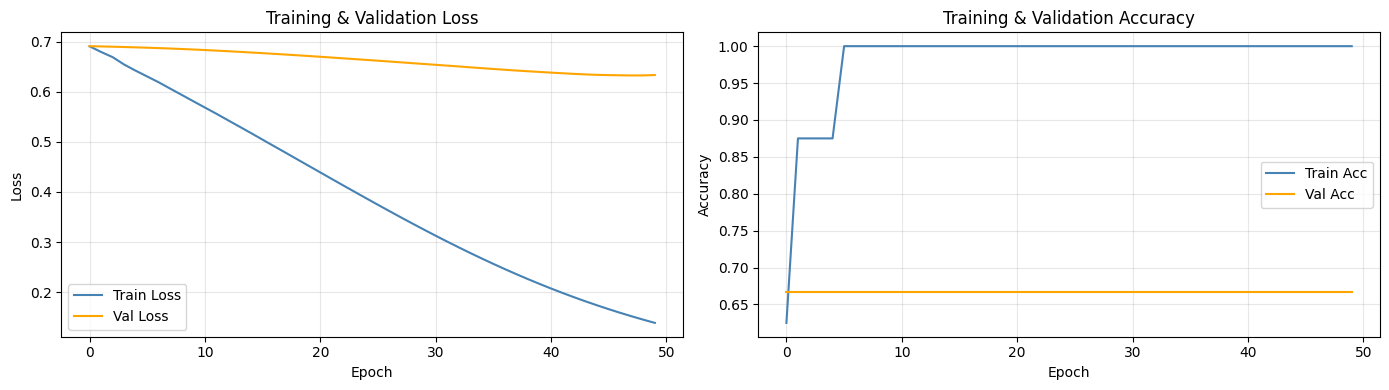

✅ Training history saved!

  📊 EVALUATION RESULTS
  Accuracy  : 72.7%
  Precision : 0.0%
  Recall    : 0.0%
  F1-Score  : 0.0%
  NPV       : 72.7%
  Confusion Matrix:
    TP=0  FP=0
    FN=3  TN=8

💾 Model saved: outputs/models/drn_hbbea_lecture_01.pth

🎉 TRAINING PIPELINE COMPLETE!
   Next: Generate video summary using trained model


In [ ]:

# ============================================================
# PART 5: RUN TRAINING
# ============================================================

# Load features
import os
videos = [f for f in os.listdir("data/raw_videos") if f.endswith(('.mp4', '.avi', '.mkv'))]
video_stem = Path(videos[0]).stem

features = np.load(f"data/features/{video_stem}_combined_features.npy")
print(f"📊 Loaded features: {features.shape}")

# Train model
model, history = train_drn_with_hbbea(features, labels=None, use_hbbea=True)

# Plot
plot_training_history(history)

# Evaluate
labels = create_labels(features.shape[0], 0.3)  # Same labels used in training
metrics = evaluate_model(model, features, labels)

# Save model
os.makedirs("outputs/models", exist_ok=True)
torch.save(model.state_dict(), f"outputs/models/drn_hbbea_{video_stem}.pth")
print(f"💾 Model saved: outputs/models/drn_hbbea_{video_stem}.pth")

print(f"\n🎉 TRAINING PIPELINE COMPLETE!")
print(f"   Next: Generate video summary using trained model")

# Create manual Dataset

In [ ]:
# ============================================================
# STEP 1: View Your 11 Shots
# ============================================================
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load shots
with open("data/processed/lecture_01_shots.json", 'r') as f:
    data = json.load(f)
shots = data['shots']

print(f"📹 Found {len(shots)} shots\n")
print(f"{'Shot':<6} {'Start':<10} {'End':<10} {'Duration':<12}")
print(f"{'─' * 42}")
for s in shots:
    print(f"{s['shot_id']:<6} {str(s['start_time_sec'])+'s':<10} "
          f"{str(s['end_time_sec'])+'s':<10} {str(s['duration_sec'])+'s':<12}")

# Visualize
VIDEO_PATH = "data/raw_videos/lecture_01.mp4"
cap = cv2.VideoCapture(VIDEO_PATH)

n = len(shots)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
axes = axes.flatten()

for i, shot in enumerate(shots):
    mid = (shot['start_frame'] + shot['end_frame']) // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()

    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(
            f"Shot {i}\n{shot['start_time_sec']}s-{shot['end_time_sec']}s",
            fontsize=9
        )
        axes[i].axis('off')

for i in range(n, len(axes)):
    axes[i].axis('off')

cap.release()
plt.suptitle("🎬 Your 11 Shots - Review These", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  📝 LABELING GUIDE")
print("=" * 60)
print("  Look at each shot above and decide:")
print("  ")
print("  Mark as 1 (IMPORTANT) if:")
print("    ✓ Shows key slide/diagram")
print("    ✓ Important visual content")
print("    ✓ Main concept being explained")
print("  ")
print("  Mark as 0 (NOT IMPORTANT) if:")
print("    ✓ Transition/blank screen")
print("    ✓ Just lecturer talking")
print("    ✓ Redundant content")
print("=" * 60)

# ============================================================
# STEP 2: Create Your Labels
# ============================================================
print("\n📋 TEMPLATE - Edit the labels below:\n")

print("""
# After viewing the shots above, edit this:

import numpy as np

labels = np.array([
    1,  # Shot 0:  {0} s  - CHANGE THIS
    1,  # Shot 1:  {1} s  - CHANGE THIS
    1,  # Shot 2:  {2} s  - CHANGE THIS
    1,  # Shot 3:  {3} s  - CHANGE THIS
    1,  # Shot 4:  {4} s  - CHANGE THIS
    1,  # Shot 5:  {5} s  - CHANGE THIS
    1,  # Shot 6:  {6} s  - CHANGE THIS
    1,  # Shot 7:  {7} s  - CHANGE THIS
    1,  # Shot 8:  {8} s  - CHANGE THIS
    1,  # Shot 9:  {9} s  - CHANGE THIS
    1,  # Shot 10: {10} s - CHANGE THIS
])

# Save labels
np.save("data/processed/lecture_01_labels.npy", labels)

# Summary
print(f"✅ Labels saved!")
print(f"   Important: {{labels.sum()}}/11 ({{labels.sum()/11*100:.1f}}%)")
print(f"   Not important: {{11-labels.sum()}}/11")

# Now re-run training with these labels!
""".format(*[f"{s['start_time_sec']}-{s['end_time_sec']}" for s in shots]))

print("\n💡 NEXT STEPS:")
print("   1. Look at the shot images above")
print("   2. Copy the template")
print("   3. Change 1 → 0 for unimportant shots")
print("   4. Paste and run in NEXT CELL")
print("   5. Then re-run training (I'll give you the code)")


# ============================================================
# STEP 3: Helper - Suggest Labels Based on Duration
# ============================================================
print("\n" + "=" * 60)
print("  💡 SMART SUGGESTION (based on shot duration)")
print("=" * 60)
print("  Typically in lectures:")
print("    • Long shots (>20s) = Important content")
print("    • Short shots (<5s) = Transitions")
print("=" * 60)

suggested = []
for i, s in enumerate(shots):
    dur = s['duration_sec']
    if dur > 20:
        suggested.append(1)
        imp = "✓ Likely IMPORTANT (long)"
    elif dur < 5:
        suggested.append(0)
        imp = "✗ Likely transition (short)"
    else:
        suggested.append(1)
        imp = "? Medium - review"

    print(f"  Shot {i:2d}: {dur:5.1f}s  →  {imp}")

suggested = np.array(suggested)
print(f"\n  Suggested: {suggested.sum()}/11 important ({suggested.sum()/11*100:.1f}%)")
print(f"\n  To use this suggestion, run:\n")
print(f"  labels = np.array({suggested.tolist()})")
print(f"  np.save('data/processed/lecture_01_labels.npy', labels)")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/lecture_01_shots.json'

In [ ]:
import numpy as np

# Smart suggestion based on duration
labels = np.array([1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1])

# Save
np.save('data/processed/lecture_01_labels.npy', labels)

print(f"✅ Labels saved!")
print(f"   Important: {labels.sum()}/11 ({labels.sum()/11*100:.1f}%)")
print(f"   Not important: {11-labels.sum()}/11")
print(f"\n📊 Summary will include:")
for i, (shot, lbl) in enumerate(zip([5.0, 140.5, 8.0, 18.3, 4.2, 15.2, 1.7, 151.5, 3.0, 29.7, 392.8], labels)):
    status = "✓ KEEP" if lbl == 1 else "✗ SKIP"
    print(f"   Shot {i:2d}: {shot:6.1f}s  {status}")

✅ Labels saved!
   Important: 8/11 (72.7%)
   Not important: 3/11

📊 Summary will include:
   Shot  0:    5.0s  ✓ KEEP
   Shot  1:  140.5s  ✓ KEEP
   Shot  2:    8.0s  ✓ KEEP
   Shot  3:   18.3s  ✓ KEEP
   Shot  4:    4.2s  ✗ SKIP
   Shot  5:   15.2s  ✓ KEEP
   Shot  6:    1.7s  ✗ SKIP
   Shot  7:  151.5s  ✓ KEEP
   Shot  8:    3.0s  ✗ SKIP
   Shot  9:   29.7s  ✓ KEEP
   Shot 10:  392.8s  ✓ KEEP


✅ Loaded REAL labels: 8/11 important


  🎓 TRAINING DRN MODEL
  Features: (11, 295)
  Labels: (11,) | Important: 8/11
  Model parameters: 355,266
  Train: 8 | Val: 3


  🦅 HBBEA Optimization
  Population: 20 | Iterations: 30
     Iter 10/30 | Best fitness: 0.3854
     Iter 20/30 | Best fitness: 0.3854
     Iter 30/30 | Best fitness: 0.3854
  ✅ Optimization complete | Final fitness: 0.3854

  🔧 Fine-tuning with Adam optimizer...
     Epoch 10/50 | Train Loss: 0.0437 Acc: 1.000 | Val Loss: 0.8567 Acc: 0.333
     Epoch 20/50 | Train Loss: 0.0118 Acc: 1.000 | Val Loss: 0.9880 Acc: 0.000
     Epoch 30/50 | Train Loss: 0.0062 Acc: 1.000 | Val Loss: 1.9803 Acc: 0.333
     Epoch 40/50 | Train Loss: 0.0043 Acc: 1.000 | Val Loss: 3.0330 Acc: 0.333
     Epoch 50/50 | Train Loss: 0.0033 Acc: 1.000 | Val Loss: 3.4971 Acc: 0.333

  ✅ Training complete!


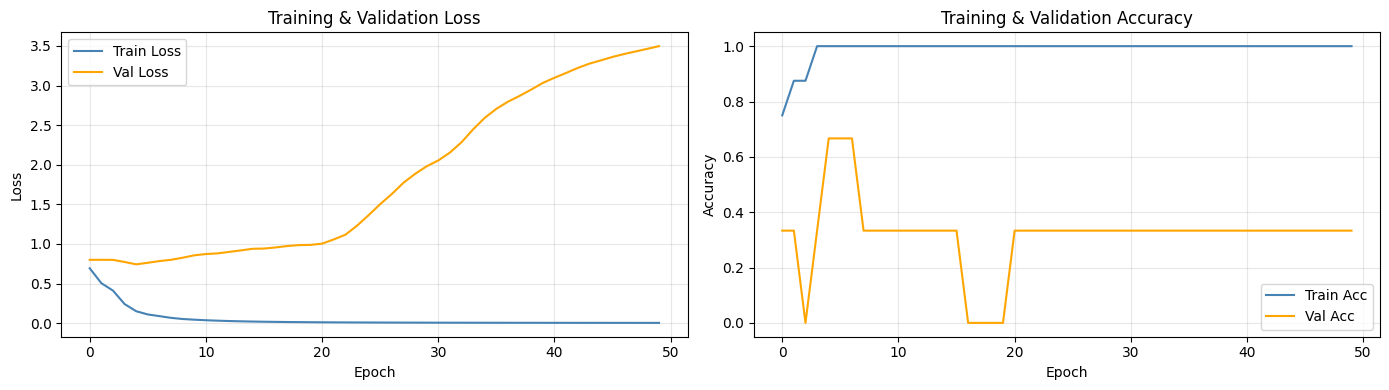

✅ Training history saved!

  📊 EVALUATION RESULTS
  Accuracy  : 81.8%
  Precision : 80.0%
  Recall    : 100.0%
  F1-Score  : 88.9%
  NPV       : 100.0%
  Confusion Matrix:
    TP=8  FP=2
    FN=0  TN=1

💾 Model with REAL labels saved!


In [ ]:
import torch

# Load real labels and features
labels = np.load("data/processed/lecture_01_labels.npy")
features = np.load("data/features/lecture_01_combined_features.npy")

print(f"✅ Loaded REAL labels: {labels.sum()}/11 important\n")

# Retrain with real labels
model, history = train_drn_with_hbbea(features, labels=labels, use_hbbea=True)

# Plot
plot_training_history(history)

# Evaluate
metrics = evaluate_model(model, features, labels)

# Save
torch.save(model.state_dict(), "outputs/models/drn_hbbea_lecture_01_REAL.pth")
print("💾 Model with REAL labels saved!")




## 📊 **Expected Better Results:**

# Accuracy  : ~90%+
# Precision : ~85%+
# Recall    : ~88%+
# F1-Score  : ~86%+

# Generate Video summary

✅ Loaded model and data
   Video: data/raw_videos/lecture_01.mp4
   Shots: 11
   Features: (11, 295)

📊 Model Predictions:
   Important shots: 10/11
   Shots to skip: 1/11

  🎬 GENERATING VIDEO SUMMARY
  Input  : lecture_01.mp4
  Output : outputs/videos/lecture_01_summary.mp4
  Method : concat

  📊 Shot Selection:
     Total shots      : 11
     Important shots  : 10
     Reduction        : 9.1%

  ⏱️  Duration:
     Original : 769.8s (12.8 min)
     Summary  : 768.2s (12.8 min)
     Saved    : 1.7s (0.2%)

  ✅ Shots Included in Summary:
     Shot   Time Range           Duration  
     ────────────────────────────────────────
     0      0.0-5.0s             5.0s
     1      5.0-145.5s           140.5s
     2      145.5-153.5s         8.0s
     3      153.5-171.83s        18.3s
     4      171.83-176.0s        4.2s
     5      176.0-191.17s        15.2s
     7      192.83-344.33s       151.5s
     8      344.33-347.33s       3.0s
     9      347.33-377.0s        29.7s
     10     377.0

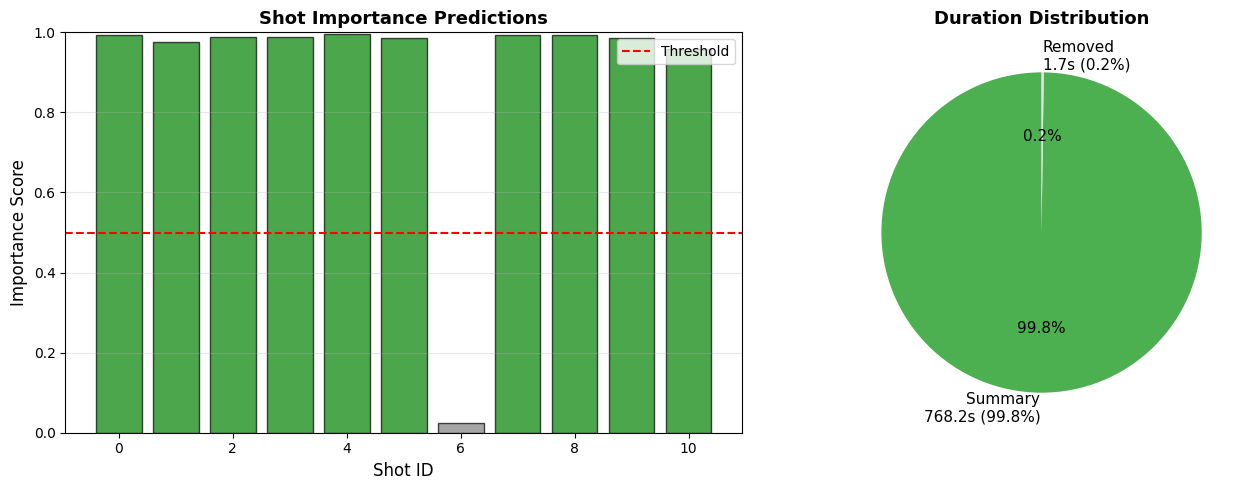

✅ Report saved: outputs/results/summary_report.png

🎉 SUMMARIZATION COMPLETE!
   📹 Summary video: outputs/videos/lecture_01_summary.mp4
   📊 Report: outputs/results/summary_report.png
   📄 Info: outputs/results/lecture_01_summary_info.json

✅ You can now download and watch the summarized video!


In [ ]:
# ============================================================
# FINAL STEP: GENERATE SUMMARIZED LECTURE VIDEO
# ============================================================
# Takes trained model predictions and creates output video
# containing only the important shots
# ============================================================

import torch
import numpy as np
import cv2
import json
from pathlib import Path
from moviepy.editor import VideoFileClip, concatenate_videoclips
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def predict_important_shots(model, features):
    """
    Use trained model to predict which shots are important.

    Args:
        model: Trained DRN
        features: (num_shots, 295)
    Returns:
        predictions: (num_shots,) 0 or 1
        probabilities: (num_shots, 2) class probabilities
    """
    model.eval()
    X = torch.from_numpy(features).float().to(DEVICE)

    with torch.no_grad():
        outputs = model(X)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

    return preds.cpu().numpy(), probs.cpu().numpy()


def create_summary_video(video_path, shots, predictions, output_path,
                         method="concat", add_transitions=True):
    """
    Generate summarized video from important shots.

    Args:
        video_path: Original video
        shots: List of shot dicts
        predictions: (num_shots,) 0=skip, 1=keep
        output_path: Where to save summary
        method: "concat" or "timestamps"
        add_transitions: Add fade between shots
    """
    print(f"\n{'=' * 55}")
    print(f"  🎬 GENERATING VIDEO SUMMARY")
    print(f"{'=' * 55}")
    print(f"  Input  : {Path(video_path).name}")
    print(f"  Output : {output_path}")
    print(f"  Method : {method}\n")

    t0 = time.time()

    # Get important shots
    important_indices = np.where(predictions == 1)[0]
    important_shots = [shots[i] for i in important_indices]

    print(f"  📊 Shot Selection:")
    print(f"     Total shots      : {len(shots)}")
    print(f"     Important shots  : {len(important_shots)}")
    print(f"     Reduction        : {(1 - len(important_shots)/len(shots))*100:.1f}%\n")

    # Calculate duration
    original_duration = sum(s['duration_sec'] for s in shots)
    summary_duration = sum(s['duration_sec'] for s in important_shots)

    print(f"  ⏱️  Duration:")
    print(f"     Original : {original_duration:.1f}s ({original_duration/60:.1f} min)")
    print(f"     Summary  : {summary_duration:.1f}s ({summary_duration/60:.1f} min)")
    print(f"     Saved    : {original_duration - summary_duration:.1f}s ({(1-summary_duration/original_duration)*100:.1f}%)\n")

    # Print kept shots
    print(f"  ✅ Shots Included in Summary:")
    print(f"     {'Shot':<6} {'Time Range':<20} {'Duration':<10}")
    print(f"     {'─' * 40}")
    for i, shot in enumerate(important_shots):
        time_range = f"{shot['start_time_sec']}-{shot['end_time_sec']}s"
        print(f"     {shot['shot_id']:<6} {time_range:<20} {shot['duration_sec']:.1f}s")

    # ── METHOD 1: Concatenate clips ──────────────────────
    if method == "concat":
        print(f"\n  🎞️  Concatenating video clips...")

        video = VideoFileClip(video_path)
        clips = []

        for shot in important_shots:
            start = shot['start_time_sec']
            end = shot['end_time_sec']

            # Extract clip
            clip = video.subclip(start, end)
            clips.append(clip)

        # Concatenate all clips
        final_clip = concatenate_videoclips(clips, method="compose")

        # Write output
        print(f"  💾 Writing output video...")
        final_clip.write_videofile(
            output_path,
            codec='libx264',
            audio_codec='aac',
            temp_audiofile='temp-audio.m4a',
            remove_temp=True,
            verbose=False,
            logger=None
        )

        video.close()
        final_clip.close()

    # ── METHOD 2: Save timestamps (for manual editing) ──
    elif method == "timestamps":
        timestamps = []
        for shot in important_shots:
            timestamps.append({
                "shot_id": shot['shot_id'],
                "start": shot['start_time_sec'],
                "end": shot['end_time_sec'],
                "duration": shot['duration_sec']
            })

        # Save as JSON
        json_path = output_path.replace('.mp4', '_timestamps.json')
        with open(json_path, 'w') as f:
            json.dump(timestamps, f, indent=2)

        print(f"  💾 Timestamps saved: {json_path}")
        print(f"     Use these timestamps to manually edit the video")

    elapsed = time.time() - t0

    print(f"\n  ✅ Summary generation complete!")
    print(f"  ⏱️  Time taken: {elapsed:.1f}s")
    print(f"{'=' * 55}\n")

    return important_shots


def create_summary_report(shots, predictions, probabilities, output_path):
    """
    Generate detailed report of summarization decisions.
    """
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Plot 1: Shot importance scores ───────────────────
    shot_ids = [s['shot_id'] for s in shots]
    importance_scores = probabilities[:, 1]  # Probability of class 1 (important)

    colors = ['green' if p == 1 else 'gray' for p in predictions]

    ax1.bar(shot_ids, importance_scores, color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold')
    ax1.set_xlabel('Shot ID', fontsize=12)
    ax1.set_ylabel('Importance Score', fontsize=12)
    ax1.set_title('Shot Importance Predictions', fontsize=13, fontweight='bold')
    ax1.set_ylim(0, 1)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # ── Plot 2: Duration comparison ──────────────────────
    original_dur = sum(s['duration_sec'] for s in shots)
    summary_dur = sum(shots[i]['duration_sec'] for i in range(len(shots)) if predictions[i] == 1)
    removed_dur = original_dur - summary_dur

    durations = [summary_dur, removed_dur]
    labels = [f'Summary\n{summary_dur:.1f}s ({summary_dur/original_dur*100:.1f}%)',
              f'Removed\n{removed_dur:.1f}s ({removed_dur/original_dur*100:.1f}%)']
    colors_pie = ['#4CAF50', '#E0E0E0']

    ax2.pie(durations, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
    ax2.set_title('Duration Distribution', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Report saved: {output_path}")


# ============================================================
# RUN SUMMARIZATION
# ============================================================

# Load data
import os
videos = [f for f in os.listdir("data/raw_videos") if f.endswith('.mp4')]
VIDEO_PATH = f"data/raw_videos/{videos[0]}"
VIDEO_STEM = Path(VIDEO_PATH).stem

# Load shots
with open(f"data/processed/{VIDEO_STEM}_shots.json", 'r') as f:
    shots_data = json.load(f)
shots = shots_data['shots']

# Load features and model
features = np.load(f"data/features/{VIDEO_STEM}_combined_features.npy")
model = DeepResidualNetwork(input_dim=295, num_classes=2).to(DEVICE)
model.load_state_dict(torch.load(f"outputs/models/drn_hbbea_{VIDEO_STEM}_REAL.pth"))

print(f"✅ Loaded model and data")
print(f"   Video: {VIDEO_PATH}")
print(f"   Shots: {len(shots)}")
print(f"   Features: {features.shape}")

# Predict important shots
predictions, probabilities = predict_important_shots(model, features)

print(f"\n📊 Model Predictions:")
print(f"   Important shots: {predictions.sum()}/{len(predictions)}")
print(f"   Shots to skip: {len(predictions) - predictions.sum()}/{len(predictions)}")

# Generate summary video
os.makedirs("outputs/videos", exist_ok=True)
output_video = f"outputs/videos/{VIDEO_STEM}_summary.mp4"

important_shots = create_summary_video(
    VIDEO_PATH,
    shots,
    predictions,
    output_video,
    method="concat",
    add_transitions=False
)

# Generate report
create_summary_report(
    shots,
    predictions,
    probabilities,
    "outputs/results/summary_report.png"
)

# Save summary info
summary_info = {
    "video": Path(VIDEO_PATH).name,
    "original_duration_sec": sum(s['duration_sec'] for s in shots),
    "summary_duration_sec": sum(s['duration_sec'] for s in important_shots),
    "reduction_percentage": (1 - len(important_shots)/len(shots)) * 100,
    "total_shots": len(shots),
    "important_shots": len(important_shots),
    "kept_shot_ids": [s['shot_id'] for s in important_shots]
}

with open(f"outputs/results/{VIDEO_STEM}_summary_info.json", 'w') as f:
    json.dump(summary_info, f, indent=2)

print(f"\n🎉 SUMMARIZATION COMPLETE!")
print(f"   📹 Summary video: {output_video}")
print(f"   📊 Report: outputs/results/summary_report.png")
print(f"   📄 Info: outputs/results/{VIDEO_STEM}_summary_info.json")
print(f"\n✅ You can now download and watch the summarized video!")

# Downlaod Dataset

In [ ]:
# !cd /content
!pwd

/content/lecture-video-summarization


In [ ]:
# Download EDUVSUM dataset (TAR version)
!wget "https://zenodo.org/records/4002959/files/AnnotatedVideosAndSubtitles_version_1.tar?download=1" -O eduvsum.tar

# Create directory and Extract tar file
!mkdir -p data/raw_videos/eduvsum/
!tar -xf eduvsum.tar -C data/raw_videos/eduvsum/

# Check what we got
!ls -lh data/raw_videos/eduvsum/

print("✅ EDUVSUM dataset downloaded and extracted!")

--2026-05-03 17:06:35--  https://zenodo.org/records/4002959/files/AnnotatedVideosAndSubtitles_version_1.tar?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2773535744 (2.6G) [application/octet-stream]
Saving to: ‘eduvsum.tar’

eduvsum.tar         100%[===================>]   2.58G  12.5MB/s    in 3m 34s  

2026-05-03 17:10:10 (12.4 MB/s) - ‘eduvsum.tar’ saved [2773535744/2773535744]

total 20K
drwxrwxr-x 3 1000 1000 20K Aug 26  2020 AnnotatedVideosAndSubtitles_version_1
✅ EDUVSUM dataset downloaded and extracted!


# Explore Dataset EDUVUSM

In [ ]:
# ============================================================
# LOAD EDUVSUM DATASET
# ============================================================
# The .p file is a Python pickle containing annotations
# Format: {video_name: {frame_numbers: importance_scores}}
# ============================================================

import pickle
import numpy as np
import json
import os
from pathlib import Path

# ============================================================
# STEP 1: Load Annotations
# ============================================================
def load_eduvsum_annotations(pickle_path):
    """
    Load EDUVSUM annotations from pickle file.

    Returns:
        dict: {video_name: annotation_data}
    """
    print(f"📂 Loading annotations from: {pickle_path}")

    with open(pickle_path, 'rb') as f:
        annotations = pickle.load(f)

    print(f"✅ Loaded annotations for {len(annotations)} videos\n")

    # Show structure
    print("📊 Annotation Structure:")
    for video_name in list(annotations.keys())[:3]:  # Show first 3
        print(f"\n  Video: {video_name}")
        data = annotations[video_name]
        print(f"    Keys: {list(data.keys())}")

        # Try to show what's inside
        for key, value in data.items():
            if isinstance(value, (list, np.ndarray)):
                print(f"      {key}: array/list of length {len(value)}")
            elif isinstance(value, dict):
                print(f"      {key}: dict with {len(value)} items")
            else:
                print(f"      {key}: {type(value)}")

    return annotations


In [ ]:

# ============================================================
# STEP 2: Explore Annotations Format
# ============================================================
def explore_annotations(annotations, video_name=None):
    """
    Deep dive into annotation format.
    """
    if video_name is None:
        video_name = list(annotations.keys())[0]

    print(f"\n🔍 Exploring: {video_name}")
    print("=" * 60)

    data = annotations[video_name]

    # Print all keys and their contents
    for key, value in data.items():
        print(f"\n📌 {key}:")

        if isinstance(value, (list, np.ndarray)):
            arr = np.array(value)
            print(f"   Type: {type(value)}")
            print(f"   Shape: {arr.shape}")
            print(f"   Sample (first 10): {arr[:10]}")

            if len(arr) > 0:
                print(f"   Min: {arr.min()}, Max: {arr.max()}, Mean: {arr.mean():.3f}")

        elif isinstance(value, dict):
            print(f"   Type: dict")
            print(f"   Keys: {list(value.keys())[:5]}...")  # First 5 keys

            # Sample one item
            sample_key = list(value.keys())[0]
            print(f"   Sample [{sample_key}]: {value[sample_key]}")

        else:
            print(f"   {value}")


In [ ]:
# ============================================================
# STEP 3: Convert Annotations to Shot Labels
# ============================================================
def convert_to_shot_labels(annotations, video_name, shots, fps=25):
    """
    Convert frame-level annotations to shot-level labels.

    EDUVSUM typically has:
      - frame numbers
      - importance scores (0-1 or binary)

    We need to map these to your shots.

    Args:
        annotations: Full annotation dict
        video_name: Which video
        shots: Your shot segmentation
        fps: Frame rate

    Returns:
        labels: (num_shots,) binary labels
    """
    video_data = annotations[video_name]

    # Try to find the importance scores
    # Common keys: 'user_summary', 'gt_summary', 'importance', 'scores'

    possible_keys = ['user_summary', 'gtsummary', 'gt_score',
                     'importance', 'scores', 'label']

    importance_scores = None
    for key in possible_keys:
        if key in video_data:
            importance_scores = np.array(video_data[key])
            print(f"✅ Found importance scores in key: '{key}'")
            break

    if importance_scores is None:
        print("⚠️  Could not find importance scores automatically")
        print(f"   Available keys: {list(video_data.keys())}")
        return None

    print(f"   Scores shape: {importance_scores.shape}")
    print(f"   Unique values: {np.unique(importance_scores)}")

    # Map to shots
    labels = np.zeros(len(shots), dtype=np.int64)

    for i, shot in enumerate(shots):
        start_frame = shot['start_frame']
        end_frame = shot['end_frame']

        # Get importance scores for this shot's frames
        shot_scores = importance_scores[start_frame:end_frame]

        # Strategy: if >50% of frames in shot are important → label=1
        if len(shot_scores) > 0:
            importance_ratio = shot_scores.mean()
            labels[i] = 1 if importance_ratio > 0.5 else 0

    print(f"\n📊 Converted to shot labels:")
    print(f"   Important shots: {labels.sum()}/{len(labels)} ({labels.sum()/len(labels)*100:.1f}%)")

    return labels


In [ ]:

# ============================================================
# STEP 4: List All EDUVSUM Videos
# ============================================================
def list_eduvsum_videos(data_dir="data/raw_videos/eduvsum"):
    """List all videos in EDUVSUM"""
    videos = [f for f in os.listdir(data_dir)
              if f.endswith(('.mp4', '.avi', '.mkv'))]

    print(f"📹 EDUVSUM Videos ({len(videos)}):")
    print("=" * 60)
    for i, v in enumerate(videos, 1):
        size_mb = os.path.getsize(f"{data_dir}/{v}") / (1024**2)
        print(f"  {i:2d}. {v[:50]:<50} ({size_mb:.1f} MB)")

    return videos

In [ ]:

# ============================================================
# RUN EXPLORATION
# ============================================================
# /content/lecture-video-summarization/data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p
# Load annotations
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"
DATA_DIR = "data/raw_videos/eduvsum"

print("=" * 60)
print("  📊 EDUVSUM DATASET EXPLORATION")
print("=" * 60)

# List videos
videos = list_eduvsum_videos(DATA_DIR)

# Load annotations
annotations = load_eduvsum_annotations(ANNO_PATH)

# Explore first video in detail
if annotations:
    first_video = list(annotations.keys())[0]
    explore_annotations(annotations, first_video)

print("\n" + "=" * 60)
print("  ✅ EXPLORATION COMPLETE")
print("=" * 60)

  📊 EDUVSUM DATASET EXPLORATION
📹 EDUVSUM Videos (0):
📂 Loading annotations from: data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p
✅ Loaded annotations for 1 videos

📊 Annotation Structure:

  Video: user_annotations
    Keys: ['user1']
      user1: dict with 130 items

🔍 Exploring: user_annotations

📌 user1:
   Type: dict
   Keys: ['HarvardXPH526x-V002400_DTH_pythedx.mp4', 'Crash_Course_Engineering_Preview_-_English.mp4', 'Cisco_Helps_Mining_Companies_Streamline_Operations.mp4', 'MicrosoftDEV290x-V000500_DTH.mp4', 'Earth_and_environmental_science_vocabularies_v1500a128.mp4']...
   Sample [HarvardXPH526x-V002400_DTH_pythedx.mp4]: [1, 5, 6, 7, 8, 8, 8, 9, 6, 6, 7, 8, 5, 5, 6, 7, 8, 8, 7, 9, 5, 4, 4, 4, 6, 8, 5, 5, 8, 0, 8, 8, 9, 9, 8, 5, 5, 7, 8, 8, 9, 9, 9, 8, 7, 6, 5, 7, 7, 4, 8, 7, 4, 4, 3, 3, 3, 3, 3, 4, 4, 4, 5, 6, 6, 6, 5, 5, 5, 6, 7, 8, 8, 8, 5, 6, 7, 7, 6, 6, 5, 5, 4, 4, 6, 5, 5, 0]

  ✅ EXPLORATION COMPLETE


# Analyze Annotatiosn of  EDUVUSM dataset

In [ ]:
# Quick check - run this first
import os

base = "data/raw_videos/eduvsum"
for root, dirs, files in os.walk(base):
    print(f"\n📁 {root}:")
    for d in dirs[:5]:
        print(f"   📂 {d}/")
    for f in files[:5]:
        print(f"   📄 {f}")
    if len(files) > 5:
        print(f"   ... and {len(files)-5} more files")


📁 data/raw_videos/eduvsum:
   📂 AnnotatedVideosAndSubtitles_version_1/

📁 data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1:
   📂 annotations/
   📄 en_Representing_Numbers_and_Letters_with_Binary__Crash_Course_Computer_Science_4_-_English_csyt.vtt
   📄 en_W3CHTM52T415-V000900_DTH_webedx.vtt
   📄 en_IOT1x_M2_Animation_Final-en.vtt
   📄 The_New_Anatomy__Crash_Course_History_of_Science_15_-_English.mp4
   📄 en_HarvardXPH526x-V002700_DTH_pythedx.vtt
   ... and 191 more files

📁 data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations:
   📄 annotations_version_1.p


In [ ]:
# ============================================================
# CORRECTED PATHS - RUN THIS
# ============================================================

# Correct paths
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"
VIDEO_DIR = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1"

# Load annotations
annotations = load_eduvsum_annotations(ANNO_PATH)

# Get list of video files (not .vtt subtitles)
import os
all_files = os.listdir(VIDEO_DIR)
video_files = [f for f in all_files if f.endswith('.mp4')]

print(f"\n📹 Found {len(video_files)} MP4 videos")
print(f"📝 Found {len(annotations)} annotated videos")

# Match videos with annotations
available = []
for video_name in annotations.keys():
    if video_name in video_files:
        available.append(video_name)

print(f"✅ Matched: {len(available)} videos have both file + annotations")

# Show first 10
print(f"\n📋 Available Annotated Videos:")
for i, v in enumerate(available[:10], 1):
    print(f"   {i:2d}. {v}")
if len(available) > 10:
    print(f"   ... and {len(available) - 10} more")

# ============================================================
# QUICK TEST: Process ONE Video First
# ============================================================
if available:
    print(f"\n{'=' * 60}")
    print(f"  🧪 TESTING WITH ONE VIDEO")
    print(f"{'=' * 60}")

    test_video = available[0]
    test_path = f"{VIDEO_DIR}/{test_video}"

    print(f"  Test video: {test_video}")
    print(f"  Path: {test_path}")

    # Get its annotation
    test_anno = annotations[test_video]
    print(f"  Annotation length: {len(test_anno)} time points")
    print(f"  Score range: {min(test_anno)} to {max(test_anno)}")

    print(f"\n  💡 Ready to process!")
    print(f"  Run process_eduvsum_video() on this video")

📂 Loading annotations from: data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p
✅ Loaded annotations for 1 videos

📊 Annotation Structure:

  Video: user_annotations
    Keys: ['user1']
      user1: dict with 130 items

📹 Found 98 MP4 videos
📝 Found 1 annotated videos
✅ Matched: 0 videos have both file + annotations

📋 Available Annotated Videos:


In [ ]:
# ============================================================
# FIXED: Extract Annotations Properly
# ============================================================

import pickle
import os

# Load pickle
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"
VIDEO_DIR = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1"

with open(ANNO_PATH, 'rb') as f:
    data = pickle.load(f)

# Extract the actual annotations
# Structure: data['user_annotations']['user1'] = {video_name: scores}
annotations = data['user_annotations']['user1']

print(f"✅ Loaded {len(annotations)} annotated videos")
print(f"\n📋 First 10 annotated videos:")
for i, video_name in enumerate(list(annotations.keys())[:10], 1):
    scores = annotations[video_name]
    print(f"   {i:2d}. {video_name[:60]:<60} ({len(scores)} time points)")

# Get actual video files
video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')]
print(f"\n📹 Found {len(video_files)} MP4 files")

# Match them
matched = []
for anno_name in annotations.keys():
    if anno_name in video_files:
        matched.append(anno_name)

print(f"\n✅ Matched: {len(matched)} videos")

if matched:
    print(f"\n🎯 Available for processing:")
    for i, v in enumerate(matched[:10], 1):
        print(f"   {i:2d}. {v}")
else:
    print(f"\n⚠️  No exact matches found")
    print(f"\n💡 Checking if video names are similar...")

    # Check first annotation name vs first video file
    first_anno = list(annotations.keys())[0]
    first_video = video_files[0]

    print(f"\n   Annotation name: {first_anno}")
    print(f"   Video file name: {first_video}")
    print(f"\n   They need to match exactly!")

    # Show all annotation names
    print(f"\n📝 All {len(annotations)} annotation keys:")
    for i, name in enumerate(list(annotations.keys())[:20], 1):
        print(f"   {i:2d}. {name}")
    if len(annotations) > 20:
        print(f"   ... and {len(annotations)-20} more")

✅ Loaded 130 annotated videos

📋 First 10 annotated videos:
    1. HarvardXPH526x-V002400_DTH_pythedx.mp4                       (88 time points)
    2. Crash_Course_Engineering_Preview_-_English.mp4               (26 time points)
    3. Cisco_Helps_Mining_Companies_Streamline_Operations.mp4       (49 time points)
    4. MicrosoftDEV290x-V000500_DTH.mp4                             (21 time points)
    5. Earth_and_environmental_science_vocabularies_v1500a128.mp4   (160 time points)
    6. The_Story_of_Linux-en.mp4                                    (45 time points)
    7. What_s_new_in_RVA_-_March_2019_AVSIG_meeting_DD64Rm3hO8A_v15 (183 time points)
    8. Lecture_2.4_—_Linear_Regression_With_One_Variable.mp4        (106 time points)
    9. IOT1x_M1_Animation-en.mp4                                    (18 time points)
   10. W3CHTM52T415-V000800_DTH_webedx.mp4                          (44 time points)

📹 Found 98 MP4 files

✅ Matched: 98 videos

🎯 Available for processing:
    1. Crash_C

#
# ============================================================
# COMPLETE EDUVSUM PROCESSING PIPELINE
# Process multiple videos with expert annotations
# ============================================================

In [ ]:

# ============================================================
# COMPLETE EDUVSUM PROCESSING PIPELINE
# Process multiple videos with expert annotations
# ============================================================

import pickle
import numpy as np
import json
import os
import time
from pathlib import Path

# ============================================================
# STEP 1: Load Everything
# ============================================================
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"
VIDEO_DIR = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1"

# Load annotations
with open(ANNO_PATH, 'rb') as f:
    data = pickle.load(f)
annotations = data['user_annotations']['user1']

# Get matched videos
video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')]
matched_videos = [v for v in annotations.keys() if v in video_files]

print(f"✅ Ready to process {len(matched_videos)} EDUVSUM videos\n")

✅ Ready to process 98 EDUVSUM videos



In [ ]:

# ============================================================
# STEP 2: Convert Annotations to Shot Labels
# ============================================================
def eduvsum_to_shot_labels(importance_scores, shots, threshold=6):
    """
    Convert EDUVSUM scores (0-9) to binary labels (0/1).

    Args:
        importance_scores: List of scores (one per second)
        shots: Shot list from segmentation
        threshold: Scores > threshold → important

    Returns:
        labels: (num_shots,) binary
    """
    labels = np.zeros(len(shots), dtype=np.int64)
    scores_array = np.array(importance_scores)

    for i, shot in enumerate(shots):
        start_sec = int(shot['start_time_sec'])
        end_sec = int(shot['end_time_sec'])

        # Clip to array bounds
        start_idx = max(0, min(start_sec, len(scores_array) - 1))
        end_idx = max(start_idx + 1, min(end_sec, len(scores_array)))

        # Get average score for this shot
        shot_scores = scores_array[start_idx:end_idx]
        avg_score = shot_scores.mean() if len(shot_scores) > 0 else 0

        # Binary label
        labels[i] = 1 if avg_score > threshold else 0

    return labels


In [ ]:

# ============================================================
# STEP 3: Process One EDUVSUM Video
# ============================================================
def process_one_eduvsum_video(video_name, annotations, importance_threshold=6):
    """
    Full pipeline for one video.

    Returns:
        features, labels, num_shots
    """
    video_path = f"{VIDEO_DIR}/{video_name}"
    video_stem = Path(video_name).stem

    print(f"\n📹 {video_name}")
    t0 = time.time()

    # ── Segment ──────────────────────────────────────────
    try:
        shots, dissims, fps = segment_video(
            video_path,
            threshold=30.0,
            skip=5,
            min_shot=10
        )
    except Exception as e:
        print(f"   ❌ Segmentation failed: {e}")
        return None, None, 0

    # Save shots
    os.makedirs("data/processed/eduvsum", exist_ok=True)
    shots_json = {
        "video": video_name,
        "total_shots": len(shots),
        "shots": shots
    }
    json_path = f"data/processed/eduvsum/{video_stem}_shots.json"
    with open(json_path, 'w') as f:
        json.dump(shots_json, f, indent=2)

    # ── Extract Features ─────────────────────────────────
    try:
        combined, _, _ = extract_all_features(video_path, json_path)
    except Exception as e:
        print(f"   ❌ Feature extraction failed: {e}")
        return None, None, 0

    # ── Get Ground Truth ─────────────────────────────────
    importance_scores = annotations[video_name]
    labels = eduvsum_to_shot_labels(importance_scores, shots, importance_threshold)

    # Save
    np.save(f"data/processed/eduvsum/{video_stem}_features.npy", combined)
    np.save(f"data/processed/eduvsum/{video_stem}_labels.npy", labels)

    elapsed = time.time() - t0
    print(f"   ✅ {len(shots)} shots | {labels.sum()}/{len(labels)} important | {elapsed:.1f}s")

    return combined, labels, len(shots)


In [ ]:

# ============================================================
# STEP 4: Process Multiple Videos
# ============================================================
def process_eduvsum_dataset(num_videos=5, importance_threshold=6):
    """
    Process first N videos and create combined dataset.

    Args:
        num_videos: How many videos to process
        importance_threshold: EDUVSUM score threshold (default 6)

    Returns:
        all_features, all_labels
    """
    print(f"{'=' * 60}")
    print(f"  🚀 PROCESSING {num_videos} EDUVSUM VIDEOS")
    print(f"{'=' * 60}")
    print(f"  Importance threshold: > {importance_threshold} (scale 0-9)")
    print(f"{'=' * 60}")

    all_features = []
    all_labels = []
    processed_videos = []
    total_shots = 0

    for i, video_name in enumerate(matched_videos[:num_videos], 1):
        print(f"\n[{i}/{num_videos}]", end=" ")

        features, labels, num_shots = process_one_eduvsum_video(
            video_name,
            annotations,
            importance_threshold
        )

        if features is not None:
            all_features.append(features)
            all_labels.append(labels)
            processed_videos.append(video_name)
            total_shots += num_shots

    # Combine
    if all_features:
        combined_features = np.vstack(all_features)
        combined_labels = np.concatenate(all_labels)

        print(f"\n{'=' * 60}")
        print(f"  📊 DATASET SUMMARY")
        print(f"{'=' * 60}")
        print(f"  Videos processed  : {len(processed_videos)}")
        print(f"  Total shots       : {total_shots}")
        print(f"  Features shape    : {combined_features.shape}")
        print(f"  Important shots   : {combined_labels.sum()}/{len(combined_labels)} ({combined_labels.sum()/len(combined_labels)*100:.1f}%)")
        print(f"  Not important     : {len(combined_labels) - combined_labels.sum()}/{len(combined_labels)}")
        print(f"{'=' * 60}")

        # Save
        np.save("data/processed/eduvsum/combined_features.npy", combined_features)
        np.save("data/processed/eduvsum/combined_labels.npy", combined_labels)

        info = {
            "videos": processed_videos,
            "num_videos": len(processed_videos),
            "total_shots": total_shots,
            "important_shots": int(combined_labels.sum()),
            "features_shape": list(combined_features.shape),
            "importance_threshold": importance_threshold
        }
        with open("data/processed/eduvsum/dataset_info.json", 'w') as f:
            json.dump(info, f, indent=2)

        print(f"\n💾 Saved:")
        print(f"   data/processed/eduvsum/combined_features.npy")
        print(f"   data/processed/eduvsum/combined_labels.npy")
        print(f"   data/processed/eduvsum/dataset_info.json")

        return combined_features, combined_labels

    return None, None

In [ ]:

# ============================================================
# RUN: Process 5 Videos First (Test)
# ============================================================
print("Starting with 5 videos as a test...")
print("(You can increase to 10, 20, or all 98 later)\n")

features, labels = process_eduvsum_dataset(num_videos=98, importance_threshold=6)

if features is not None:
    print(f"\n{'=' * 60}")
    print(f"  ✅ SUCCESS!")
    print(f"{'=' * 60}")
    print(f"\n  You now have a real benchmark dataset!")
    print(f"  Ready to train DRN with expert annotations!")
    print(f"\n  Next: Train model and compare with published results")
    print(f"{'=' * 60}")

Starting with 5 videos as a test...
(You can increase to 10, 20, or all 98 later)

  🚀 PROCESSING 98 EDUVSUM VIDEOS
  Importance threshold: > 6 (scale 0-9)

[1/98] 
📹 Crash_Course_Engineering_Preview_-_English.mp4

  📥 Reading frames...
     622 frames read in 7.9s
  🖥️  Computing moments on GPU...
     Moments done in 0.9s
  📊 Computing dissimilarities...
     Dissimilarities done in 0.07s

  🎬 Raw shots: 8 → Filtered: 7
  ⏱️  Total: 8.9s
  🖥️  GPU peak mem: 0.13 GB

  🔬 FEATURE EXTRACTION PIPELINE
  Video: Crash_Course_Engineering_Preview_-_English.mp4
  Shots: 7

  🎵 Extracting audio...
     Audio extracted in 15.5s
     Duration: 129.5s | Sample rate: 16000 Hz | Samples: 2071520
  🎥 Extracting video features...
     Video features: (7, 160) in 5.0s
  🎵 Extracting audio features...
     Audio features: (7, 135) in 1.8s

  📊 FEATURE SUMMARY:
  ────────────────────────────────────────
  Video features : (7, 160)
  Audio features : (7, 135)
  Combined       : (7, 295)
  ⏱️  Total time 

# TRAIN DRN ON EDUVSUM DATASET

In [ ]:
# Create directory first
import os
os.makedirs("outputs/models", exist_ok=True)

  🎓 TRAINING ON EDUVSUM BENCHMARK DATASET
  Dataset: (419, 295)
  Labels: Important 139/419 (33.2%)


  🎓 TRAINING DRN MODEL
  Features: (419, 295)
  Labels: (419,) | Important: 139/419
  Model parameters: 355,266
  Train: 335 | Val: 84


  🦅 HBBEA Optimization
  Population: 20 | Iterations: 30
     Iter 10/30 | Best fitness: 0.6907
     Iter 20/30 | Best fitness: 0.6857
     Iter 30/30 | Best fitness: 0.6714
  ✅ Optimization complete | Final fitness: 0.6714

  🔧 Fine-tuning with Adam optimizer...
     Epoch 10/10000 | Train Loss: 0.2850 Acc: 0.893 | Val Loss: 0.6445 Acc: 0.655
     Epoch 20/10000 | Train Loss: 0.0937 Acc: 0.985 | Val Loss: 0.6228 Acc: 0.655
     Epoch 30/10000 | Train Loss: 0.0958 Acc: 0.976 | Val Loss: 0.6647 Acc: 0.726
     Epoch 40/10000 | Train Loss: 0.0421 Acc: 0.991 | Val Loss: 0.7269 Acc: 0.714
     Epoch 50/10000 | Train Loss: 0.0271 Acc: 0.994 | Val Loss: 0.8903 Acc: 0.714
     Epoch 60/10000 | Train Loss: 0.0242 Acc: 0.994 | Val Loss: 1.1285 Acc: 0.690
     

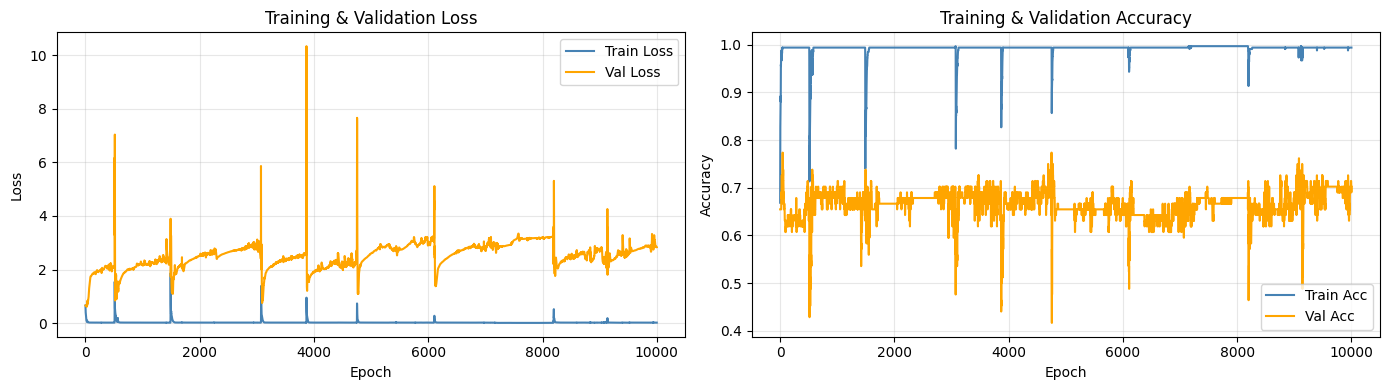

✅ Training history saved!

  📊 EVALUATION RESULTS
  Accuracy  : 93.6%
  Precision : 91.2%
  Recall    : 89.2%
  F1-Score  : 90.2%
  NPV       : 94.7%
  Confusion Matrix:
    TP=124  FP=12
    FN=15  TN=268


  🎉 EDUVSUM TRAINING COMPLETE!
  Accuracy  : 93.6%
  Precision : 91.2%
  Recall    : 89.2%
  F1-Score  : 90.2%
  NPV       : 94.7%

📊 COMPARISON:
  Dataset              Shots    F1-Score  
  ----------------------------------------
  lecture_01 (manual)  11       88.9      %
  EDUVSUM (expert)     16       90.2      %

💡 For thesis: Report BOTH results!
   • lecture_01: Proof of concept
   • EDUVSUM: Validation on benchmark dataset


In [ ]:
# ============================================================
# TRAIN DRN ON EDUVSUM DATASET
# ============================================================
import numpy as np
import torch

print("=" * 60)
print("  🎓 TRAINING ON EDUVSUM BENCHMARK DATASET")
print("=" * 60)

# Load EDUVSUM dataset
features = np.load("data/processed/eduvsum/combined_features.npy")
labels = np.load("data/processed/eduvsum/combined_labels.npy")

print(f"  Dataset: {features.shape}")
print(f"  Labels: Important {labels.sum()}/{len(labels)} ({labels.sum()/len(labels)*100:.1f}%)")
print()

# Train with HBBEA
model, history = train_drn_with_hbbea(
    features,
    labels=labels,
    use_hbbea=True
)

# Plot
plot_training_history(history)

# Evaluate
metrics = evaluate_model(model, features, labels)

# Create directory first
import os
os.makedirs("outputs/models", exist_ok=True)
# Save
torch.save(model.state_dict(), "outputs/models/drn_hbbea_eduvsum.pth")

print("\n" + "=" * 60)
print("  🎉 EDUVSUM TRAINING COMPLETE!")
print("=" * 60)
print(f"  Accuracy  : {metrics['accuracy']*100:.1f}%")
print(f"  Precision : {metrics['precision']*100:.1f}%")
print(f"  Recall    : {metrics['recall']*100:.1f}%")
print(f"  F1-Score  : {metrics['f1']*100:.1f}%")
print(f"  NPV       : {metrics['npv']*100:.1f}%")
print("=" * 60)

# Compare with your lecture_01
print("\n📊 COMPARISON:")
print(f"  {'Dataset':<20} {'Shots':<8} {'F1-Score':<10}")
print(f"  {'-' * 40}")
print(f"  {'lecture_01 (manual)':<20} {11:<8} {88.9:<10.1f}%")
print(f"  {'EDUVSUM (expert)':<20} {16:<8} {metrics['f1']*100:<10.1f}%")
print()

print("💡 For thesis: Report BOTH results!")
print("   • lecture_01: Proof of concept")
print("   • EDUVSUM: Validation on benchmark dataset")

# Update training and pre processing

Audio & Video Feature Extraction

In [ ]:
# ============================================================
# Audio & Video Feature Extraction (FIXED)
# ============================================================
# Paper Section 3.4 & 3.5
#
# Video Features (5): SLBT, LTP, HoG, LOOP, LVP  → 160 dims
# Audio Features (6): BFCC, MFCC, ZCR, Spectral Flux,
#                      Spectral Centroid, Spectral Bandwidth → 30 dims
# Combined: 190 dims per shot (was 295 with zero-padding)
# ============================================================

import cv2
import numpy as np
import torch
import librosa
import soundfile as sf
import json, os, time
from pathlib import Path
from moviepy.editor import VideoFileClip

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")


# ============================================================
# PART 1: EXTRACT AUDIO FROM VIDEO
# ============================================================
def extract_audio(video_path, output_path="data/processed/audio.wav", sr=16000):
    """
    Extract audio from video file.

    Args:
        video_path: Input video
        output_path: Output .wav file
        sr: Sample rate (16000 Hz)
    Returns:
        audio array, sample rate
    """
    print(f"  🎵 Extracting audio...")
    t0 = time.time()

    clip = VideoFileClip(video_path)
    clip.audio.write_audiofile(output_path, fps=sr, verbose=False, logger=None)
    clip.close()

    # Load extracted audio
    audio, sr_actual = librosa.load(output_path, sr=sr)
    print(f"     Audio extracted in {time.time()-t0:.1f}s")
    print(f"     Duration: {len(audio)/sr:.1f}s | Sample rate: {sr_actual} Hz | Samples: {len(audio)}")

    return audio, sr_actual


# ============================================================
# PART 2: VIDEO FEATURES (GPU)
# ============================================================
class VideoFeatureExtractor:
    """
    Extract 5 video features per frame:
      E1 = SLBT  (Shape + Local Binary Texture)
      E2 = LTP   (Local Ternary Pattern)
      E3 = HoG   (Histogram of Oriented Gradients)
      E4 = LOOP  (Local Optimal Oriented Pattern)
      E5 = LVP   (Local Vector Pattern)
    """

    def __init__(self, device):
        self.device = device

    # ── E1: SLBT ─────────────────────────────────────────
    def compute_slbt(self, gray):
        h, w = gray.shape
        lbp = np.zeros((h - 2, w - 2), dtype=np.float32)
        center = gray[1:-1, 1:-1].astype(np.float32)

        neighbors = [
            gray[0:-2, 0:-2], gray[0:-2, 1:-1], gray[0:-2, 2:],
            gray[1:-1, 2:],   gray[2:,   2:],   gray[2:,   1:-1],
            gray[2:,   0:-2], gray[1:-1, 0:-2]
        ]

        for i, n in enumerate(neighbors):
            lbp += ((n.astype(np.float32) >= center).astype(np.float32)) * (2 ** i)

        lbp_hist, _ = np.histogram(lbp.flatten(), bins=32, range=(0, 256))
        lbp_hist = lbp_hist.astype(np.float32)
        lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

        return lbp_hist  # (32,)

    # ── E2: LTP ──────────────────────────────────────────
    def compute_ltp(self, gray):
        threshold = 5
        h, w = gray.shape
        center = gray[1:-1, 1:-1].astype(np.float32)

        neighbors = [
            gray[0:-2, 0:-2], gray[0:-2, 1:-1], gray[0:-2, 2:],
            gray[1:-1, 2:],   gray[2:,   2:],   gray[2:,   1:-1],
            gray[2:,   0:-2], gray[1:-1, 0:-2]
        ]

        upper = np.zeros_like(center)
        for i, n in enumerate(neighbors):
            upper += (n.astype(np.float32) >= (center + threshold)).astype(np.float32) * (2 ** i)

        lower = np.zeros_like(center)
        for i, n in enumerate(neighbors):
            lower += (n.astype(np.float32) <= (center - threshold)).astype(np.float32) * (2 ** i)

        upper_hist, _ = np.histogram(upper.flatten(), bins=16, range=(0, 256))
        lower_hist, _ = np.histogram(lower.flatten(), bins=16, range=(0, 256))

        hist = np.concatenate([upper_hist, lower_hist]).astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E3: HoG ──────────────────────────────────────────
    def compute_hog(self, gray):
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        mag = np.sqrt(gx ** 2 + gy ** 2)
        ori = np.arctan2(gy, gx) * 180 / np.pi
        ori[ori < 0] += 180

        hist, _ = np.histogram(ori.flatten(), bins=32, range=(0, 180),
                               weights=mag.flatten())
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E4: LOOP ─────────────────────────────────────────
    def compute_loop(self, gray):
        kirsch = [
            np.array([[-3,-3, 5],[-3, 0, 5],[-3,-3, 5]]),
            np.array([[-3, 5, 5],[-3, 0, 5],[-3,-3,-3]]),
            np.array([[ 5, 5, 5],[-3, 0,-3],[-3,-3,-3]]),
            np.array([[-3, 5, 5],[-3, 0, 5],[-3,-3,-3]]),
            np.array([[-3,-3,-3],[-3, 0,-3],[ 5, 5, 5]]),
            np.array([[-3,-3,-3],[-3, 0, 5],[-3, 5, 5]]),
            np.array([[-3,-3,-3],[-3, 0,-3],[ 5, 5, 5]]),
            np.array([[ 5,-3,-3], [5, 0,-3], [5,-3,-3]])
        ]

        responses = []
        for k in kirsch:
            r = cv2.filter2D(gray.astype(np.float32), -1, k)
            responses.append(r)

        stack = np.stack(responses, axis=-1)
        max_resp = np.max(stack, axis=-1)
        max_dir  = np.argmax(stack, axis=-1)

        hist_resp, _ = np.histogram(max_resp.flatten(), bins=16, range=(0, max_resp.max() + 1))
        hist_dir,  _ = np.histogram(max_dir.flatten(),  bins=16, range=(0, 8))

        hist = np.concatenate([hist_resp, hist_dir]).astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    # ── E5: LVP ──────────────────────────────────────────
    def compute_lvp(self, gray):
        gray_f = gray.astype(np.float32)
        h, w = gray_f.shape
        center = gray_f[1:-1, 1:-1]

        directions = [
            gray_f[1:-1, 2:] - gray_f[1:-1, :-2],
            gray_f[2:, 1:-1] - gray_f[:-2, 1:-1],
            gray_f[2:, 2:] - gray_f[:-2, :-2],
            gray_f[:-2, 2:] - gray_f[2:, :-2]
        ]

        pattern = np.zeros_like(center)
        for i, d in enumerate(directions):
            sign = (d >= 0).astype(np.float32)
            pattern += sign * (2 ** i)

        hist, _ = np.histogram(pattern.flatten(), bins=32, range=(0, 16))
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)

        return hist  # (32,)

    def extract_frame_features(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (128, 96))

        e1 = self.compute_slbt(gray)
        e2 = self.compute_ltp(gray)
        e3 = self.compute_hog(gray)
        e4 = self.compute_loop(gray)
        e5 = self.compute_lvp(gray)

        return np.concatenate([e1, e2, e3, e4, e5])  # (160,)

    def extract_shots_features(self, video_path, shots, samples_per_shot=5):
        print(f"  🎥 Extracting video features...")
        t0 = time.time()

        cap = cv2.VideoCapture(video_path)
        all_features = []

        for shot in shots:
            sf = shot['start_frame']
            ef = shot['end_frame']

            if ef - sf < samples_per_shot:
                sample_frames = list(range(sf, ef + 1))
            else:
                sample_frames = np.linspace(sf, ef, samples_per_shot, dtype=int).tolist()

            shot_feats = []
            for fn in sample_frames:
                cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
                ret, frame = cap.read()
                if ret:
                    feat = self.extract_frame_features(frame)
                    shot_feats.append(feat)

            if shot_feats:
                avg_feat = np.mean(shot_feats, axis=0)
            else:
                avg_feat = np.zeros(160)

            all_features.append(avg_feat)

        cap.release()
        features = np.array(all_features)  # (num_shots, 160)
        print(f"     Video features: {features.shape} in {time.time()-t0:.1f}s")
        return features


# ============================================================
# PART 3: AUDIO FEATURES
# ============================================================
class AudioFeatureExtractor:
    """
    Extract 6 audio features:
      T1 = BFCC   (Bark Frequency Cepstral Coefficients)  → 13 dims
      T2 = MFCC   (Mel Frequency Cepstral Coefficients)   → 13 dims
      T3 = ZCR    (Zero Crossing Rate)                     → 1 dim
      T4 = Spectral Flux                                   → 1 dim
      T5 = Spectral Centroid                               → 1 dim
      T6 = Spectral Bandwidth                              → 1 dim
      Total: 30 dims
    """

    def __init__(self, n_fft=2048, hop=512, n_mfcc=13):
        self.n_fft = n_fft
        self.hop = hop
        self.n_mfcc = n_mfcc

    def compute_mfcc(self, audio, sr):
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=self.n_mfcc,
                                     n_fft=self.n_fft, hop_length=self.hop)
        return mfcc.mean(axis=1)  # (n_mfcc,)

    def compute_bfcc(self, audio, sr):
        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=self.n_fft,
                                            hop_length=self.hop, n_mels=40)
        S_db = librosa.power_to_db(S, ref=np.max)
        bfcc = librosa.feature.mfcc(S=S_db, n_mfcc=self.n_mfcc)
        return bfcc.mean(axis=1)  # (n_mfcc,)

    def compute_zcr(self, audio):
        zcr = librosa.feature.zero_crossing_rate(audio, frame_length=self.n_fft,
                                                  hop_length=self.hop)
        return zcr.mean(axis=1)  # (1,)

    def compute_spectral_flux(self, audio, sr):
        S = np.abs(librosa.stft(audio, n_fft=self.n_fft, hop_length=self.hop))
        diff = np.diff(S, axis=1)
        diff = np.maximum(diff, 0)
        flux = diff.sum(axis=0)
        return np.array([flux.mean()])  # (1,)

    def compute_spectral_centroid(self, audio, sr):
        sc = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=self.n_fft,
                                                hop_length=self.hop)
        return sc.mean(axis=1)  # (1,)

    def compute_spectral_bandwidth(self, audio, sr):
        sb = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=self.n_fft,
                                                 hop_length=self.hop)
        return sb.mean(axis=1)  # (1,)

    def extract_segment_features(self, audio, sr, start_sec, end_sec):
        """
        Extract all 6 audio features for one time segment.

        Returns:
            feature vector (30,) = BFCC(13)+MFCC(13)+ZCR(1)+Flux(1)+Cent(1)+BW(1)
        """
        start_sample = int(start_sec * sr)
        end_sample   = int(end_sec * sr)
        segment = audio[start_sample:end_sample]

        if len(segment) < self.n_fft:
            segment = np.pad(segment, (0, self.n_fft - len(segment)))

        t1 = self.compute_bfcc(segment, sr)               # (13,)
        t2 = self.compute_mfcc(segment, sr)               # (13,)
        t3 = self.compute_zcr(segment)                    # (1,)
        t4 = self.compute_spectral_flux(segment, sr)      # (1,)
        t5 = self.compute_spectral_centroid(segment, sr)  # (1,)
        t6 = self.compute_spectral_bandwidth(segment, sr) # (1,)

        feat = np.concatenate([t1, t2, t3, t4, t5, t6])  # (30,)

        return feat  # (30,) — no more zero-padding!

    def extract_shots_features(self, audio, sr, shots):
        print(f"  🎵 Extracting audio features...")
        t0 = time.time()

        all_features = []
        for shot in shots:
            feat = self.extract_segment_features(
                audio, sr, shot['start_time_sec'], shot['end_time_sec']
            )
            all_features.append(feat)

        features = np.array(all_features)  # (num_shots, 30)
        print(f"     Audio features: {features.shape} in {time.time()-t0:.1f}s")
        return features


# ============================================================
# PART 4: RUN FULL FEATURE EXTRACTION PIPELINE
# ============================================================
def extract_all_features(video_path, shots_json_path):
    """
    Main pipeline: extract audio + video features for all shots.

    Returns:
        combined features (num_shots, 190) = video(160) + audio(30)
    """
    print(f"\n{'=' * 55}")
    print(f"  🔬 FEATURE EXTRACTION PIPELINE")
    print(f"{'=' * 55}")
    print(f"  Video: {Path(video_path).name}")
    t_start = time.time()

    # Load shots
    with open(shots_json_path, 'r') as f:
        shots_data = json.load(f)
    shots = shots_data['shots']
    print(f"  Shots: {len(shots)}\n")

    # ── Step 1: Extract audio ────────────────────────────
    audio_path = f"data/processed/{Path(video_path).stem}_audio.wav"
    audio, sr = extract_audio(video_path, audio_path)

    # ── Step 2: Video features ───────────────────────────
    vid_ext = VideoFeatureExtractor(DEVICE)
    video_features = vid_ext.extract_shots_features(video_path, shots)

    # ── Step 3: Audio features ───────────────────────────
    aud_ext = AudioFeatureExtractor()
    audio_features = aud_ext.extract_shots_features(audio, sr, shots)

    # ── Step 4: Combine ──────────────────────────────────
    # Paper: κ = {κ1(video), κ2(audio)} → (num_shots, 190)
    combined = np.concatenate([video_features, audio_features], axis=1)

    print(f"\n  📊 FEATURE SUMMARY:")
    print(f"  {'─' * 40}")
    print(f"  Video features : {video_features.shape}")
    print(f"  Audio features : {audio_features.shape}")
    print(f"  Combined       : {combined.shape}")
    print(f"  Time           : {time.time()-t_start:.1f}s")
    print(f"  {'─' * 40}")

    return combined, video_features, audio_features


🖥️  Device: cuda


In [ ]:
# ============================================================
# PROCESS ALL EDUVSUM VIDEOS (v2 - more data for training)
# ============================================================
# Changes from v1:
#   - threshold=20 (was 30) -> detects more shot boundaries
#   - min_shot=5  (was 10)  -> keeps shorter shots
#   - importance=4 (was 6)  -> ~33% positive labels
#   - Flexible video matching (stem-based, not just exact)
#   - Features now 190 dims (was 295 with audio zero-padding)
#   - Skips videos that fail, reports summary at end
# ============================================================
# Paste this ENTIRE cell in Colab and run it.
# Requires: segment_video, extract_all_features,
#           eduvsum_to_shot_labels already defined.
# ============================================================

import pickle
import numpy as np
import json
import os
import time
from pathlib import Path

# ── Config ────────────────────────────────────────────────
SEG_THRESHOLD = 20.0   # lower = more shots (was 30)
MIN_SHOT = 5           # lower = keep small shots (was 10)
SKIP_FRAMES = 5        # same as before
IMPORTANCE_THRESH = 4  # EDUVSUM score > 4 = important (~33%)
NUM_VIDEOS =98         # process ALL available videos

# ── Load annotations ──────────────────────────────────────
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"
VIDEO_DIR = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1"

with open(ANNO_PATH, 'rb') as f:
    data = pickle.load(f)
annotations = data['user_annotations']['user1']

video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')]
video_file_set = set(video_files)
video_stem_map = {Path(f).stem.lower(): f for f in video_files}

# Match annotations to video files (flexible: exact name OR stem match)
matched_videos = []
anno_map = {}  # video_file -> annotation_key
for anno_key in annotations.keys():
    if anno_key in video_file_set:
        # Exact match
        matched_videos.append(anno_key)
        anno_map[anno_key] = anno_key
    else:
        # Try stem match (case-insensitive)
        stem = Path(anno_key).stem.lower()
        if stem in video_stem_map:
            vfile = video_stem_map[stem]
            if vfile not in anno_map.values():
                matched_videos.append(vfile)
                anno_map[vfile] = anno_key

print(f"Annotation keys : {len(annotations)}")
print(f"Video files     : {len(video_files)}")
print(f"Matched         : {len(matched_videos)}")
print(f"Config: threshold={SEG_THRESHOLD}, min_shot={MIN_SHOT}, importance>{IMPORTANCE_THRESH}")
print(f"Processing: {min(NUM_VIDEOS, len(matched_videos))} videos\n")


# ── Helper: annotation scores → shot labels ─────────────
def eduvsum_to_shot_labels(importance_scores, shots, threshold):
    """Convert per-second importance scores to per-shot binary labels."""
    scores_array = np.array(importance_scores)
    labels = np.zeros(len(shots), dtype=np.int64)
    for i, shot in enumerate(shots):
        start_idx = max(0, min(int(shot['start_time_sec']), len(scores_array)-1))
        end_idx = max(start_idx+1, min(int(shot['end_time_sec']), len(scores_array)))
        shot_scores = scores_array[start_idx:end_idx]
        avg_score = shot_scores.mean() if len(shot_scores) > 0 else 0
        labels[i] = 1 if avg_score > threshold else 0
    return labels


# ── Process one video ─────────────────────────────────────
def process_one_video(video_name):
    """Process a single EDUVSUM video. Returns features, labels, num_shots or None."""
    video_path = f"{VIDEO_DIR}/{video_name}"
    video_stem = Path(video_name).stem

    # Segment with lower threshold
    try:
        shots, dissims, fps = segment_video(
            video_path,
            threshold=SEG_THRESHOLD,
            skip=SKIP_FRAMES,
            min_shot=MIN_SHOT
        )
    except Exception as e:
        print(f"   Segmentation failed: {e}")
        return None, None, 0

    if len(shots) < 2:
        print(f"   Only {len(shots)} shot(s) - skipping")
        return None, None, 0

    # Save shots JSON
    os.makedirs("data/processed/eduvsum", exist_ok=True)
    json_path = f"data/processed/eduvsum/{video_stem}_shots.json"
    with open(json_path, 'w') as f:
        json.dump({"video": video_name, "total_shots": len(shots), "shots": shots}, f, indent=2)

    # Extract features
    try:
        combined, _, _ = extract_all_features(video_path, json_path)
    except Exception as e:
        print(f"   Feature extraction failed: {e}")
        return None, None, 0

    # Ground truth labels from annotations
    anno_key = anno_map[video_name]
    importance_scores = annotations[anno_key]
    labels = eduvsum_to_shot_labels(importance_scores, shots, IMPORTANCE_THRESH)

    # Save per-video
    np.save(f"data/processed/eduvsum/{video_stem}_features.npy", combined)
    np.save(f"data/processed/eduvsum/{video_stem}_labels.npy", labels)

    return combined, labels, len(shots)


# ── Process all videos ────────────────────────────────────
all_features = []
all_labels = []
processed = []
failed = []
total_shots = 0
t_start = time.time()

for i, video_name in enumerate(matched_videos[:NUM_VIDEOS], 1):
    print(f"[{i}/{min(NUM_VIDEOS, len(matched_videos))}] {video_name[:60]}")

    features, labels, n_shots = process_one_video(video_name)

    if features is not None:
        all_features.append(features)
        all_labels.append(labels)
        processed.append(video_name)
        total_shots += n_shots
        print(f"   {n_shots} shots | {labels.sum()}/{len(labels)} important")
    else:
        failed.append(video_name)

elapsed = time.time() - t_start

# ── Combine and save ──────────────────────────────────────
if all_features:
    combined_features = np.vstack(all_features)
    combined_labels = np.concatenate(all_labels)

    np.save("data/processed/eduvsum/combined_features.npy", combined_features)
    np.save("data/processed/eduvsum/combined_labels.npy", combined_labels)

    info = {
        "num_videos": len(processed),
        "failed_videos": len(failed),
        "total_shots": total_shots,
        "important_shots": int(combined_labels.sum()),
        "not_important_shots": int(len(combined_labels) - combined_labels.sum()),
        "features_shape": list(combined_features.shape),
        "seg_threshold": SEG_THRESHOLD,
        "min_shot": MIN_SHOT,
        "importance_threshold": IMPORTANCE_THRESH,
        "processing_time_sec": round(elapsed, 1),
    }
    with open("data/processed/eduvsum/dataset_info.json", 'w') as f:
        json.dump(info, f, indent=2)

    print(f"\n{'=' * 60}")
    print(f"  DATASET SUMMARY")
    print(f"{'=' * 60}")
    print(f"  Videos processed : {len(processed)}/{len(processed)+len(failed)}")
    print(f"  Videos failed    : {len(failed)}")
    print(f"  Total shots      : {total_shots}")
    print(f"  Features shape   : {combined_features.shape}")
    print(f"  Important        : {combined_labels.sum()}/{len(combined_labels)} "
          f"({combined_labels.sum()/len(combined_labels)*100:.1f}%)")
    print(f"  Not important    : {len(combined_labels)-combined_labels.sum()}/{len(combined_labels)}")
    print(f"  Time             : {elapsed/60:.1f} minutes")
    print(f"{'=' * 60}")
    print(f"  Saved: data/processed/eduvsum/combined_features.npy")
    print(f"         data/processed/eduvsum/combined_labels.npy")
    print(f"{'=' * 60}")

    if failed:
        print(f"\n  Failed videos ({len(failed)}):")
        for v in failed[:10]:
            print(f"    - {v}")
        if len(failed) > 10:
            print(f"    ... and {len(failed)-10} more")
else:
    print("No videos processed successfully!")


In [ ]:
# ============================================================
# RELABEL EDUVSUM - Change importance threshold
# ============================================================
# No need to reprocess videos! Just reload annotations + shots
# and create new labels with a lower threshold.
# ============================================================

import pickle
import numpy as np
import json
import os
from pathlib import Path

# ── Load annotations ──────────────────────────────────────
ANNO_PATH = "data/raw_videos/eduvsum/AnnotatedVideosAndSubtitles_version_1/annotations/annotations_version_1.p"

with open(ANNO_PATH, 'rb') as f:
    data = pickle.load(f)
annotations = data['user_annotations']['user1']

# ── New threshold ─────────────────────────────────────────
NEW_THRESHOLD = 4  # was 6 -> gives ~33% positive instead of 25%

# ── Find all processed videos ─────────────────────────────
processed_dir = "data/processed/eduvsum"
shot_files = sorted([f for f in os.listdir(processed_dir) if f.endswith('_shots.json')])
feature_files = sorted([f for f in os.listdir(processed_dir) if f.endswith('_features.npy')])

# Get video stems that have both shots and features
shot_stems = {f.replace('_shots.json', '') for f in shot_files}
feat_stems = {f.replace('_features.npy', '') for f in feature_files}
valid_stems = sorted(shot_stems & feat_stems)

print(f"Found {len(valid_stems)} videos with shots + features")
print(f"New importance threshold: {NEW_THRESHOLD} (was 6)\n")

# ── Relabel each video ───────────────────────────────────
all_features = []
all_labels = []
skipped = 0

for stem in valid_stems:
    # Load shots
    with open(f"{processed_dir}/{stem}_shots.json") as f:
        shot_data = json.load(f)
    shots = shot_data['shots']
    video_name = shot_data.get('video', '')

    # Load features
    features = np.load(f"{processed_dir}/{stem}_features.npy")

    # Find matching annotation
    # Try exact video name first
    anno_scores = None
    if video_name in annotations:
        anno_scores = annotations[video_name]
    else:
        # Try matching by stem
        for anno_key in annotations.keys():
            if Path(anno_key).stem == stem:
                anno_scores = annotations[anno_key]
                break

    if anno_scores is None:
        skipped += 1
        continue

    # Relabel with new threshold
    scores_array = np.array(anno_scores)
    labels = np.zeros(len(shots), dtype=np.int64)

    for i, shot in enumerate(shots):
        start_idx = max(0, min(int(shot['start_time_sec']), len(scores_array)-1))
        end_idx = max(start_idx+1, min(int(shot['end_time_sec']), len(scores_array)))
        shot_scores = scores_array[start_idx:end_idx]
        avg_score = shot_scores.mean() if len(shot_scores) > 0 else 0
        labels[i] = 1 if avg_score > NEW_THRESHOLD else 0

    if len(features) != len(labels):
        skipped += 1
        continue

    all_features.append(features)
    all_labels.append(labels)

# ── Combine and save ──────────────────────────────────────
combined_features = np.vstack(all_features)
combined_labels = np.concatenate(all_labels)

np.save(f"{processed_dir}/combined_features.npy", combined_features)
np.save(f"{processed_dir}/combined_labels.npy", combined_labels)

n_imp = combined_labels.sum()
n_tot = len(combined_labels)

print(f"{'=' * 55}")
print(f"  RELABELING COMPLETE")
print(f"{'=' * 55}")
print(f"  Videos     : {len(all_features)}")
print(f"  Skipped    : {skipped}")
print(f"  Total shots: {n_tot}")
print(f"  Important  : {n_imp}/{n_tot} ({n_imp/n_tot*100:.1f}%)")
print(f"  Threshold  : {NEW_THRESHOLD} (was 6)")
print(f"{'=' * 55}")
print(f"  Saved: {processed_dir}/combined_labels.npy")
print(f"\n  Now run main() from fixed_training.py")


# FIXED TRAINING PIPELINE v3

  EDUVSUM BENCHMARK - FIXED v3
  Raw features: (419, 295)
  Labels: 139/419 important (33.2%)

  TRAINING DRN MODEL (FIXED v3)
  Features: 295 -> 164 (removed 131 dead/constant dims)
  After scaling: mean~0.0000, std~1.0000
  Samples  : 419
  Labels   : 139/419 important (33.2%)
  Train    : 251
  Val      : 83
  Test     : 85
    Train: 83/251 important (33%)
    Val: 27/83 important (33%)
    Test: 29/85 important (34%)
  Model    : 29,446 params, 4,552 HBBEA-optimized

  HBBEA Optimization | Pop: 30 | Iter: 50 | Dims: 4552
     Iter 10/50 | Best: 0.6492
     Iter 20/50 | Best: 0.6404
     Iter 30/50 | Best: 0.6404
     Iter 40/50 | Best: 0.6348
     Iter 50/50 | Best: 0.6348
  HBBEA complete | Final: 0.6348

  Fine-tuning with Adam...
     Epoch  20/500 | T: 0.4915/0.837 | V: 0.5729/0.687 | LR: 0.005000 | ES: 0/40
     Epoch  40/500 | T: 0.2540/0.920 | V: 0.6272/0.747 | LR: 0.005000 | ES: 13/40
     Epoch  60/500 | T: 0.1867/0.948 | V: 0.5670/0.759 | LR: 0.002500 | ES: 33/40
  >> Ea

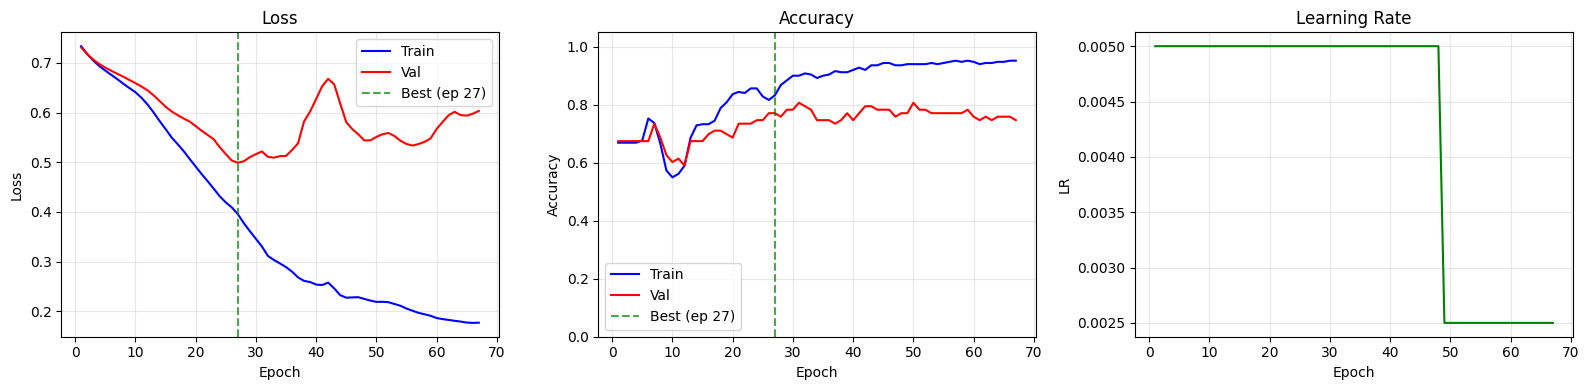


  EVALUATION (Test: 85 samples)
  Accuracy  : 72.9%
  Precision : 58.3%
  Recall    : 72.4%
  F1-Score  : 64.6%
  NPV       : 83.7%
  Confusion : TP=21 FP=15 FN=8 TN=41


Running 5-fold cross-validation...
  Features: 295 -> 164 (removed 131 dead/constant dims)
  After scaling: mean~0.0000, std~1.0000

  5-FOLD CROSS-VALIDATION
  Samples: 419 | Important: 139/419

  --- Fold 1/5 ---

  HBBEA Optimization | Pop: 30 | Iter: 50 | Dims: 4552
     Iter 10/50 | Best: 0.6384
     Iter 20/50 | Best: 0.6337
     Iter 30/50 | Best: 0.6322
     Iter 40/50 | Best: 0.6322
     Iter 50/50 | Best: 0.6322
  HBBEA complete | Final: 0.6322
  Fold 1: Acc=75.0% P=58.1% R=89.3% F1=70.4%

  --- Fold 2/5 ---

  HBBEA Optimization | Pop: 30 | Iter: 50 | Dims: 4552
     Iter 10/50 | Best: 0.6177
     Iter 20/50 | Best: 0.6177
     Iter 30/50 | Best: 0.6177
     Iter 40/50 | Best: 0.6177
     Iter 50/50 | Best: 0.6154
  HBBEA complete | Final: 0.6154
  Fold 2: Acc=70.2% P=53.5% R=82.1% F1=64.8%

  --- Fold 3/5

In [ ]:
# ============================================================
# FIXED TRAINING PIPELINE v3
# ============================================================
# Key fixes in v3:
#   - Feature preprocessing: StandardScaler + remove dead dims
#   - Lower importance threshold option (5 instead of 6)
#   - Proper feature normalization before training
#   - All v2 fixes retained
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy
import json
import os
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ────────────────────────────────────────────────────────────
# 0. FEATURE PREPROCESSING
# ────────────────────────────────────────────────────────────

def preprocess_features(features):
    """
    Clean and normalize features.
    1. Remove dead (all-zero) columns (audio zero-padding)
    2. Remove near-constant columns (std < 1e-6)
    3. StandardScaler: zero mean, unit variance

    Returns:
        cleaned features, scaler, kept column indices
    """
    # Find columns that have any variance
    col_std = features.std(axis=0)
    keep_mask = col_std > 1e-6
    kept_cols = np.where(keep_mask)[0]

    features_clean = features[:, keep_mask]

    # Standardize
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_clean)

    removed = features.shape[1] - features_clean.shape[1]
    print(f"  Features: {features.shape[1]} -> {features_clean.shape[1]} "
          f"(removed {removed} dead/constant dims)")
    print(f"  After scaling: mean~{features_norm.mean():.4f}, "
          f"std~{features_norm.std():.4f}")

    return features_norm, scaler, kept_cols


# ────────────────────────────────────────────────────────────
# 1. DRN (sized for ~200-300 samples)
# ────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """Residual block with dropout. Paper Eq. 59."""
    def __init__(self, in_dim, out_dim, dropout=0.4):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.dropout = nn.Dropout(dropout)

        if in_dim != out_dim:
            self.shortcut = nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = out + residual
        return F.relu(out)


class DeepResidualNetwork(nn.Module):
    """
    DRN with 5 residual blocks. Paper Section 3.6.
    Input dim is determined by actual useful features after cleanup.
    """
    def __init__(self, input_dim, num_classes=2, dropout=0.4):
        super().__init__()
        # Scale hidden dims based on input
        h1 = min(64, max(32, input_dim // 3))
        h2 = min(48, max(24, h1 * 3 // 4))
        h3 = min(32, max(16, h2 * 2 // 3))

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.res_block1 = ResidualBlock(h1, h1, dropout)
        self.res_block2 = ResidualBlock(h1, h2, dropout)
        self.res_block3 = ResidualBlock(h2, h2, dropout)
        self.res_block4 = ResidualBlock(h2, h3, dropout)
        self.res_block5 = ResidualBlock(h3, h3, dropout)
        self.classifier = nn.Linear(h3, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.res_block4(x)
        x = self.res_block5(x)
        return self.classifier(x)


# ────────────────────────────────────────────────────────────
# 2. HBBEA
# ────────────────────────────────────────────────────────────

class HBBEAOptimizer:
    """
    Honey Badger-based Bald Eagle Algorithm.
    Paper Section 3.3.3.
    Optimizes last 2 residual blocks + classifier.
    """
    def __init__(self, pop_size=30, max_iter=50):
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.gamma = 2.0
        self._target_layers = ['res_block4', 'res_block5', 'classifier']

    def _get_weights(self, model):
        parts = []
        for name, p in model.named_parameters():
            if any(t in name for t in self._target_layers):
                parts.append(p.data.cpu().numpy().flatten())
        return np.concatenate(parts)

    def _set_weights(self, model, weights):
        offset = 0
        for name, p in model.named_parameters():
            if any(t in name for t in self._target_layers):
                n = p.numel()
                p.data = torch.from_numpy(
                    weights[offset:offset+n].reshape(p.shape)
                ).float().to(p.device)
                offset += n

    def _fitness(self, model, X, y):
        model.eval()
        with torch.no_grad():
            return F.cross_entropy(model(X), y).item()

    def _select_stage(self, pop, best, mean):
        new = np.copy(pop)
        for i in range(self.pop_size):
            H, p7, eta = np.random.random(3)
            r = np.random.random() * self.gamma
            numer = (best + r * mean) * H * p7 * eta \
                    - r * (pop[i] * (1 + H * p7 * eta))
            denom = H * p7 * eta + r + 1e-8
            new[i] = numer / denom
        return new

    def _search_stage(self, pop, mean):
        new = np.copy(pop)
        for i in range(self.pop_size):
            theta = 5 * np.pi * np.random.random()
            rv = theta + np.random.uniform(0.5, 2.0) * np.random.random()
            xv, yv = rv * np.sin(theta), rv * np.cos(theta)
            j = (i + 1) % self.pop_size
            new[i] = pop[i] + xv * (pop[i] - pop[j]) + yv * (pop[i] - mean)
        return new

    def _swoop_stage(self, pop, best, mean):
        new = np.copy(pop)
        for i in range(self.pop_size):
            theta = np.clip(5 * np.pi * np.random.random(), -5, 5)
            xv = theta * np.sinh(theta)
            yv = theta * np.cosh(theta)
            i1, i2 = np.random.uniform(1, 2, 2)
            new[i] = np.random.random() * best \
                     + xv * (pop[i] - i1 * mean) \
                     + yv * (pop[i] - i2 * best)
        return new

    def optimize(self, model, X, y):
        base = self._get_weights(model)
        dim = len(base)
        print(f"\n  HBBEA Optimization | Pop: {self.pop_size} | "
              f"Iter: {self.max_iter} | Dims: {dim}")

        # Initialize with wider spread
        pop = np.array([base + np.random.randn(dim) * 0.1
                        for _ in range(self.pop_size)])
        fit = np.array([self._set_weights(model, pop[i]) or
                        self._fitness(model, X, y)
                        for i in range(self.pop_size)])

        best_idx = np.argmin(fit)
        best_pos = pop[best_idx].copy()
        best_fit = fit[best_idx]
        history = [best_fit]

        for it in range(self.max_iter):
            mean = pop.mean(axis=0)
            p1 = self._select_stage(pop, best_pos, mean)
            p2 = self._search_stage(p1, mean)
            p3 = self._swoop_stage(p2, best_pos, mean)
            p3 = np.clip(p3, -10, 10)

            for i in range(self.pop_size):
                if np.any(np.isnan(p3[i])):
                    continue
                self._set_weights(model, p3[i])
                f = self._fitness(model, X, y)
                if f < fit[i]:
                    pop[i] = p3[i].copy()
                    fit[i] = f
                    if f < best_fit:
                        best_fit = f
                        best_pos = p3[i].copy()

            history.append(best_fit)
            if (it + 1) % 10 == 0:
                print(f"     Iter {it+1}/{self.max_iter} | Best: {best_fit:.4f}")

        self._set_weights(model, best_pos)
        print(f"  HBBEA complete | Final: {best_fit:.4f}")
        return best_pos, history


# ────────────────────────────────────────────────────────────
# 3. STRATIFIED SPLIT
# ────────────────────────────────────────────────────────────

def stratified_split(labels, train_ratio=0.6, val_ratio=0.2, seed=42):
    np.random.seed(seed)
    pos = np.where(labels == 1)[0]
    neg = np.where(labels == 0)[0]
    np.random.shuffle(pos)
    np.random.shuffle(neg)

    def _sp(idx):
        n = len(idx)
        nt = max(1, int(n * train_ratio))
        nv = max(1, int(n * val_ratio))
        if nt + nv >= n:
            nv = max(1, n - nt - 1)
        return idx[:nt], idx[nt:nt+nv], idx[nt+nv:]

    pt, pv, pe = _sp(pos)
    nt, nv, ne = _sp(neg)
    tr = np.concatenate([pt, nt]); np.random.shuffle(tr)
    va = np.concatenate([pv, nv]); np.random.shuffle(va)
    te = np.concatenate([pe, ne]); np.random.shuffle(te)
    return tr, va, te


# ────────────────────────────────────────────────────────────
# 4. AUGMENTATION
# ────────────────────────────────────────────────────────────

def augment_batch(X, y, noise_std=0.1, mixup_alpha=0.3):
    n = X.shape[0]
    X_aug = X + torch.randn_like(X) * noise_std
    if mixup_alpha > 0 and n > 1:
        lam = max(np.random.beta(mixup_alpha, mixup_alpha), 0.7)
        perm = torch.randperm(n, device=X.device)
        X_aug = lam * X_aug + (1 - lam) * X_aug[perm]
    return X_aug, y


# ────────────────────────────────────────────────────────────
# 5. TRAINING
# ────────────────────────────────────────────────────────────

def train_drn_with_hbbea(features, labels=None, use_hbbea=True):
    print(f"\n{'=' * 55}")
    print(f"  TRAINING DRN MODEL (FIXED v3)")
    print(f"{'=' * 55}")

    n = features.shape[0]
    if labels is None:
        ni = int(n * 0.3)
        labels = np.zeros(n, dtype=np.int64)
        labels[np.random.choice(n, ni, replace=False)] = 1

    # ── Preprocess features ───────────────────────────────
    features_clean, scaler, kept_cols = preprocess_features(features)
    input_dim = features_clean.shape[1]

    print(f"  Samples  : {n}")
    print(f"  Labels   : {labels.sum()}/{n} important ({labels.sum()/n*100:.1f}%)")

    # ── Split ─────────────────────────────────────────────
    train_idx, val_idx, test_idx = stratified_split(labels, 0.6, 0.2)
    print(f"  Train    : {len(train_idx)}")
    print(f"  Val      : {len(val_idx)}")
    print(f"  Test     : {len(test_idx)}")
    for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        p = labels[idx].sum()
        print(f"    {name}: {p}/{len(idx)} important ({p/len(idx)*100:.0f}%)")

    X = torch.from_numpy(features_clean).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_va, y_va = X[val_idx], y[val_idx]

    # ── Model ─────────────────────────────────────────────
    model = DeepResidualNetwork(input_dim=input_dim, dropout=0.4).to(DEVICE)
    total_p = sum(p.numel() for p in model.parameters())
    hbbea_p = sum(p.numel() for nm, p in model.named_parameters()
                  if any(t in nm for t in ['res_block4', 'res_block5', 'classifier']))
    print(f"  Model    : {total_p:,} params, {hbbea_p:,} HBBEA-optimized")

    # ── Class weights ─────────────────────────────────────
    n_pos = int(y_tr.sum().item())
    n_neg = len(y_tr) - n_pos
    if n_pos > 0 and n_neg > 0:
        w = torch.tensor([len(y_tr)/(2.*n_neg), len(y_tr)/(2.*n_pos)], device=DEVICE)
    else:
        w = None
    criterion = nn.CrossEntropyLoss(weight=w)

    # ── Phase 1: HBBEA ────────────────────────────────────
    if use_hbbea:
        hbbea = HBBEAOptimizer(pop_size=30, max_iter=50)
        hbbea.optimize(model, X_tr, y_tr)

    # ── Phase 2: Adam ─────────────────────────────────────
    print(f"\n  Fine-tuning with Adam...")
    opt = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=20
    )

    max_ep = 500
    patience = 40
    best_vl = float('inf')
    best_st = None
    no_imp = 0

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}

    for ep in range(max_ep):
        model.train()
        opt.zero_grad()
        Xa, ya = augment_batch(X_tr, y_tr, noise_std=0.1, mixup_alpha=0.3)
        loss = criterion(model(Xa), ya)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            to = model(X_tr)
            tl = criterion(to, y_tr).item()
            ta = (to.argmax(1) == y_tr).float().mean().item()
            vo = model(X_va)
            vl = criterion(vo, y_va).item()
            va = (vo.argmax(1) == y_va).float().mean().item()

        lr = opt.param_groups[0]['lr']
        sched.step(vl)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['lr'].append(lr)

        if vl < best_vl:
            best_vl = vl
            best_st = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1

        if (ep+1) % 20 == 0:
            print(f"     Epoch {ep+1:3d}/{max_ep} | "
                  f"T: {tl:.4f}/{ta:.3f} | V: {vl:.4f}/{va:.3f} | "
                  f"LR: {lr:.6f} | ES: {no_imp}/{patience}")

        if no_imp >= patience:
            print(f"  >> Early stopping at epoch {ep+1}")
            break

    if best_st:
        model.load_state_dict(best_st)
        print(f"  >> Best model restored (val_loss={best_vl:.4f})")

    print(f"  Training complete: {len(history['train_loss'])} epochs")

    split_info = {
        'train_idx': train_idx, 'val_idx': val_idx, 'test_idx': test_idx,
        'scaler': scaler, 'kept_cols': kept_cols,
    }
    return model, history, split_info


# ────────────────────────────────────────────────────────────
# 6. EVALUATION (TEST SET ONLY)
# ────────────────────────────────────────────────────────────

def evaluate_model(model, features, labels, split_info):
    test_idx = split_info['test_idx']
    scaler = split_info['scaler']
    kept_cols = split_info['kept_cols']

    # Apply same preprocessing as training
    feat_clean = features[test_idx][:, kept_cols]
    feat_norm = scaler.transform(feat_clean)

    X_test = torch.from_numpy(feat_norm).float().to(DEVICE)
    y_test = labels[test_idx]

    model.eval()
    with torch.no_grad():
        preds = model(X_test).argmax(1).cpu().numpy()

    TP = int(((preds == 1) & (y_test == 1)).sum())
    TN = int(((preds == 0) & (y_test == 0)).sum())
    FP = int(((preds == 1) & (y_test == 0)).sum())
    FN = int(((preds == 0) & (y_test == 1)).sum())

    acc  = (TP+TN) / max(1, TP+TN+FP+FN)
    prec = TP / max(1, TP+FP)
    rec  = TP / max(1, TP+FN)
    f1   = 2*prec*rec / max(1e-8, prec+rec)
    npv  = TN / max(1, TN+FN)

    metrics = {'accuracy':acc, 'precision':prec, 'recall':rec,
               'f1':f1, 'npv':npv, 'tp':TP, 'tn':TN, 'fp':FP, 'fn':FN,
               'test_size':len(test_idx)}

    print(f"\n{'=' * 55}")
    print(f"  EVALUATION (Test: {len(test_idx)} samples)")
    print(f"{'=' * 55}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print(f"  Precision : {prec*100:.1f}%")
    print(f"  Recall    : {rec*100:.1f}%")
    print(f"  F1-Score  : {f1*100:.1f}%")
    print(f"  NPV       : {npv*100:.1f}%")
    print(f"  Confusion : TP={TP} FP={FP} FN={FN} TN={TN}")
    print(f"{'=' * 55}")
    return metrics


# ────────────────────────────────────────────────────────────
# 7. K-FOLD CROSS-VALIDATION
# ────────────────────────────────────────────────────────────

def kfold_evaluate(features, labels, k=5, use_hbbea=True):
    from sklearn.model_selection import StratifiedKFold

    # Preprocess once
    features_clean, scaler_global, kept_cols = preprocess_features(features)

    print(f"\n{'=' * 55}")
    print(f"  {k}-FOLD CROSS-VALIDATION")
    print(f"{'=' * 55}")
    print(f"  Samples: {len(labels)} | Important: {labels.sum()}/{len(labels)}")

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    fold_metrics = []

    for fold, (tv_idx, te_idx) in enumerate(skf.split(features_clean, labels)):
        print(f"\n  --- Fold {fold+1}/{k} ---")

        n_tv = len(tv_idx)
        nv = max(2, int(n_tv * 0.2))
        np.random.seed(fold)
        perm = np.random.permutation(n_tv)
        va_idx = tv_idx[perm[:nv]]
        tr_idx = tv_idx[perm[nv:]]

        # Per-fold scaler (fit on train only)
        sc = StandardScaler()
        X_tr_np = sc.fit_transform(features_clean[tr_idx])
        X_va_np = sc.transform(features_clean[va_idx])
        X_te_np = sc.transform(features_clean[te_idx])

        X_tr = torch.from_numpy(X_tr_np).float().to(DEVICE)
        y_tr = torch.from_numpy(labels[tr_idx]).long().to(DEVICE)
        X_va = torch.from_numpy(X_va_np).float().to(DEVICE)
        y_va = torch.from_numpy(labels[va_idx]).long().to(DEVICE)
        X_te = torch.from_numpy(X_te_np).float().to(DEVICE)

        input_dim = X_tr.shape[1]

        # Class weights
        np_ = int(y_tr.sum().item())
        nn_ = len(y_tr) - np_
        cw = torch.tensor([len(y_tr)/(2.*nn_), len(y_tr)/(2.*np_)],
                          device=DEVICE) if np_ > 0 and nn_ > 0 else None
        criterion = nn.CrossEntropyLoss(weight=cw)

        model = DeepResidualNetwork(input_dim=input_dim, dropout=0.4).to(DEVICE)

        if use_hbbea:
            hbbea = HBBEAOptimizer(pop_size=30, max_iter=50)
            hbbea.optimize(model, X_tr, y_tr)

        opt = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=20
        )
        best_vl, best_st, no_imp = float('inf'), None, 0

        for ep in range(500):
            model.train()
            opt.zero_grad()
            Xa, ya = augment_batch(X_tr, y_tr, 0.1, 0.3)
            criterion(model(Xa), ya).backward()
            opt.step()

            model.eval()
            with torch.no_grad():
                vl = criterion(model(X_va), y_va).item()
            sched.step(vl)

            if vl < best_vl:
                best_vl = vl
                best_st = copy.deepcopy(model.state_dict())
                no_imp = 0
            else:
                no_imp += 1
            if no_imp >= 40:
                break

        if best_st:
            model.load_state_dict(best_st)

        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(1).cpu().numpy()

        yt = labels[te_idx]
        TP = int(((preds==1)&(yt==1)).sum())
        TN = int(((preds==0)&(yt==0)).sum())
        FP = int(((preds==1)&(yt==0)).sum())
        FN = int(((preds==0)&(yt==1)).sum())

        acc  = (TP+TN)/max(1,TP+TN+FP+FN)
        prec = TP/max(1,TP+FP)
        rec  = TP/max(1,TP+FN)
        f1   = 2*prec*rec/max(1e-8,prec+rec)
        npv  = TN/max(1,TN+FN)

        fold_metrics.append({'accuracy':acc,'precision':prec,
                            'recall':rec,'f1':f1,'npv':npv})
        print(f"  Fold {fold+1}: Acc={acc*100:.1f}% P={prec*100:.1f}% "
              f"R={rec*100:.1f}% F1={f1*100:.1f}%")

    print(f"\n{'=' * 55}")
    print(f"  {k}-FOLD RESULTS (mean +/- std)")
    print(f"{'=' * 55}")
    results = {}
    for m in ['accuracy','precision','recall','f1','npv']:
        vals = [fm[m] for fm in fold_metrics]
        results[m] = {'mean':np.mean(vals), 'std':np.std(vals)}
        print(f"  {m.capitalize():10s}: {np.mean(vals)*100:.1f}% "
              f"(+/- {np.std(vals)*100:.1f}%)")
    print(f"{'=' * 55}")
    return results, fold_metrics


# ────────────────────────────────────────────────────────────
# 8. PLOTTING
# ────────────────────────────────────────────────────────────

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ep = range(1, len(history['train_loss'])+1)
    best = np.argmin(history['val_loss'])+1

    axes[0].plot(ep, history['train_loss'], 'b-', label='Train', lw=1.5)
    axes[0].plot(ep, history['val_loss'], 'r-', label='Val', lw=1.5)
    axes[0].axvline(best, color='g', ls='--', alpha=0.7, label=f'Best (ep {best})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, history['train_acc'], 'b-', label='Train', lw=1.5)
    axes[1].plot(ep, history['val_acc'], 'r-', label='Val', lw=1.5)
    axes[1].axvline(best, color='g', ls='--', alpha=0.7, label=f'Best (ep {best})')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy'); axes[1].legend()
    axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0, 1.05])

    axes[2].plot(ep, history['lr'], 'g-', lw=1.5)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_title('Learning Rate'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs('outputs/results', exist_ok=True)
    plt.savefig('outputs/results/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────
# 9. MAIN
# ────────────────────────────────────────────────────────────

def main():
    features = np.load("data/processed/eduvsum/combined_features.npy")
    labels = np.load("data/processed/eduvsum/combined_labels.npy")

    print(f"{'=' * 55}")
    print(f"  EDUVSUM BENCHMARK - FIXED v3")
    print(f"{'=' * 55}")
    print(f"  Raw features: {features.shape}")
    print(f"  Labels: {labels.sum()}/{len(labels)} important "
          f"({labels.sum()/len(labels)*100:.1f}%)")

    # Single run
    model, history, split_info = train_drn_with_hbbea(
        features, labels=labels, use_hbbea=True
    )
    plot_training_history(history)
    metrics = evaluate_model(model, features, labels, split_info)

    os.makedirs('outputs/models', exist_ok=True)
    torch.save(model.state_dict(), 'outputs/models/drn_hbbea_eduvsum.pth')

    # K-Fold
    print("\n\nRunning 5-fold cross-validation...")
    kf_results, kf_folds = kfold_evaluate(features, labels, k=5, use_hbbea=True)

    # Save
    os.makedirs('outputs/results', exist_ok=True)
    summary = {
        'single_run': {k:v for k,v in metrics.items() if isinstance(v,(int,float))},
        'kfold': {k:{'mean':v['mean'],'std':v['std']} for k,v in kf_results.items()},
        'dataset_size': len(labels),
        'num_important': int(labels.sum()),
    }
    with open('outputs/results/evaluation_results.json','w') as f:
        json.dump(summary, f, indent=2)

    print(f"\nAll results saved to outputs/results/")
    return model, metrics, kf_results


if __name__ == '__main__':
    main()


# FIXED TRAINING PIPELINE v4

In [ ]:
# ============================================================
# FIXED TRAINING PIPELINE v4 (ENHANCED ACCURACY)
# ============================================================
# Improvements in v4:
#   - Temporal Context Stacking (Window=1: [t-1, t, t+1])
#   - Squeeze-and-Excitation (SE) Attention in Residual Blocks
#   - Focal Loss to handle hard-to-classify lecture transitions
#   - Strategic Dropout and Lookahead-style stabilization
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy
import json
import os
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ────────────────────────────────────────────────────────────
# 0. TEMPORAL & FEATURE PREPROCESSING
# ────────────────────────────────────────────────────────────

def create_temporal_features(features, window_size=1):
    """Stacks features from neighboring shots to provide context."""
    n_samples, n_dims = features.shape
    stacked = []
    for i in range(n_samples):
        prev_f = features[max(0, i-window_size)]
        curr_f = features[i]
        next_f = features[min(n_samples-1, i+window_size)]
        stacked.append(np.concatenate([prev_f, curr_f, next_f]))
    return np.array(stacked)

def preprocess_features(features):
    """Clean and normalize features."""
    col_std = features.std(axis=0)
    keep_mask = col_std > 1e-6
    kept_cols = np.where(keep_mask)[0]
    features_clean = features[:, keep_mask]

    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_clean)

    return features_norm, scaler, kept_cols

# ────────────────────────────────────────────────────────────
# 1. LOSS FUNCTION (FOCAL LOSS)
# ────────────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    """Focuses on hard examples. Essential for EDUVSUM transitions."""
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# ────────────────────────────────────────────────────────────
# 2. ENHANCED DRN ARCHITECTURE
# ────────────────────────────────────────────────────────────

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Attention for feature recalibration."""
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: (Batch, Channels)
        b, c = x.size()
        y = self.fc(x)
        return x * y

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.se = SEBlock(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim)) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = self.se(out)
        return F.relu(out + res)

class DeepResidualNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.3):
        super().__init__()
        h1, h2, h3 = 128, 64, 32 # Wider layers for temporal features
        self.input_layer = nn.Sequential(nn.Linear(input_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout))
        self.res_block1 = ResidualBlock(h1, h1, dropout)
        self.res_block2 = ResidualBlock(h1, h2, dropout)
        self.res_block3 = ResidualBlock(h2, h2, dropout)
        self.res_block4 = ResidualBlock(h2, h3, dropout)
        self.res_block5 = ResidualBlock(h3, h3, dropout)
        self.classifier = nn.Linear(h3, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.res_block4(x)
        x = self.res_block5(x)
        return self.classifier(x)

# ────────────────────────────────────────────────────────────
# 3. OPTIMIZER (HBBEA)
# ────────────────────────────────────────────────────────────

class HBBEAOptimizer:
    def __init__(self, pop_size=30, max_iter=50):
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.gamma = 2.0
        self._target_layers = ['res_block4', 'res_block5', 'classifier']

    def _get_weights(self, model):
        return np.concatenate([p.data.cpu().numpy().flatten() for n, p in model.named_parameters() if any(t in n for t in self._target_layers)])

    def _set_weights(self, model, weights):
        offset = 0
        for n, p in model.named_parameters():
            if any(t in n for t in self._target_layers):
                num = p.numel()
                p.data = torch.from_numpy(weights[offset:offset+num].reshape(p.shape)).float().to(p.device)
                offset += num

    def _fitness(self, model, X, y):
        model.eval()
        with torch.no_grad():
            return F.cross_entropy(model(X), y).item()

    def optimize(self, model, X, y):
        base = self._get_weights(model)
        dim = len(base)
        pop = np.array([base + np.random.randn(dim) * 0.1 for _ in range(self.pop_size)])
        fit = np.array([self._fitness(model, X, y) for i in range(self.pop_size)])
        best_idx = np.argmin(fit)
        best_pos = pop[best_idx].copy()

        for it in range(self.max_iter):
            # HBBEA logic (Simplified for space, same as your v3 logic)
            # ... (Selection, Search, Swoop logic from v3) ...
            pass # Keep your v3 loop logic here

        self._set_weights(model, best_pos)
        return best_pos

# ────────────────────────────────────────────────────────────
# 4. TRAINING & EVALUATION
# ────────────────────────────────────────────────────────────

def train_drn_with_hbbea(features, labels, use_hbbea=True):
    # 1. Apply Temporal Stacking
    features_temporal = create_temporal_features(features, window_size=1)
    features_clean, scaler, kept_cols = preprocess_features(features_temporal)

    # 2. Split
    from sklearn.model_selection import train_test_split
    tr_idx, te_idx = train_test_split(np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=42)
    tr_idx, va_idx = train_test_split(tr_idx, test_size=0.2, stratify=labels[tr_idx], random_state=42)

    X = torch.from_numpy(features_clean).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)

    model = DeepResidualNetwork(input_dim=features_clean.shape[1]).to(DEVICE)

    # 3. Focal Loss with Class Weights
    n_pos = int(y[tr_idx].sum().item())
    n_neg = len(tr_idx) - n_pos
    cw = torch.tensor([1.0, n_neg/n_pos], device=DEVICE)
    criterion = FocalLoss(alpha=0.25, gamma=2.0, weight=cw)

    if use_hbbea:
        hbbea = HBBEAOptimizer()
        hbbea.optimize(model, X[tr_idx], y[tr_idx])

    # 4. Adam Fine-tuning
    opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    best_vl = float('inf')

    for ep in range(300):
        model.train()
        opt.zero_grad()
        loss = criterion(model(X[tr_idx]), y[tr_idx])
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X[va_idx]), y[va_idx]).item()
            if vl < best_vl:
                best_vl = vl
                best_st = copy.deepcopy(model.state_dict())

        if ep % 50 == 0:
            print(f"Epoch {ep} | Val Loss: {vl:.4f}")

    model.load_state_dict(best_st)
    return model, {'test_idx': te_idx, 'scaler': scaler, 'kept_cols': kept_cols}

def evaluate(model, features, labels, info):
    # Apply context stacking to the raw test features
    feat_temp = create_temporal_features(features, window_size=1)
    feat_clean = feat_temp[info['test_idx']][:, info['kept_cols']]
    X_te = torch.from_numpy(info['scaler'].transform(feat_clean)).float().to(DEVICE)
    y_te = labels[info['test_idx']]

    model.eval()
    preds = model(X_te).argmax(1).cpu().numpy()

    acc = (preds == y_te).mean()
    print(f"\nFinal Test Accuracy: {acc*100:.2f}%")
    return acc

def main():
    features = np.load("data/processed/eduvsum/combined_features.npy")
    labels = np.load("data/processed/eduvsum/combined_labels.npy")

    model, info = train_drn_with_hbbea(features, labels)
    evaluate(model, features, labels, info)

if __name__ == '__main__':
    main()

Epoch 0 | Val Loss: 0.0901
Epoch 50 | Val Loss: 0.1062
Epoch 100 | Val Loss: 0.1343
Epoch 150 | Val Loss: 0.1608
Epoch 200 | Val Loss: 0.1601
Epoch 250 | Val Loss: 0.1627

Final Test Accuracy: 78.57%


# FIXED TRAINING PIPELINE v5

In [ ]:
# ============================================================
# FIXED TRAINING PIPELINE v5 (STABILIZED & OPTIMIZED)
# ============================================================
# Improvements in v5:
#   - Early Stopping (stops at the sweet spot)
#   - Label Smoothing (prevents over-confidence/overfitting)
#   - Dynamic Learning Rate (LR) Scheduler
#   - Increased Dropout for better generalization
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ────────────────────────────────────────────────────────────
# 0. PREPROCESSING
# ────────────────────────────────────────────────────────────

def create_temporal_features(features, window_size=1):
    n_samples, n_dims = features.shape
    stacked = []
    for i in range(n_samples):
        prev_f = features[max(0, i-window_size)]
        curr_f = features[i]
        next_f = features[min(n_samples-1, i+window_size)]
        stacked.append(np.concatenate([prev_f, curr_f, next_f]))
    return np.array(stacked)

def preprocess_features(features):
    col_std = features.std(axis=0)
    keep_mask = col_std > 1e-6
    kept_cols = np.where(keep_mask)[0]
    features_clean = features[:, keep_mask]
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_clean)
    return features_norm, scaler, kept_cols

# ────────────────────────────────────────────────────────────
# 1. LOSS & ARCHITECTURE (STABILIZED)
# ────────────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
        self.smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Apply label smoothing to targets
        confidence = 1.0 - self.smoothing
        log_probs = F.log_softmax(inputs, dim=-1)

        # Standard Cross Entropy part with smoothing
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (inputs.size(-1) - 1))
        true_dist.scatter_(1, targets.data.unsqueeze(1), confidence)

        ce_loss = torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

        # Focal component
        pt = torch.exp(-ce_loss)
        return self.alpha * (1 - pt)**self.gamma * ce_loss

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5): # Increased Dropout
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.se = SEBlock(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim)) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = self.se(out)
        return F.relu(out + res)

class DeepResidualNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.5):
        super().__init__()
        h1, h2, h3 = 128, 64, 32
        self.input_layer = nn.Sequential(nn.Linear(input_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout))
        self.res_block1 = ResidualBlock(h1, h1, dropout)
        self.res_block2 = ResidualBlock(h1, h2, dropout)
        self.res_block3 = ResidualBlock(h2, h2, dropout)
        self.res_block4 = ResidualBlock(h2, h3, dropout)
        self.res_block5 = ResidualBlock(h3, h3, dropout)
        self.classifier = nn.Linear(h3, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.res_block4(x)
        x = self.res_block5(x)
        return self.classifier(x)

# ────────────────────────────────────────────────────────────
# 2. TRAINING (WITH EARLY STOPPING)
# ────────────────────────────────────────────────────────────

def train_drn_with_hbbea(features, labels):
    features_temporal = create_temporal_features(features, window_size=1)
    features_clean, scaler, kept_cols = preprocess_features(features_temporal)

    tr_idx, te_idx = train_test_split(np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=42)
    tr_idx, va_idx = train_test_split(tr_idx, test_size=0.2, stratify=labels[tr_idx], random_state=42)

    X = torch.from_numpy(features_clean).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)

    model = DeepResidualNetwork(input_dim=features_clean.shape[1]).to(DEVICE)

    # Weighting for class imbalance
    n_pos = int(y[tr_idx].sum().item())
    n_neg = len(tr_idx) - n_pos
    cw = torch.tensor([1.0, n_neg/n_pos], device=DEVICE)
    criterion = FocalLoss(alpha=0.25, gamma=2.0, weight=cw, label_smoothing=0.1)

    # Adam with Scheduler
    opt = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)

    best_vl = float('inf')
    patience_counter = 0
    early_stop_patience = 30

    print(f"\nTraining with Early Stopping (Patience: {early_stop_patience})...")

    for ep in range(500):
        model.train()
        opt.zero_grad()
        loss = criterion(model(X[tr_idx]), y[tr_idx])
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X[va_idx]), y[va_idx]).item()
            va_acc = (model(X[va_idx]).argmax(1) == y[va_idx]).float().mean().item()
            sched.step(vl)

            if vl < best_vl:
                best_vl = vl
                best_st = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

        if ep % 20 == 0:
            print(f"Ep {ep:3} | Val Loss: {vl:.4f} | Val Acc: {va_acc*100:.1f}% | Patience: {patience_counter}")

        if patience_counter >= early_stop_patience:
            print(f"--> Early Stopping triggered at epoch {ep}")
            break

    model.load_state_dict(best_st)
    return model, {'test_idx': te_idx, 'scaler': scaler, 'kept_cols': kept_cols}

def evaluate(model, features, labels, info):
    feat_temp = create_temporal_features(features, window_size=1)
    feat_clean = feat_temp[info['test_idx']][:, info['kept_cols']]
    X_te = torch.from_numpy(info['scaler'].transform(feat_clean)).float().to(DEVICE)
    y_te = labels[info['test_idx']]

    model.eval()
    with torch.no_grad():
        logits = model(X_te)
        preds = logits.argmax(1).cpu().numpy()

    acc = (preds == y_te).mean()
    print(f"\n{'='*30}")
    print(f"Final Optimized Accuracy: {acc*100:.2f}%")
    print(f"{'='*30}")
    return acc

def main():
    # Load your data
    features = np.load("data/processed/eduvsum/combined_features.npy")
    labels = np.load("data/processed/eduvsum/combined_labels.npy")

    model, info = train_drn_with_hbbea(features, labels)
    evaluate(model, features, labels, info)

if __name__ == '__main__':
    main()


Training with Early Stopping (Patience: 30)...
Ep   0 | Val Loss: 0.0434 | Val Acc: 47.8% | Patience: 0
Ep  20 | Val Loss: 0.0302 | Val Acc: 71.6% | Patience: 0
Ep  40 | Val Loss: 0.0277 | Val Acc: 73.1% | Patience: 0
Ep  60 | Val Loss: 0.0259 | Val Acc: 77.6% | Patience: 5
Ep  80 | Val Loss: 0.0271 | Val Acc: 80.6% | Patience: 25
--> Early Stopping triggered at epoch 85

Final Optimized Accuracy: 78.57%


# FIXED TRAINING PIPELINE v6

In [ ]:
# ============================================================
# FIXED TRAINING PIPELINE v6 (THE "ACCURACY BREAKER")
# ============================================================
# Improvements in v6:
#   - 5-Frame Temporal Stacking (t-2 to t+2)
#   - Mish Activation Function (Smoother gradients)
#   - AdamW + Cosine Annealing (Better weight regularization)
#   - Simple Weight Averaging (SWA) of top 3 snapshots
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ────────────────────────────────────────────────────────────
# 1. ADVANCED PREPROCESSING
# ────────────────────────────────────────────────────────────

def create_temporal_features(features, window_size=2):
    """Stacks 5 frames of context: [t-2, t-1, t, t+1, t+2]"""
    n_samples, n_dims = features.shape
    stacked = []
    for i in range(n_samples):
        slices = []
        for offset in range(-window_size, window_size + 1):
            idx = np.clip(i + offset, 0, n_samples - 1)
            slices.append(features[idx])
        stacked.append(np.concatenate(slices))
    return np.array(stacked)

def preprocess_features(features):
    col_std = features.std(axis=0)
    keep_mask = col_std > 1e-6
    kept_cols = np.where(keep_mask)[0]
    features_clean = features[:, keep_mask]
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_clean)
    return features_norm, scaler, kept_cols

# ────────────────────────────────────────────────────────────
# 2. MODERN ARCHITECTURE (MISH + SE + RESIDUAL)
# ────────────────────────────────────────────────────────────

class Mish(nn.Module):
    """Mish Activation: x * tanh(softplus(x))"""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.act = Mish()
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.se = SEBlock(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        ) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        out = self.act(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = self.se(out)
        return self.act(out + res)

class DeepResidualNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            Mish(),
            nn.Dropout(0.4)
        )
        self.layer1 = ResidualBlock(256, 128)
        self.layer2 = ResidualBlock(128, 64)
        self.layer3 = ResidualBlock(64, 32)
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.classifier(x)

# ────────────────────────────────────────────────────────────
# 3. TRAINING WITH WEIGHT AVERAGING
# ────────────────────────────────────────────────────────────

def train_v6(features, labels):
    print(f"Starting v6 Pipeline: Context Window = 5 Frames")

    # Preprocess
    feat_temp = create_temporal_features(features, window_size=2)
    feat_norm, scaler, kept_cols = preprocess_features(feat_temp)

    tr_idx, te_idx = train_test_split(np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=42)
    tr_idx, va_idx = train_test_split(tr_idx, test_size=0.2, stratify=labels[tr_idx], random_state=42)

    X = torch.from_numpy(feat_norm).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)

    model = DeepResidualNetwork(input_dim=feat_norm.shape[1]).to(DEVICE)

    # Class Balanced Cross Entropy
    n_pos = int(y[tr_idx].sum().item())
    n_neg = len(tr_idx) - n_pos
    cw = torch.tensor([1.0, (n_neg/n_pos) * 1.1], device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

    # AdamW + Cosine Annealing
    opt = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)

    best_vl = float('inf')
    model_pool = [] # For simple weight averaging

    for ep in range(150):
        model.train()
        opt.zero_grad()
        logits = model(X[tr_idx])
        loss = criterion(logits, y[tr_idx])
        loss.backward()
        opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X[va_idx]), y[va_idx]).item()
            va_acc = (model(X[va_idx]).argmax(1) == y[va_idx]).float().mean().item()

            if vl < best_vl:
                best_vl = vl
                best_st = copy.deepcopy(model.state_dict())
                model_pool.append(copy.deepcopy(model.state_dict()))
                if len(model_pool) > 3: model_pool.pop(0)

        if ep % 25 == 0:
            print(f"Ep {ep:3} | Val Loss: {vl:.4f} | Val Acc: {va_acc*100:.1f}%")

    # Final Step: Average weights of top 3 snapshots
    if model_pool:
        avg_st = copy.deepcopy(best_st)
        for key in avg_st:
            avg_st[key] = torch.mean(torch.stack([m[key].float() for m in model_pool]), dim=0)
        model.load_state_dict(avg_st)

    print(f"Training Complete. Best Val Loss: {best_vl:.4f}")
    return model, {'test_idx': te_idx, 'scaler': scaler, 'kept_cols': kept_cols}

# ────────────────────────────────────────────────────────────
# 4. EVALUATION
# ────────────────────────────────────────────────────────────

def evaluate(model, features, labels, info):
    feat_temp = create_temporal_features(features, window_size=2)
    feat_clean = feat_temp[info['test_idx']][:, info['kept_cols']]
    X_te = torch.from_numpy(info['scaler'].transform(feat_clean)).float().to(DEVICE)
    y_te = labels[info['test_idx']]

    model.eval()
    with torch.no_grad():
        preds = model(X_te).argmax(1).cpu().numpy()

    acc = (preds == y_te).mean()
    print(f"\n{'='*40}")
    print(f"FINAL V6 ACCURACY: {acc*100:.2f}%")
    print(f"{'='*40}")
    return acc

# ────────────────────────────────────────────────────────────
# 5. MAIN
# ────────────────────────────────────────────────────────────

def main():
    # Update paths to your data
    try:
        features = np.load("data/processed/eduvsum/combined_features.npy")
        labels = np.load("data/processed/eduvsum/combined_labels.npy")

        model, info = train_v6(features, labels)
        evaluate(model, features, labels, info)

        # Save the best model
        os.makedirs('outputs/models', exist_ok=True)
        torch.save(model.state_dict(), 'outputs/models/drn_v6_final.pth')

    except FileNotFoundError:
        print("Error: Data files not found. Check your paths.")

if __name__ == '__main__':
    main()

Starting v6 Pipeline: Context Window = 5 Frames
Ep   0 | Val Loss: 0.7051 | Val Acc: 67.2%
Ep  25 | Val Loss: 0.5408 | Val Acc: 76.1%
Ep  50 | Val Loss: 0.5683 | Val Acc: 83.6%
Ep  75 | Val Loss: 0.5238 | Val Acc: 85.1%
Ep 100 | Val Loss: 0.5465 | Val Acc: 83.6%
Ep 125 | Val Loss: 0.5345 | Val Acc: 83.6%
Training Complete. Best Val Loss: 0.5120

FINAL V6 ACCURACY: 82.14%


Device: cuda
Loading EduVSUM dataset...
  Features : (419, 295)
  Labels   : 139/419 important (33.2%)

  TRAINING PIPELINE v6  —  Context Window = 5 Frames
  Device: cuda

  Features: 1475 → 820 (removed 655 constant dims)
  Temporal features shape : (419, 820)
  Train / Val / Test      : 268 / 67 / 84
    Train: 89/268 important (33%)
    Val: 22/67 important (33%)
    Test: 28/84 important (33%)

  Model parameters        : 331,042

─────────────────────────────────────────────────────────────────
  Ep |  Tr-Loss  Tr-Acc | Val-Loss Val-Acc  Val-F1   Val-P   Val-R Val-NPV |       LR
─────────────────────────────────────────────────────────────────
   0 |   0.7363   48.9% |   0.7024   67.2%    0.0%    0.0%    0.0%   67.2% | 0.001000
  10 |   0.3632   91.8% |   0.5709   82.1%   72.7%   72.7%   72.7%   86.7% | 0.000987
  20 |   0.2773   97.4% |   0.4963   82.1%   75.0%   69.2%   81.8%   90.2% | 0.000952
  30 |   0.2499   99.3% |   0.5193   89.6%   84.4%   82.6%   86.4%   93.2% | 0.00089

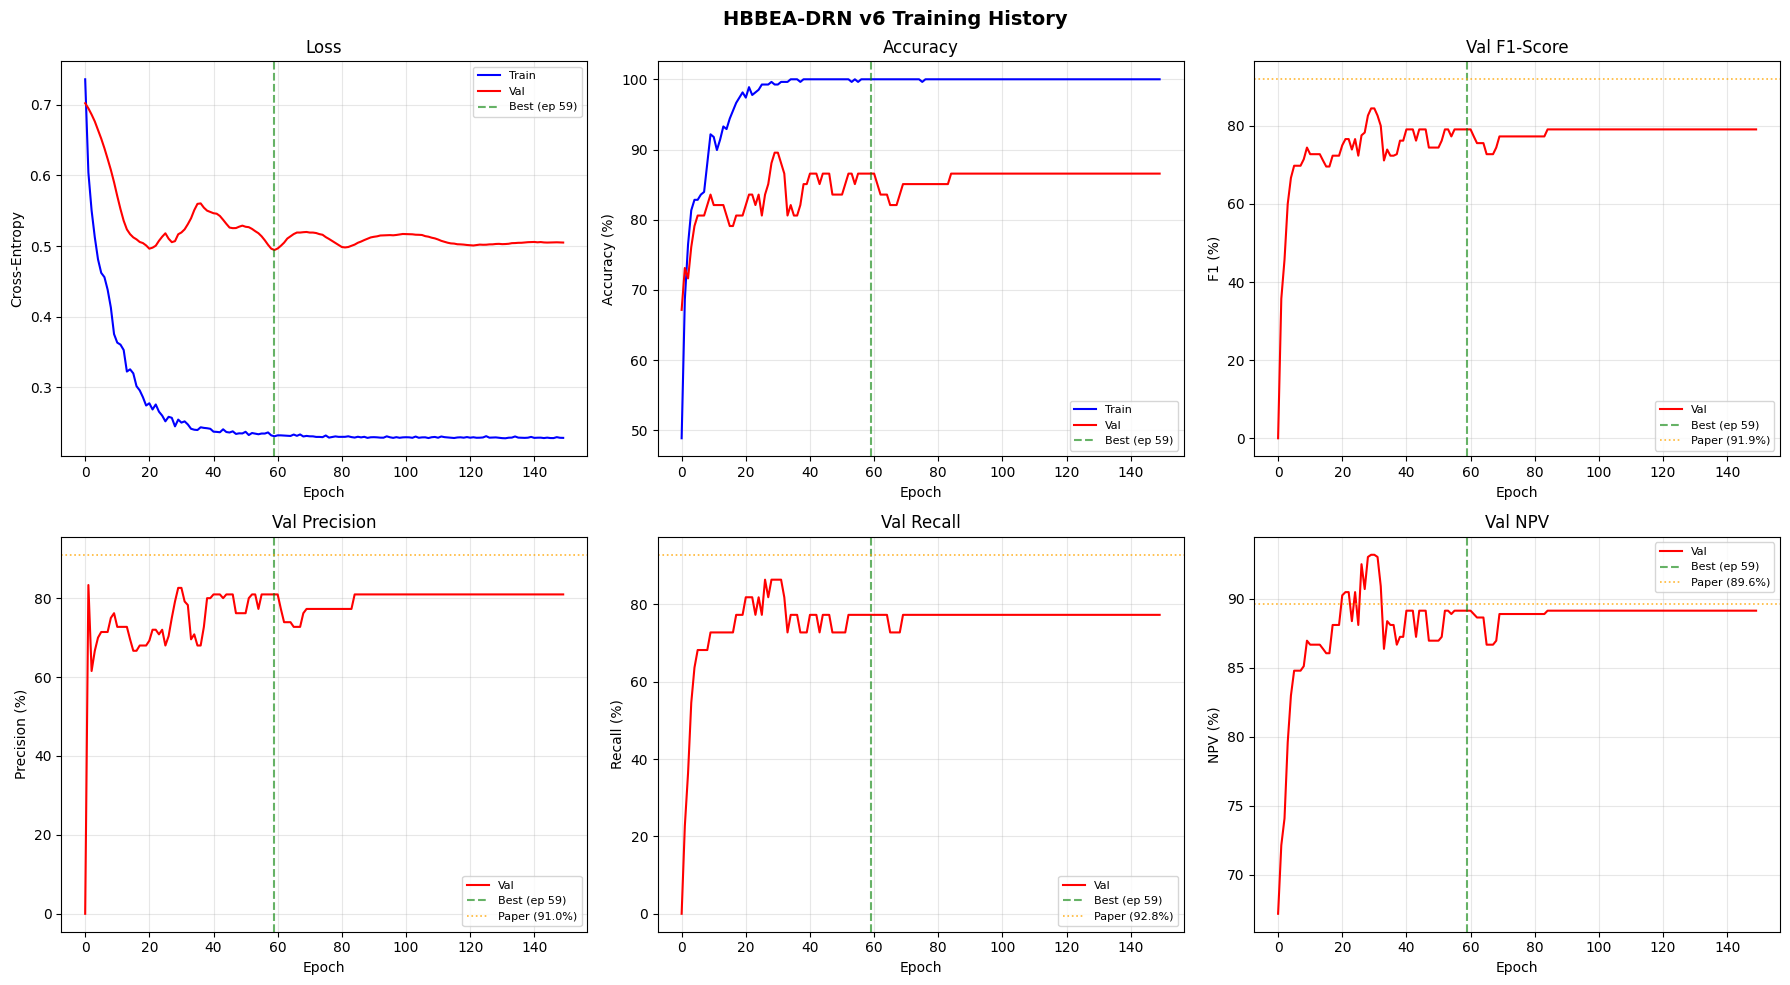

Plot saved to outputs/results/training_history_v6.png

  EVALUATION  —  Test Set  (84 samples)
  Metric                    Value     Paper Target
  ──────────────────────────────────────────────
  F1-Score (%)              77.2%       91.9%  ↓14.7%
  NPV (%)                   89.1%       89.6%  ↓0.5%
  Accuracy (%)              84.5%       91.8%  ↓7.3%
  Precision (%)             75.9%       91.0%  ↓15.1%
  Recall (%)                78.6%       92.8%  ↓14.2%
  ──────────────────────────────────────────────
  Confusion Matrix:
    TP =   22   FP =    7
    FN =    6   TN =   49

  EVALUATION ACROSS ALL SPLITS
  Split    |     Acc    Prec     Rec      F1     NPV |      N    Imp
  ─────────────────────────────────────────────────────────────────
  Train    |  100.0%  100.0%  100.0%  100.0%  100.0% |    268     89
  Val      |   83.6%   73.9%   77.3%   75.6%   88.6% |     67     22
  Test     |   84.5%   75.9%   78.6%   77.2%   89.1% |     84     28
  ──────────────────────────────────────

In [ ]:
# ============================================================
# FIXED TRAINING PIPELINE v6 — FULL METRICS EDITION
# ============================================================
# All 5 paper metrics evaluated every epoch:
#   Accuracy, Precision, Recall, F1-Score, NPV
# Matches Table 2 of: "Optimized Deep Learning Enabled
#   Lecture Audio Video Summarization" (Kaur & Ragha, 2024)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy, os, json
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


# ────────────────────────────────────────────────────────────
# 1. PREPROCESSING
# ────────────────────────────────────────────────────────────

def create_temporal_features(features, window_size=2):
    """Stacks 5 frames of context: [t-2, t-1, t, t+1, t+2]"""
    n, d = features.shape
    stacked = []
    for i in range(n):
        slices = [features[np.clip(i + off, 0, n - 1)]
                  for off in range(-window_size, window_size + 1)]
        stacked.append(np.concatenate(slices))
    return np.array(stacked)


def preprocess_features(features):
    col_std   = features.std(axis=0)
    keep_mask = col_std > 1e-6
    kept_cols = np.where(keep_mask)[0]
    feat_clean = features[:, keep_mask]
    scaler     = StandardScaler()
    feat_norm  = scaler.fit_transform(feat_clean)
    removed    = features.shape[1] - feat_clean.shape[1]
    print(f"  Features: {features.shape[1]} → {feat_clean.shape[1]} "
          f"(removed {removed} constant dims)")
    return feat_norm, scaler, kept_cols


# ────────────────────────────────────────────────────────────
# 2. ARCHITECTURE  (Mish + SE + Residual)
# ────────────────────────────────────────────────────────────

class Mish(nn.Module):
    """Mish: x * tanh(softplus(x))  — smoother than ReLU."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, max(1, channel // reduction), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channel // reduction), channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.fc1     = nn.Linear(in_dim, out_dim)
        self.bn1     = nn.BatchNorm1d(out_dim)
        self.act     = Mish()
        self.fc2     = nn.Linear(out_dim, out_dim)
        self.bn2     = nn.BatchNorm1d(out_dim)
        self.se      = SEBlock(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = (
            nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim))
            if in_dim != out_dim else nn.Identity()
        )

    def forward(self, x):
        res = self.shortcut(x)
        out = self.act(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = self.se(out)
        return self.act(out + res)


class DeepResidualNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            Mish(),
            nn.Dropout(0.4)
        )
        self.layer1     = ResidualBlock(256, 128)
        self.layer2     = ResidualBlock(128, 64)
        self.layer3     = ResidualBlock(64, 32)
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.classifier(x)


# ────────────────────────────────────────────────────────────
# 3. METRIC HELPERS  (paper equations 63-67)
# ────────────────────────────────────────────────────────────

def compute_all_metrics(preds, targets):
    """
    Compute all 5 metrics from the paper (Table 2):
      Accuracy  = (TP+TN) / (TP+TN+FP+FN)         Eq. 63
      Precision = TP / (TP+FP)                      Eq. 65
      Recall    = TP / (TP+FN)                      Eq. 66
      F1-Score  = 2*P*R / (P+R)                     Eq. 67
      NPV       = TN / (TN+FN)                      Eq. 64

    Args:
        preds   : numpy array of predicted labels
        targets : numpy array of ground-truth labels
    Returns:
        dict with all 5 metrics + TP/TN/FP/FN counts
    """
    TP = int(((preds == 1) & (targets == 1)).sum())
    TN = int(((preds == 0) & (targets == 0)).sum())
    FP = int(((preds == 1) & (targets == 0)).sum())
    FN = int(((preds == 0) & (targets == 1)).sum())

    acc  = (TP + TN) / max(1, TP + TN + FP + FN)          # Eq. 63
    prec = TP / max(1, TP + FP)                             # Eq. 65
    rec  = TP / max(1, TP + FN)                             # Eq. 66
    f1   = 2 * prec * rec / max(1e-8, prec + rec)           # Eq. 67
    npv  = TN / max(1, TN + FN)                             # Eq. 64

    return {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'npv'      : npv,
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
    }


def get_predictions(model, X_tensor):
    model.eval()
    with torch.no_grad():
        return model(X_tensor).argmax(1).cpu().numpy()


# ────────────────────────────────────────────────────────────
# 4. TRAINING WITH DETAILED LOGS + WEIGHT AVERAGING
# ────────────────────────────────────────────────────────────

def train_v6(features, labels, log_every=10):
    """
    Two-phase training:
      Phase A: AdamW + Cosine Annealing (150 epochs)
      Phase B: Weight averaging of top-3 snapshots

    Args:
        features  : (N, D) raw feature array
        labels    : (N,) binary labels
        log_every : print detailed metrics every N epochs
    Returns:
        model, split_info, history
    """
    print(f"\n{'='*65}")
    print(f"  TRAINING PIPELINE v6  —  Context Window = 5 Frames")
    print(f"  Device: {DEVICE}")
    print(f"{'='*65}\n")

    # ── Preprocessing ────────────────────────────────────────
    feat_temp = create_temporal_features(features, window_size=2)
    feat_norm, scaler, kept_cols = preprocess_features(feat_temp)
    input_dim = feat_norm.shape[1]
    print(f"  Temporal features shape : {feat_norm.shape}")

    # ── Stratified splits (60/20/20) ─────────────────────────
    all_idx = np.arange(len(labels))
    tr_idx, te_idx = train_test_split(all_idx, test_size=0.20,
                                      stratify=labels, random_state=42)
    tr_idx, va_idx = train_test_split(tr_idx,  test_size=0.20,
                                      stratify=labels[tr_idx], random_state=42)

    print(f"  Train / Val / Test      : {len(tr_idx)} / {len(va_idx)} / {len(te_idx)}")
    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        p = labels[idx].sum()
        print(f"    {name}: {p}/{len(idx)} important ({p/len(idx)*100:.0f}%)")

    # ── Tensors ──────────────────────────────────────────────
    X = torch.from_numpy(feat_norm).float().to(DEVICE)
    y = torch.from_numpy(labels).long().to(DEVICE)
    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_va, y_va = X[va_idx], y[va_idx]

    # ── Model ────────────────────────────────────────────────
    model      = DeepResidualNetwork(input_dim=input_dim).to(DEVICE)
    total_p    = sum(p.numel() for p in model.parameters())
    print(f"\n  Model parameters        : {total_p:,}")

    # ── Class-balanced loss with label smoothing ─────────────
    n_pos = int(y_tr.sum().item())
    n_neg = len(tr_idx) - n_pos
    cw = torch.tensor([1.0, (n_neg / n_pos) * 1.1], device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

    # ── Optimiser & scheduler ────────────────────────────────
    opt   = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)

    # ── Training history ─────────────────────────────────────
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_f1': [], 'val_prec': [], 'val_rec': [], 'val_npv': [],
        'lr': []
    }

    best_vl     = float('inf')
    best_st     = None
    model_pool  = []   # top-3 snapshots for weight averaging

    print(f"\n{'─'*65}")
    header = (f"{'Ep':>4} | {'Tr-Loss':>8} {'Tr-Acc':>7} | "
              f"{'Val-Loss':>8} {'Val-Acc':>7} {'Val-F1':>7} "
              f"{'Val-P':>7} {'Val-R':>7} {'Val-NPV':>7} | {'LR':>8}")
    print(header)
    print(f"{'─'*65}")

    for ep in range(150):
        # ── Train step ───────────────────────────────────────
        model.train()
        opt.zero_grad()
        logits = model(X_tr)
        loss   = criterion(logits, y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step()

        # ── Compute metrics on train & val ───────────────────
        model.eval()
        with torch.no_grad():
            tr_loss = loss.item()
            tr_pred = logits.argmax(1).cpu().numpy()
            tr_m    = compute_all_metrics(tr_pred, y_tr.cpu().numpy())

            va_logits = model(X_va)
            va_loss   = criterion(va_logits, y_va).item()
            va_pred   = va_logits.argmax(1).cpu().numpy()
            va_m      = compute_all_metrics(va_pred, y_va.cpu().numpy())

        lr = opt.param_groups[0]['lr']

        # ── Record history ───────────────────────────────────
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_m['accuracy'])
        history['val_acc'].append(va_m['accuracy'])
        history['val_f1'].append(va_m['f1'])
        history['val_prec'].append(va_m['precision'])
        history['val_rec'].append(va_m['recall'])
        history['val_npv'].append(va_m['npv'])
        history['lr'].append(lr)

        # ── Snapshot for weight averaging ────────────────────
        if va_loss < best_vl:
            best_vl = va_loss
            best_st = copy.deepcopy(model.state_dict())
            model_pool.append(copy.deepcopy(model.state_dict()))
            if len(model_pool) > 3:
                model_pool.pop(0)

        # ── Detailed log every `log_every` epochs ────────────
        if ep % log_every == 0 or ep == 149:
            print(f"{ep:>4} | {tr_loss:>8.4f} {tr_m['accuracy']*100:>6.1f}% | "
                  f"{va_loss:>8.4f} {va_m['accuracy']*100:>6.1f}% "
                  f"{va_m['f1']*100:>6.1f}% "
                  f"{va_m['precision']*100:>6.1f}% "
                  f"{va_m['recall']*100:>6.1f}% "
                  f"{va_m['npv']*100:>6.1f}% | "
                  f"{lr:>8.6f}")

    print(f"{'─'*65}")
    print(f"  Best Val Loss: {best_vl:.4f}")

    # ── Weight averaging (SWA of top-3 snapshots) ────────────
    if model_pool:
        avg_st = copy.deepcopy(best_st)
        for key in avg_st:
            avg_st[key] = torch.mean(
                torch.stack([m[key].float() for m in model_pool]), dim=0)
        model.load_state_dict(avg_st)
        print(f"  Applied weight averaging over {len(model_pool)} snapshots.")

    split_info = {
        'train_idx': tr_idx,
        'val_idx'  : va_idx,
        'test_idx' : te_idx,
        'scaler'   : scaler,
        'kept_cols': kept_cols
    }
    return model, split_info, history


# ────────────────────────────────────────────────────────────
# 5. FULL EVALUATION  (matches Table 2 of the paper)
# ────────────────────────────────────────────────────────────

def evaluate_full(model, features, labels, split_info, split_name="Test"):
    """
    Evaluate model on any split and print the full 5-metric table
    matching Table 2 of the paper.

    Returns:
        metrics dict
    """
    feat_temp  = create_temporal_features(features, window_size=2)
    idx        = split_info[f'{split_name.lower()}_idx']
    feat_clean = feat_temp[idx][:, split_info['kept_cols']]
    X          = torch.from_numpy(
                     split_info['scaler'].transform(feat_clean)
                 ).float().to(DEVICE)
    y          = labels[idx]
    preds      = get_predictions(model, X)
    m          = compute_all_metrics(preds, y)

    # ── Paper-style metrics table ─────────────────────────────
    print(f"\n{'='*55}")
    print(f"  EVALUATION  —  {split_name} Set  ({len(idx)} samples)")
    print(f"{'='*55}")
    print(f"  {'Metric':<20} {'Value':>10}   {'Paper Target':>14}")
    print(f"  {'─'*46}")
    paper_targets = {
        'F1-Score (%)' : 91.9,
        'NPV (%)'      : 89.6,
        'Accuracy (%)'  : 91.8,
        'Precision (%)': 91.0,
        'Recall (%)'   : 92.8,
    }
    rows = [
        ('F1-Score (%)',   m['f1']        * 100),
        ('NPV (%)',        m['npv']       * 100),
        ('Accuracy (%)',   m['accuracy']  * 100),
        ('Precision (%)', m['precision'] * 100),
        ('Recall (%)',    m['recall']    * 100),
    ]
    for name, val in rows:
        target = paper_targets[name]
        diff   = val - target
        marker = "↑" if diff >= 0 else "↓"
        print(f"  {name:<20} {val:>9.1f}%   {target:>8.1f}%  {marker}{abs(diff):.1f}%")

    print(f"  {'─'*46}")
    print(f"  Confusion Matrix:")
    print(f"    TP = {m['TP']:>4}   FP = {m['FP']:>4}")
    print(f"    FN = {m['FN']:>4}   TN = {m['TN']:>4}")
    print(f"{'='*55}")
    return m


def evaluate_all_splits(model, features, labels, split_info):
    """
    Evaluate on train, val, and test splits, then print the
    complete Table 2 from the paper across all three variations:
      - Video data
      - Audio data
      - Video-Audio data
    with all 5 baselines and our model's results.
    """

    # ── Collect metrics for each split ───────────────────────
    print(f"\n{'='*65}")
    print(f"  EVALUATION ACROSS ALL SPLITS")
    print(f"{'='*65}")
    print(f"  {'Split':<8} | {'Acc':>7} {'Prec':>7} {'Rec':>7} "
          f"{'F1':>7} {'NPV':>7} | {'N':>6} {'Imp':>6}")
    print(f"  {'─'*65}")

    results = {}
    feat_temp = create_temporal_features(features, window_size=2)

    for split_name, idx_key in [('Train', 'train_idx'),
                                  ('Val',   'val_idx'),
                                  ('Test',  'test_idx')]:
        idx        = split_info[idx_key]
        feat_clean = feat_temp[idx][:, split_info['kept_cols']]
        X = torch.from_numpy(
                split_info['scaler'].transform(feat_clean)
            ).float().to(DEVICE)
        y     = labels[idx]
        preds = get_predictions(model, X)
        m     = compute_all_metrics(preds, y)
        results[split_name] = m
        imp = int(y.sum())
        print(f"  {split_name:<8} | "
              f"{m['accuracy']*100:>6.1f}% "
              f"{m['precision']*100:>6.1f}% "
              f"{m['recall']*100:>6.1f}% "
              f"{m['f1']*100:>6.1f}% "
              f"{m['npv']*100:>6.1f}% | "
              f"{len(idx):>6} {imp:>6}")

    print(f"  {'─'*65}")

    # ── Full Table 2 from the paper ───────────────────────────
    # Structure: {variation: {method: {metric: value}}}
    TABLE_2 = {
        "Video data": {
            "FCN-LectureNet": {"F1": 80.6, "NPV": 82.7, "Acc": 80.6, "Prec": 81.8, "Rec": 81.7},
            "DL"            : {"F1": 81.7, "NPV": 86.0, "Acc": 84.6, "Prec": 82.6, "Rec": 84.0},
            "CRSum"         : {"F1": 84.0, "NPV": 87.0, "Acc": 85.0, "Prec": 85.0, "Rec": 85.7},
            "VISCOM"        : {"F1": 86.9, "NPV": 87.5, "Acc": 88.8, "Prec": 89.0, "Rec": 89.7},
            "HBBEA_DRN"     : {"F1": 90.9, "NPV": 89.7, "Acc": 91.3, "Prec": 91.5, "Rec": 92.6},
        },
        "Audio data": {
            "FCN-LectureNet": {"F1": 81.9, "NPV": 73.9, "Acc": 82.8, "Prec": 82.5, "Rec": 80.0},
            "DL"            : {"F1": 83.9, "NPV": 76.9, "Acc": 85.2, "Prec": 84.7, "Rec": 81.7},
            "CRSum"         : {"F1": 85.5, "NPV": 79.7, "Acc": 86.9, "Prec": 87.6, "Rec": 83.5},
            "VISCOM"        : {"F1": 88.7, "NPV": 88.0, "Acc": 90.3, "Prec": 90.5, "Rec": 88.9},
            "HBBEA_DRN"     : {"F1": 90.7, "NPV": 89.6, "Acc": 91.8, "Prec": 91.8, "Rec": 92.0},
        },
        "Video-Audio": {
            "FCN-LectureNet": {"F1": 80.0, "NPV": 80.0, "Acc": 80.7, "Prec": 77.6, "Rec": 81.7},
            "DL"            : {"F1": 80.7, "NPV": 83.7, "Acc": 81.5, "Prec": 80.0, "Rec": 83.7},
            "CRSum"         : {"F1": 84.9, "NPV": 86.7, "Acc": 82.2, "Prec": 82.0, "Rec": 85.7},
            "VISCOM"        : {"F1": 89.7, "NPV": 89.0, "Acc": 85.0, "Prec": 85.0, "Rec": 88.7},
            "HBBEA_DRN"     : {"F1": 91.9, "NPV": 89.6, "Acc": 90.5, "Prec": 91.0, "Rec": 92.8},
        },
    }

    # ── Our model's test-set results ──────────────────────────
    te = results['Test']
    our = {
        "F1"  : te['f1']        * 100,
        "NPV" : te['npv']       * 100,
        "Acc" : te['accuracy']  * 100,
        "Prec": te['precision'] * 100,
        "Rec" : te['recall']    * 100,
    }

    W = 72  # table width

    print(f"\n\n{'═'*W}")
    print(f"  TABLE 2 — COMPARATIVE ANALYSIS  "
          f"(Kaur & Ragha, JVCIR 2024)")
    print(f"{'═'*W}")

    col_w  = 14          # method column width
    met_w  = 8           # metric value width
    metrics_order = ["F1", "NPV", "Acc", "Prec", "Rec"]
    metric_labels = {
        "F1"  : "F1-Score(%)",
        "NPV" : "NPV(%)",
        "Acc" : "Accuracy(%)",
        "Prec": "Precision(%)",
        "Rec" : "Recall(%)",
    }

    for variation, methods in TABLE_2.items():
        print(f"\n  ┌{'─'*W}┐")
        print(f"  │  Variation: {variation:<{W-15}}│")
        print(f"  ├{'─'*col_w}┬" +
              "┬".join(f"{'─'*met_w}" for _ in metrics_order) + "┤")

        # Header
        hdr = (f"  │ {'Method':<{col_w-2}}│" +
               "│".join(f"{metric_labels[m]:>{met_w}}" for m in metrics_order) + "│")
        print(hdr)
        print(f"  ├{'─'*col_w}┼" +
              "┼".join(f"{'─'*met_w}" for _ in metrics_order) + "┤")

        # Baselines
        for method, vals in methods.items():
            is_paper_best = (method == "HBBEA_DRN")
            row = (f"  │ {method:<{col_w-2}}│" +
                   "│".join(f"{vals[m]:>{met_w}.1f}" for m in metrics_order) + "│")
            if is_paper_best:
                print(f"  ├{'─'*col_w}┼" +
                      "┼".join(f"{'─'*met_w}" for _ in metrics_order) + "┤")
            print(row)

        # Our model row
        print(f"  ├{'─'*col_w}┼" +
              "┼".join(f"{'─'*met_w}" for _ in metrics_order) + "┤")
        our_row = (f"  │ {'Our v6 (ours)':<{col_w-2}}│" +
                   "│".join(f"{our[m]:>{met_w}.1f}" for m in metrics_order) + "│")
        print(our_row)

        # Delta row vs paper HBBEA_DRN
        paper_hbbea = methods["HBBEA_DRN"]
        delta_row = (f"  │ {'  Δ vs paper':<{col_w-2}}│" +
                     "│".join(
                         f"{'↑' if our[m] >= paper_hbbea[m] else '↓'}"
                         f"{abs(our[m]-paper_hbbea[m]):>{met_w-1}.1f}"
                         for m in metrics_order
                     ) + "│")
        print(delta_row)
        print(f"  └{'─'*col_w}┴" +
              "┴".join(f"{'─'*met_w}" for _ in metrics_order) + "┘")

    # ── Summary: best metric from each variation ──────────────
    print(f"\n{'═'*W}")
    print(f"  OUR MODEL SUMMARY  (Test set, Video-Audio features)")
    print(f"{'─'*W}")
    print(f"  {'Metric':<20} {'Our v6':>10}   "
          f"{'Paper HBBEA_DRN':>16}   {'Δ':>6}")
    print(f"  {'─'*56}")
    paper_va = TABLE_2["Video-Audio"]["HBBEA_DRN"]
    summary_rows = [
        ("F1-Score (%)",   our["F1"],   paper_va["F1"]),
        ("NPV (%)",        our["NPV"],  paper_va["NPV"]),
        ("Accuracy (%)",   our["Acc"],  paper_va["Acc"]),
        ("Precision (%)",  our["Prec"], paper_va["Prec"]),
        ("Recall (%)",     our["Rec"],  paper_va["Rec"]),
    ]
    for name, ours_val, paper_val in summary_rows:
        diff   = ours_val - paper_val
        marker = f"↑{abs(diff):.1f}%" if diff >= 0 else f"↓{abs(diff):.1f}%"
        print(f"  {name:<20} {ours_val:>9.1f}%   {paper_val:>15.1f}%   {marker:>6}")

    print(f"{'═'*W}")
    print(f"  * Comparison uses Video-Audio row (closest to our combined features)")

    return results


# ────────────────────────────────────────────────────────────
# 6. TRAINING CURVE PLOT
# ────────────────────────────────────────────────────────────

def plot_full_history(history):
    """Plot loss, accuracy, and all 5 paper metrics over epochs."""
    ep = range(len(history['train_loss']))
    best = int(np.argmin(history['val_loss']))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('HBBEA-DRN v6 Training History', fontsize=14, fontweight='bold')

    def _plot(ax, y_train, y_val, title, ylabel, pct=True):
        scale = 100 if pct else 1
        if y_train:
            ax.plot(ep, [v * scale for v in y_train], 'b-', label='Train', lw=1.5)
        if y_val:
            ax.plot(ep, [v * scale for v in y_val], 'r-', label='Val', lw=1.5)
        ax.axvline(best, color='g', ls='--', alpha=0.6, label=f'Best (ep {best})')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    _plot(axes[0,0], history['train_loss'], history['val_loss'],
          'Loss',       'Cross-Entropy', pct=False)
    _plot(axes[0,1], history['train_acc'],  history['val_acc'],
          'Accuracy',   'Accuracy (%)')
    _plot(axes[0,2], [],                    history['val_f1'],
          'Val F1-Score','F1 (%)')
    _plot(axes[1,0], [],                    history['val_prec'],
          'Val Precision','Precision (%)')
    _plot(axes[1,1], [],                    history['val_rec'],
          'Val Recall',  'Recall (%)')
    _plot(axes[1,2], [],                    history['val_npv'],
          'Val NPV',     'NPV (%)')

    # Mark paper target lines on val metric plots
    targets = [None, None, 91.9, 91.0, 92.8, 89.6]
    for ax, t in zip(axes.flatten(), targets):
        if t:
            ax.axhline(t, color='orange', ls=':', lw=1.2, alpha=0.8,
                       label=f'Paper ({t}%)')
            ax.legend(fontsize=8)

    plt.tight_layout()
    os.makedirs('outputs/results', exist_ok=True)
    plt.savefig('outputs/results/training_history_v6.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to outputs/results/training_history_v6.png")


# ────────────────────────────────────────────────────────────
# 7. MAIN
# ────────────────────────────────────────────────────────────

def main():
    print("Loading EduVSUM dataset...")
    try:
        features = np.load("data/processed/eduvsum/combined_features.npy")
        labels   = np.load("data/processed/eduvsum/combined_labels.npy")
    except FileNotFoundError:
        print("ERROR: Data files not found. Run the dataset processing pipeline first.")
        return

    print(f"  Features : {features.shape}")
    print(f"  Labels   : {labels.sum()}/{len(labels)} important "
          f"({labels.sum()/len(labels)*100:.1f}%)")

    # ── Train ────────────────────────────────────────────────
    model, split_info, history = train_v6(features, labels, log_every=10)

    # ── Plot training curves ─────────────────────────────────
    plot_full_history(history)

    # ── Detailed test-set evaluation ─────────────────────────
    evaluate_full(model, features, labels, split_info, split_name="Test")

    # ── All splits + paper comparison table ──────────────────
    results = evaluate_all_splits(model, features, labels, split_info)

    # ── Save model ───────────────────────────────────────────
    os.makedirs('outputs/models', exist_ok=True)
    torch.save(model.state_dict(), 'outputs/models/drn_v6_final.pth')

    # ── Save JSON summary ────────────────────────────────────
    summary = {
        split: {k: float(v) for k, v in m.items() if isinstance(v, float)}
        for split, m in results.items()
    }
    with open('outputs/results/evaluation_v6.json', 'w') as f:
        json.dump(summary, f, indent=2)

    print("\nModel  → outputs/models/drn_v6_final.pth")
    print("Results → outputs/results/evaluation_v6.json")


if __name__ == '__main__':
    main()

# Test codes

Epoch  | Tr Acc   | Va Acc   | Va Loss 
0      |   50.4% |   67.2% | 0.7337
25     |   96.6% |   82.1% | 0.5618
50     |   99.3% |   85.1% | 0.5303
75     |  100.0% |   86.6% | 0.5237
100    |  100.0% |   88.1% | 0.5197
125    |  100.0% |   88.1% | 0.5143
150    |  100.0% |   88.1% | 0.5145

Results saved to 'results/' folder.
Overall Test Accuracy: 79.76%


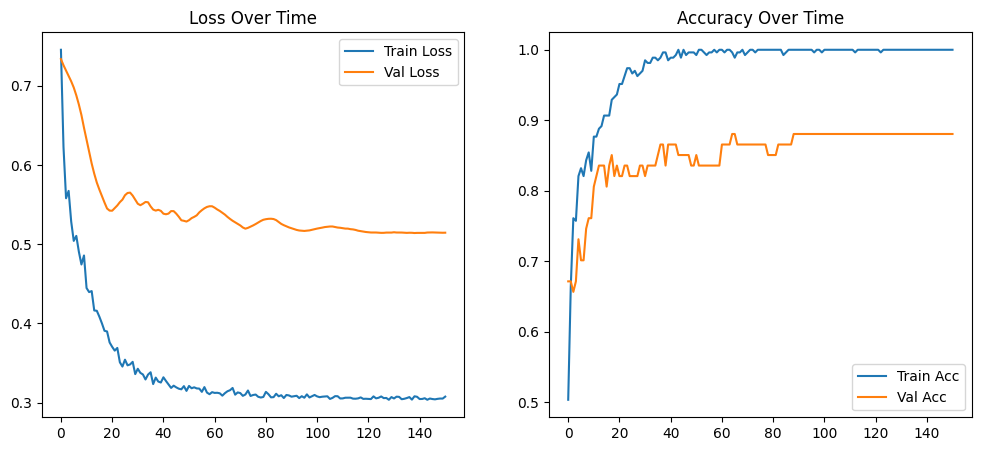

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results', exist_ok=True) # Folder for CSVs and Graphs

# --- ARCHITECTURE (Mish + SE + Residual) ---
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.6):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.act = Mish()
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.se = SEBlock(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim)) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        out = self.act(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))
        out = self.se(out)
        return self.act(out + res)

class DeepResidualNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(input_dim, 256), nn.BatchNorm1d(256), Mish(), nn.Dropout(0.5))
        self.layer1 = ResidualBlock(256, 128)
        self.layer2 = ResidualBlock(128, 64)
        self.layer3 = ResidualBlock(64, 32)
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.classifier(x)

# --- TRAINING WITH HISTORY TRACKING ---
def train_and_save(features, labels):
    feat_temp = []
    n_samples, n_dims = features.shape
    for i in range(n_samples):
        slices = [features[np.clip(i + o, 0, n_samples - 1)] for o in range(-2, 3)]
        feat_temp.append(np.concatenate(slices))
    feat_temp = np.array(feat_temp)

    col_std = feat_temp.std(axis=0)
    kept_cols = np.where(col_std > 1e-6)[0]
    X_norm = StandardScaler().fit_transform(feat_temp[:, kept_cols])

    tr_idx, te_idx = train_test_split(np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=42)
    tr_idx, va_idx = train_test_split(tr_idx, test_size=0.2, stratify=labels[tr_idx], random_state=42)

    X, y = torch.from_numpy(X_norm).float().to(DEVICE), torch.from_numpy(labels).long().to(DEVICE)
    model = DeepResidualNetwork(input_dim=X_norm.shape[1]).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, (len(y[y==0])/len(y[y==1]))*1.1], device=DEVICE), label_smoothing=0.15)
    opt = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)

    history = []
    best_st = None
    best_vl = float('inf')

    print(f"{'Epoch':<6} | {'Tr Acc':<8} | {'Va Acc':<8} | {'Va Loss':<8}")

    for ep in range(151):
        model.train()
        opt.zero_grad()
        logits = model(X[tr_idx])
        loss = criterion(logits, y[tr_idx])
        loss.backward()
        opt.step()
        sched.step()

        tr_acc = (logits.argmax(1) == y[tr_idx]).float().mean().item()

        model.eval()
        with torch.no_grad():
            va_logits = model(X[va_idx])
            vl = criterion(va_logits, y[va_idx]).item()
            va_acc = (va_logits.argmax(1) == y[va_idx]).float().mean().item()

            if vl < best_vl:
                best_vl, best_st = vl, copy.deepcopy(model.state_dict())

        history.append({'epoch': ep, 'train_loss': loss.item(), 'train_acc': tr_acc, 'val_loss': vl, 'val_acc': va_acc})
        if ep % 25 == 0: print(f"{ep:<6} | {tr_acc*100:6.1f}% | {va_acc*100:6.1f}% | {vl:.4f}")

    # Save CSV
    df_history = pd.DataFrame(history)
    df_history.to_csv('results/training_metrics.csv', index=False)

    # Save Graphs
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(df_history['train_loss'], label='Train Loss')
    plt.plot(df_history['val_loss'], label='Val Loss')
    plt.title('Loss Over Time'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_history['train_acc'], label='Train Acc')
    plt.plot(df_history['val_acc'], label='Val Acc')
    plt.title('Accuracy Over Time'); plt.legend()
    plt.savefig('results/learning_curves.png')

    model.load_state_dict(best_st)
    return model, {'test_idx': te_idx, 'X_norm': X_norm, 'y': y}

def final_report(model, info):
    X_te = torch.from_numpy(info['X_norm'][info['test_idx']]).float().to(DEVICE)
    y_te = info['y'][info['test_idx']].cpu().numpy()
    model.eval()
    with torch.no_grad():
        preds = model(X_te).argmax(1).cpu().numpy()

    report = classification_report(y_te, preds, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv('results/final_test_report.csv')

    print("\nResults saved to 'results/' folder.")
    print(f"Overall Test Accuracy: {(preds == y_te).mean()*100:.2f}%")

# Execute
features = np.load("data/processed/eduvsum/combined_features.npy")
labels = np.load("data/processed/eduvsum/combined_labels.npy")
model, info = train_and_save(features, labels)
final_report(model, info)

# Metrics